In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ANALYSE DESCRIPTIVE

In [2]:
df = pd.read_csv(r"C:\TSQ\data\data1.csv", sep=",", encoding='utf-8')

In [3]:
df = df.drop(df.index[[84, 232]]) # Suppression de la ligne 85 (index 84) car diag porte à confusion pas une patho et 232 car HPI ne fait pas parti de nos diag

In [4]:
print(f"Shape : {df.shape}")
print(f"Nombre de colonnes détectées : {len(df.columns)}")

Shape : (312, 273)
Nombre de colonnes détectées : 273


In [5]:
df.head()

,ID de la réponse,Date de soumission,Dernière page,Langue de départ,Tête de série,Être bien âgé entre 18 et 65 ans,Avoir un niveau de maitrise suffisant de la langue française,Être dans un moment calme et de disponibilité pour compléter le questionnaire,Quel est votre âge ?,Comment vous identifiez-vous ?,...,Durée pour la question: G11Q62,Durée pour la question: G10Q63,Durée pour la question: G10Q64,Durée pour la question: G01Q65,Durée pour la question: G01Q66,Durée pour la question: G10Q68,Durée pour le groupe : ZTPI - Evaluation de la temporalité,Durée pour la question: G12Q68,"Durée pour le groupe : Bravo, vous êtes arrivé(e)s à la fin de ce questionnaire !",Durée pour la question: G08Q139
0,7,NaN,8.0,fr,1344793166,Oui,Oui,Oui,21.0,Femme,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,1980-01-01 00:00:00,12.0,fr,1664186297,Oui,Oui,Oui,21.0,Femme,...,NaN,NaN,NaN,NaN,NaN,NaN,306.56,NaN,17.70,NaN
2,9,1980-01-01 00:00:00,12.0,fr,627717770,Oui,Oui,Oui,39.0,Femme,...,NaN,NaN,NaN,NaN,NaN,NaN,458.17,NaN,15.46,NaN
3,10,1980-01-01 00:00:00,12.0,fr,1685970839,Oui,Oui,Oui,59.0,Femme,...,NaN,NaN,NaN,NaN,NaN,NaN,1394.07,NaN,12.98,NaN
4,11,1980-01-01 00:00:00,12.0,fr,2127008022,Oui,Oui,Oui,24.0,Femme,...,NaN,NaN,NaN,NaN,NaN,NaN,455.10,NaN,35.00,NaN


In [6]:
#deja commencer par enlever toutes les lignes ou il n'y a pas eu de soumissions 
df = df.dropna(subset=['Date de soumission'])

In [7]:
print(f"Shape : {df.shape}")
print(f"Nombre de colonnes détectées : {len(df.columns)}")

Shape : (185, 273)
Nombre de colonnes détectées : 273


In [8]:
df.drop(columns=["Date de soumission"], inplace=True) #on s'en fiche on supprime la colonne


In [9]:
print(df.columns.tolist())


['ID de la réponse', 'Dernière page', 'Langue de départ', 'Tête de série', 'Être bien âgé entre 18 et 65 ans', 'Avoir un niveau de maitrise suffisant de la langue française\xa0', 'Être dans un moment calme et de disponibilité pour compléter le questionnaire', 'Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'Est-ce la première fois que vous remplissez ce questionnaire?', 'Êtes-vous étudiant (hors Université du Temps Libre) ?', 'Quelle est votre situation ?', "Quelle est votre filière d'étude ?", "Quelle est votre filière d'étude ? [Autre]", 'Quelle est votre profession ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?', 'Si oui, lequel (lesquels) ?\xa0', 'Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Précisez le trai

Ca a bien fonctionné

# On va trier ceux qui ont un diag de ceux qui n'en n'ont pas

In [10]:
#PS = participants sains #PD = participants diagnostiqués
col = "Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?"
df_PS = df[df[col] == "Non"].copy()
df_PD = df[df[col] == "Oui"].copy()


On va commencer par séparer les résultats des différents questionnaires en faisant un dataframe pour chaque échelle

In [11]:
n_patients = len(df_PD)
n_total = len(df)
pourcentage = n_patients / n_total * 100

print(f"df_PD : {n_patients} lignes sur {n_total} ({pourcentage:.2f}%)")

df_PD : 31 lignes sur 185 (16.76%)


In [12]:
col_name = df_PD.columns[18]
print(f"Colonne : {col_name}")
print(df_PD[col_name])

Colonne : Si oui, lequel (lesquels) ? 
2                    TDAH\nDépression\nAnxiété chronique
4                                        Trouble anxieux
11                                            Depression
13                                            Dépression
20                              TROUBLE BIPOLAIRE TYPE 1
28                         épisode dépressif caractérisé
41                                     épisode dépressif
79                                   Tendance depressive
98                                            Dépression
113                                           Dépression
139                                        Schizophrénie
140                            Dépression, anxiété, TdAH
149        Diagnostic d’un trouble anxieux et généralisé
153                           Trouble anxieux généralisé
176                    TSA, TDAH, TDI, bipolarité type 1
178                                                  TAG
182                                           Dép

17,65% des participants ont ou ont eu un diag

In [13]:
comor= df_PD.iloc[[0, 11, 14, 17, 20, 23, 25, 27]]
comor.iloc[:, 18]

2                    TDAH\nDépression\nAnxiété chronique
140                            Dépression, anxiété, TdAH
176                    TSA, TDAH, TDI, bipolarité type 1
195                             Syndrome anxio dépressif
247                                          TDAH et TAG
265                                 Dépression + Anxiété
272    Trouble anxieux généralisé, trouble anxieux so...
290    Trouble anxieux généralisé, anxiété sociale, s...
Name: Si oui, lequel (lesquels) ? , dtype: str

In [14]:
dep= df_PD.iloc[[2,3,5,6,7,8,9,16,18,19,28]]
dep.iloc[:, 18]

11                        Depression
13                        Dépression
28     épisode dépressif caractérisé
41                 épisode dépressif
79               Tendance depressive
98                        Dépression
113                       Dépression
182                       Dépression
209                       Dépression
242         Episode depressif modéré
296         Depression reactionnelle
Name: Si oui, lequel (lesquels) ? , dtype: str

In [15]:
ax= df_PD.iloc[[1,12,13,15,24]]
ax.iloc[:, 18]

4                                    Trouble anxieux
149    Diagnostic d’un trouble anxieux et généralisé
153                       Trouble anxieux généralisé
178                                              TAG
266                              Anxiété généralisée
Name: Si oui, lequel (lesquels) ? , dtype: str

In [16]:
man = df_PD.iloc[[4,21,22,26,29,30]]
man.iloc[:, 18]

20     TROUBLE BIPOLAIRE TYPE 1
251                  Bipolarité
257                         TOC
287                  borderline
300                  Bipolarité
310                  Bipolarité
Name: Si oui, lequel (lesquels) ? , dtype: str

In [17]:
sz = df_PD.iloc[[10]]
sz.iloc[:, 18]

139    Schizophrénie
Name: Si oui, lequel (lesquels) ? , dtype: str

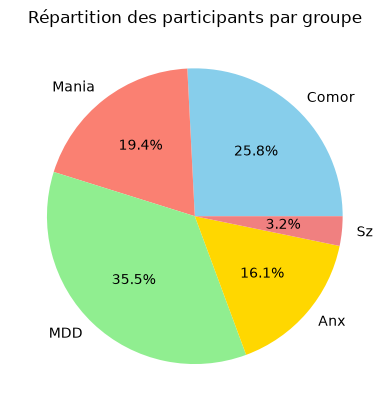

In [18]:
import matplotlib.pyplot as plt

# Dictionnaire avec le nom du groupe et sa taille
groupes = {
    'Comor': len(comor),
    'Mania': len(man),
    'MDD': len(dep),
    'Anx' :len(ax),
    'Sz': len(sz)
}
plt.pie(
    groupes.values(),
    labels=groupes.keys(),
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon', 'lightgreen', 'gold', 'lightcoral']
)
plt.title("Répartition des participants par groupe")
plt.show()

# Données socio-demo

In [19]:
donnees_soc_demo = ['ID de la réponse', 'Dernière page', 'Langue de départ', 'Tête de série', 'Être bien âgé entre 18 et 65 ans', 'Avoir un niveau de maitrise suffisant de la langue française\xa0', 'Être dans un moment calme et de disponibilité pour compléter le questionnaire', 'Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'Est-ce la première fois que vous remplissez ce questionnaire?', 'Êtes-vous étudiant (hors Université du Temps Libre) ?', 'Quelle est votre situation ?', "Quelle est votre filière d'étude ?", "Quelle est votre filière d'étude ? [Autre]", 'Quelle est votre profession ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?', 'Si oui, lequel (lesquels) ?\xa0', 'Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Précisez le traitement médicamenteux actuel et son dosage.', 'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?', 'À quelle fréquence ?', 'Quelle(s) substance(s) avez-vous consommé ?']
df_SD=df[donnees_soc_demo].copy()

In [20]:
print(f"Shape : {df_SD.shape}")

Shape : (185, 25)


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 185 entries, 1 to 311
Columns: 272 entries, ID de la réponse to Durée pour la question: G08Q139
dtypes: float64(172), int64(2), str(98)
memory usage: 394.6 KB


In [22]:
# Création de df_SD pour chaque groupe 
donnees_soc_demo = ['ID de la réponse', 'Dernière page', 'Langue de départ', 'Tête de série', 'Être bien âgé entre 18 et 65 ans', 'Avoir un niveau de maitrise suffisant de la langue française\xa0', 'Être dans un moment calme et de disponibilité pour compléter le questionnaire', 'Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'Est-ce la première fois que vous remplissez ce questionnaire?', 'Êtes-vous étudiant (hors Université du Temps Libre) ?', 'Quelle est votre situation ?', "Quelle est votre filière d'étude ?", "Quelle est votre filière d'étude ? [Autre]", 'Quelle est votre profession ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?', 'Si oui, lequel (lesquels) ?\xa0', 'Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Précisez le traitement médicamenteux actuel et son dosage.', 'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?', 'À quelle fréquence ?', 'Quelle(s) substance(s) avez-vous consommé ?']
df_SD_PD=df_PD[donnees_soc_demo].copy()
df_SD_PS=df_PS[donnees_soc_demo].copy()

On a des colonnes qui sont pertinentes quand meme pour le groupe sain mais tout le monde n'est pas concerné donc il y a des Nan. 
Je vais remplacer les "Nan" pas une valeur categorielle : "non concerné"

In [23]:
df_SD_PS.describe()


,ID de la réponse,Dernière page,Tête de série,Quel est votre âge ?
count,154.000000,154.0,1.540000e+02,154.000000
mean,156.064935,12.0,1.010330e+09,34.337662
std,89.752577,0.0,6.378467e+08,13.111498
min,8.000000,12.0,7.330348e+06,20.000000
25%,73.250000,12.0,4.606797e+08,23.000000
50%,152.500000,12.0,9.593143e+08,30.000000
75%,228.000000,12.0,1.604347e+09,45.000000
max,318.000000,12.0,2.130509e+09,62.000000


In [24]:
df_SD_PD.describe()

,ID de la réponse,Dernière page,Tête de série,Quel est votre âge ?
count,31.000000,31.0,3.100000e+01,31.000000
mean,175.161290,12.0,1.204847e+09,32.225806
std,103.434068,0.0,6.559692e+08,11.286303
min,9.000000,12.0,2.002317e+08,20.000000
25%,95.500000,12.0,6.480266e+08,24.000000
50%,185.000000,12.0,1.257973e+09,27.000000
75%,268.000000,12.0,1.781901e+09,41.500000
max,317.000000,12.0,2.127008e+09,57.000000


# voir si il y a des données manquantes/abberantes et cb de % sur les données d'interets

Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?                                          100.000000
Si oui, lequel (lesquels) ?                                                                                   100.000000
Quelle est votre filière d'étude ? [Autre]                                                                     96.103896
À quelle fréquence ?                                                                                           91.558442
Quelle(s) substance(s) avez-vous consommé ?                                                                    91.558442
Précisez le traitement médicamenteux actuel et son dosage.                                                     90.909091
En quelle année êtes-vous ?                                                                                    55.844156
Quelle est votre filière d'étude ?                                                                             55.844156
Quelle est votre profession ?   

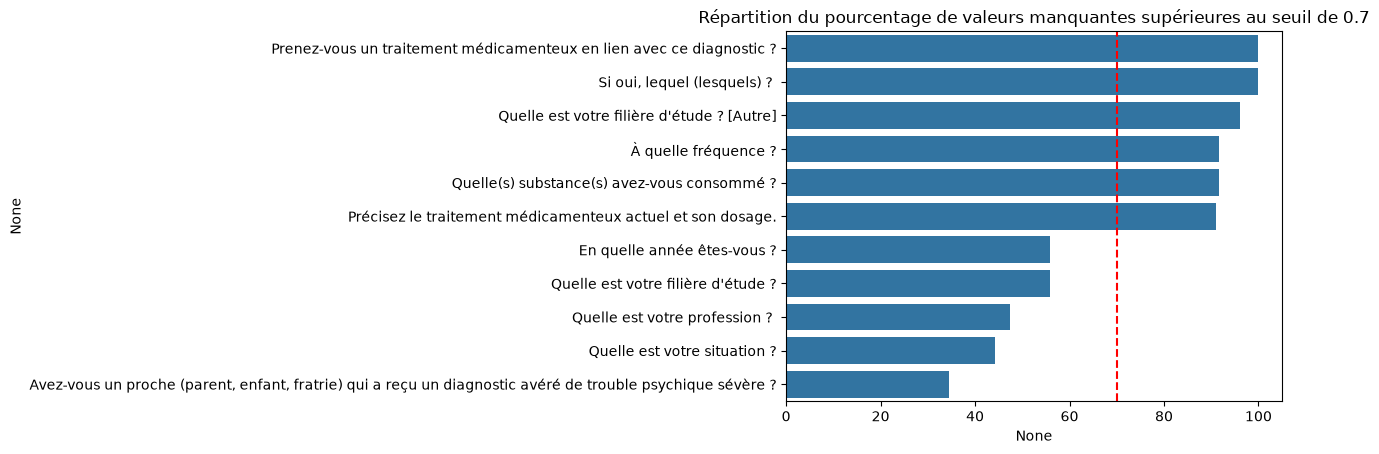

In [25]:
import seaborn as sns
threshold_view = 0.70
percent_missing = (df_SD_PS.isnull().sum() / len(df_SD_PS) * 100).sort_values(ascending=False)
print(percent_missing)
filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 70

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

Quelle est votre filière d'étude ? [Autre]                                                                    100.000000
À quelle fréquence ?                                                                                           80.645161
Quelle(s) substance(s) avez-vous consommé ?                                                                    80.645161
Quelle est votre profession ?                                                                                  61.290323
Précisez le traitement médicamenteux actuel et son dosage.                                                     61.290323
Quelle est votre filière d'étude ?                                                                             51.612903
En quelle année êtes-vous ?                                                                                    51.612903
Quelle est votre situation ?                                                                                   48.387097
Avez-vous un proche (parent, enf

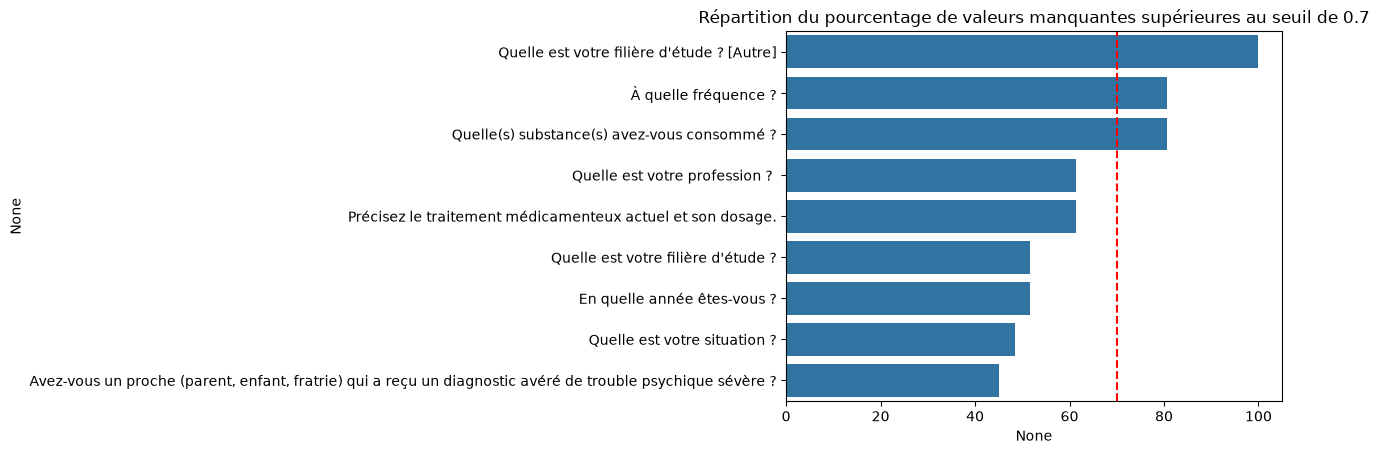

In [26]:
percent_missing = (df_SD_PD.isnull().sum() / len(df_SD_PD) * 100).sort_values(ascending=False)
print(percent_missing)
filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");
ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [27]:
percent_missing = (df_SD_PS.isnull().sum() / len(df_SD_PS) * 100).sort_values(ascending=False)
print(percent_missing)

Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?                                          100.000000
Si oui, lequel (lesquels) ?                                                                                   100.000000
Quelle est votre filière d'étude ? [Autre]                                                                     96.103896
À quelle fréquence ?                                                                                           91.558442
Quelle(s) substance(s) avez-vous consommé ?                                                                    91.558442
Précisez le traitement médicamenteux actuel et son dosage.                                                     90.909091
En quelle année êtes-vous ?                                                                                    55.844156
Quelle est votre filière d'étude ?                                                                             55.844156
Quelle est votre profession ?   

In [28]:
percent_missing = (df_SD_PS.isnull().sum() / len(df_SD_PS) * 100).sort_values(ascending=False)
print(percent_missing)

Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?                                          100.000000
Si oui, lequel (lesquels) ?                                                                                   100.000000
Quelle est votre filière d'étude ? [Autre]                                                                     96.103896
À quelle fréquence ?                                                                                           91.558442
Quelle(s) substance(s) avez-vous consommé ?                                                                    91.558442
Précisez le traitement médicamenteux actuel et son dosage.                                                     90.909091
En quelle année êtes-vous ?                                                                                    55.844156
Quelle est votre filière d'étude ?                                                                             55.844156
Quelle est votre profession ?   

In [29]:
# Compter le nombre de lignes complètement vides (toutes les valeurs sont NaN)
lignes_vides = df_SD_PS.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")
seuil = len(df_SD_PS) * 0.3 #on supprime tout ce qui a plus de 30% de valeurs manquantes
df_SD_PS.dropna(axis=1, thresh=seuil)

Nombre de lignes complètement vides : 0


,ID de la réponse,Dernière page,Langue de départ,Tête de série,Être bien âgé entre 18 et 65 ans,Avoir un niveau de maitrise suffisant de la langue française,Être dans un moment calme et de disponibilité pour compléter le questionnaire,Quel est votre âge ?,Comment vous identifiez-vous ?,Est-ce la première fois que vous remplissez ce questionnaire?,Êtes-vous étudiant (hors Université du Temps Libre) ?,Quelle est votre situation ?,Quelle est votre filière d'étude ?,Quelle est votre profession ?,En quelle année êtes-vous ?,Quel est votre plus haut niveau de diplôme obtenu ?,Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?,"Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?","Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?"
1,8,12.0,fr,1664186297,Oui,Oui,Oui,21.0,Femme,Oui,Oui,NaN,Psychologie,NaN,3e année,Baccalauréat,Non,Non,Non
3,10,12.0,fr,1685970839,Oui,Oui,Oui,59.0,Femme,Oui,Non,En emploi,NaN,"Professions intermédiaires (médico-social, ens...",NaN,Niveau BAC+1,Non,Non,Non
5,12,12.0,fr,1463047385,Oui,Oui,Oui,23.0,Homme,Oui,Oui,NaN,Psychologie,NaN,4e année,Licence,Non,Non,Non
9,16,12.0,fr,1665588914,Oui,Oui,Oui,60.0,Homme,Oui,Non,En emploi,NaN,Cadres et professions intellectuelles supérieures,NaN,Doctorat,Non,Non,Non
10,17,12.0,fr,516102513,Oui,Oui,Oui,44.0,Femme,Oui,Non,En emploi,NaN,Cadres et professions intellectuelles supérieures,NaN,Master,Non,Oui,Non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,311,12.0,fr,1342894823,Oui,Oui,Oui,55.0,Femme,Oui,Non,En emploi,NaN,"Professions intermédiaires (médico-social, ens...",NaN,Niveau BAC+3,Non,NaN,Non
306,313,12.0,fr,904173720,Oui,Oui,Oui,33.0,Femme,Oui,Non,En emploi,NaN,Cadres et professions intellectuelles supérieures,NaN,Master,Non,NaN,Non
307,314,12.0,fr,458216694,Oui,Oui,Oui,43.0,Femme,Oui,Non,En emploi,NaN,"Professions intermédiaires (médico-social, ens...",NaN,Master,Non,NaN,Non
308,315,12.0,fr,73029877,Oui,Oui,Oui,43.0,Homme,Oui,Non,En emploi,NaN,"Professions intermédiaires (médico-social, ens...",NaN,Doctorat,Non,NaN,Non


In [30]:
for col in df_SD_PS.columns:
    print(col, df_SD_PS[col].apply(type).unique())
    

ID de la réponse [<class 'int'>]
Dernière page [<class 'float'>]
Langue de départ [<class 'str'>]
Tête de série [<class 'int'>]
Être bien âgé entre 18 et 65 ans [<class 'str'>]
Avoir un niveau de maitrise suffisant de la langue française  [<class 'str'>]
Être dans un moment calme et de disponibilité pour compléter le questionnaire [<class 'str'>]
Quel est votre âge ? [<class 'float'>]
Comment vous identifiez-vous ?  [<class 'str'>]
Est-ce la première fois que vous remplissez ce questionnaire? [<class 'str'>]
Êtes-vous étudiant (hors Université du Temps Libre) ? [<class 'str'>]
Quelle est votre situation ? [<class 'float'> <class 'str'>]
Quelle est votre filière d'étude ? [<class 'str'> <class 'float'>]
Quelle est votre filière d'étude ? [Autre] [<class 'float'> <class 'str'>]
Quelle est votre profession ?  [<class 'float'> <class 'str'>]
En quelle année êtes-vous ? [<class 'str'> <class 'float'>]
Quel est votre plus haut niveau de diplôme obtenu ? [<class 'str'>]
Avez-vous déjà reçu un

In [31]:
cols_num = df_SD_PS.select_dtypes(include='number').columns
cols_cat = df_SD_PS.select_dtypes(exclude='number').columns

In [32]:
from sklearn.impute import SimpleImputer

imputer_num = SimpleImputer(strategy='mean')
df_SD_PS[cols_num] = imputer_num.fit_transform(df_SD_PS[cols_num])


In [33]:
imputer_cat = SimpleImputer(strategy='constant', fill_value='Inconnu', keep_empty_features=True) #on garde les colonnes vides qu'on remplace par "Inconnu"

df_cat_imputed = pd.DataFrame(
    imputer_cat.fit_transform(df_SD_PS[cols_cat]),
    columns=cols_cat,
    index=df_SD_PS.index
)

df_SD_PS[cols_cat] = df_cat_imputed

In [34]:
print(df_SD_PS.isnull().sum())  # vérification : tout devrait être à 0
df_SD_PS

ID de la réponse                                                                                              0
Dernière page                                                                                                 0
Langue de départ                                                                                              0
Tête de série                                                                                                 0
Être bien âgé entre 18 et 65 ans                                                                              0
Avoir un niveau de maitrise suffisant de la langue française                                                  0
Être dans un moment calme et de disponibilité pour compléter le questionnaire                                 0
Quel est votre âge ?                                                                                          0
Comment vous identifiez-vous ?                                                                          

,ID de la réponse,Dernière page,Langue de départ,Tête de série,Être bien âgé entre 18 et 65 ans,Avoir un niveau de maitrise suffisant de la langue française,Être dans un moment calme et de disponibilité pour compléter le questionnaire,Quel est votre âge ?,Comment vous identifiez-vous ?,Est-ce la première fois que vous remplissez ce questionnaire?,...,En quelle année êtes-vous ?,Quel est votre plus haut niveau de diplôme obtenu ?,Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?,"Si oui, lequel (lesquels) ?",Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?,"Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?",Précisez le traitement médicamenteux actuel et son dosage.,"Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?",À quelle fréquence ?,Quelle(s) substance(s) avez-vous consommé ?
1,8.0,12.0,fr,1.664186e+09,Oui,Oui,Oui,21.0,Femme,Oui,...,3e année,Baccalauréat,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
3,10.0,12.0,fr,1.685971e+09,Oui,Oui,Oui,59.0,Femme,Oui,...,Inconnu,Niveau BAC+1,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
5,12.0,12.0,fr,1.463047e+09,Oui,Oui,Oui,23.0,Homme,Oui,...,4e année,Licence,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
9,16.0,12.0,fr,1.665589e+09,Oui,Oui,Oui,60.0,Homme,Oui,...,Inconnu,Doctorat,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
10,17.0,12.0,fr,5.161025e+08,Oui,Oui,Oui,44.0,Femme,Oui,...,Inconnu,Master,Non,Inconnu,Inconnu,Oui,Bipolarité,Non,Inconnu,Inconnu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,311.0,12.0,fr,1.342895e+09,Oui,Oui,Oui,55.0,Femme,Oui,...,Inconnu,Niveau BAC+3,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu
306,313.0,12.0,fr,9.041737e+08,Oui,Oui,Oui,33.0,Femme,Oui,...,Inconnu,Master,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu
307,314.0,12.0,fr,4.582167e+08,Oui,Oui,Oui,43.0,Femme,Oui,...,Inconnu,Master,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu
308,315.0,12.0,fr,7.302988e+07,Oui,Oui,Oui,43.0,Homme,Oui,...,Inconnu,Doctorat,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu


In [35]:
var_int = ['Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?', 'À quelle fréquence ?', 'Quelle(s) substance(s) avez-vous consommé ?']

In [36]:
df_SD_PS['Êtes-vous étudiant (hors Université du Temps Libre) ?'].value_counts(normalize=True) * 100

Êtes-vous étudiant (hors Université du Temps Libre) ?
Non    55.844156
Oui    44.155844
Name: proportion, dtype: float64

In [37]:
# Filtrer les lignes où la réponse est "Oui"
df_oui = df_SD_PS[df_SD_PS['Êtes-vous étudiant (hors Université du Temps Libre) ?'] == 'Oui']

# Regarder la répartition des filières pour ce sous-groupe
df_oui['Quelle est votre filière d\'étude ?'].value_counts()

Quelle est votre filière d'étude ?
Psychologie                                       43
Autre                                              6
Biologie, Chimie, Mathématiques, Physique          6
Etudes de Santé                                    4
STAPS                                              3
Sciences Humaines et Sociales hors Psychologie     2
Art                                                2
Droit et Sciences politiques                       1
Marketing et Communication                         1
Name: count, dtype: int64

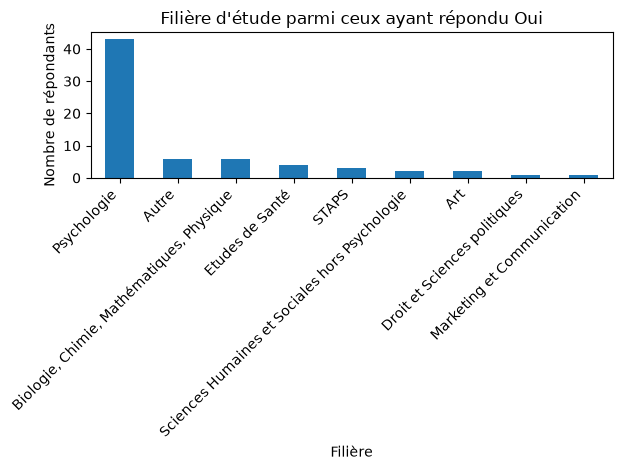

In [38]:
import matplotlib.pyplot as plt

df_oui['Quelle est votre filière d\'étude ?'].value_counts().plot(kind='bar')
plt.title("Filière d'étude parmi ceux ayant répondu Oui")
plt.xlabel("Filière")
plt.ylabel("Nombre de répondants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

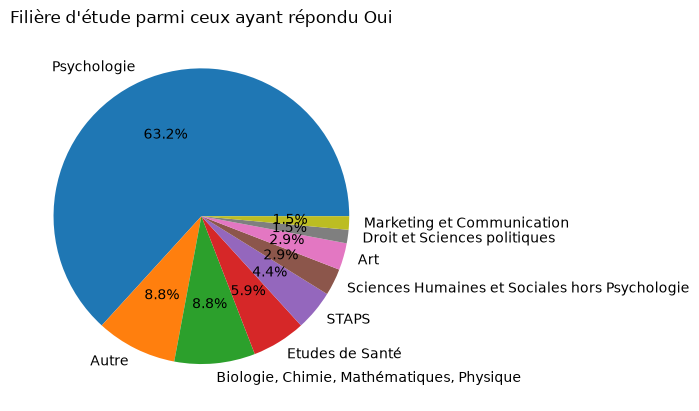

In [39]:
df_oui['Quelle est votre filière d\'étude ?'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Filière d'étude parmi ceux ayant répondu Oui")
plt.ylabel('')
plt.show()

In [40]:
df_SD_PS['Quel est votre âge ?'].describe()

count    154.000000
mean      34.337662
std       13.111498
min       20.000000
25%       23.000000
50%       30.000000
75%       45.000000
max       62.000000
Name: Quel est votre âge ?, dtype: float64

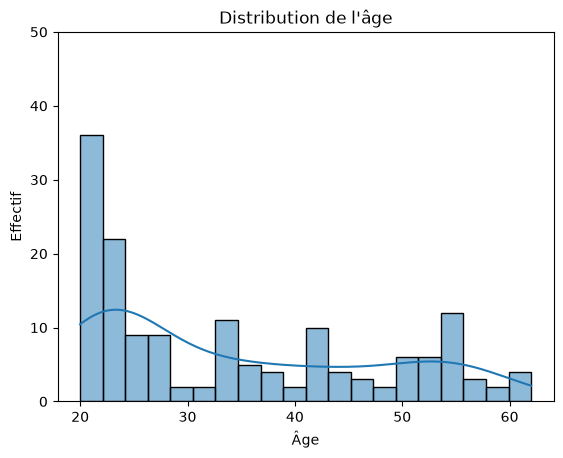

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_SD_PS['Quel est votre âge ?'].dropna(), kde=True, bins=20)
plt.xlabel('Âge')
plt.ylabel('Effectif')
plt.title('Distribution de l\'âge')
plt.ylim(0, 50)
plt.show()

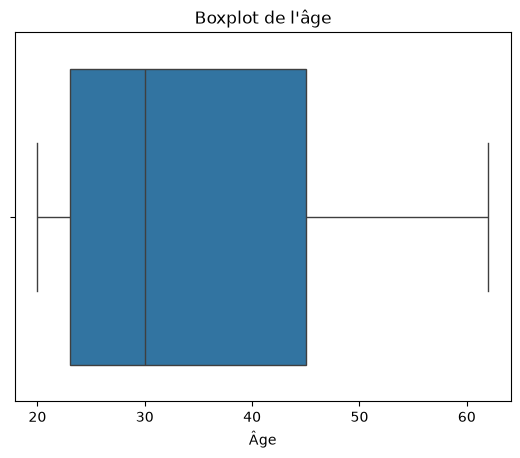

In [42]:
sns.boxplot(x=df_SD_PS['Quel est votre âge ?'])
plt.xlabel('Âge')
plt.title('Boxplot de l\'âge')
plt.show()

In [43]:

df_SD_PS['Comment vous identifiez-vous ?\xa0'].value_counts()

Comment vous identifiez-vous ? 
Femme          113
Homme           40
Non-binaire      1
Name: count, dtype: int64

In [44]:
for i in var_int:
    print(f"Question : {i}")
    print(df_SD_PS[i].value_counts())
    print("\n")

Question : Quel est votre âge ?
Quel est votre âge ?
22.0    14
20.0    13
24.0    12
23.0    10
55.0    10
21.0     9
33.0     8
25.0     7
27.0     6
50.0     5
42.0     5
53.0     4
60.0     3
35.0     3
28.0     3
47.0     3
43.0     3
34.0     3
38.0     3
59.0     2
44.0     2
49.0     2
26.0     2
36.0     2
52.0     2
54.0     2
30.0     2
41.0     2
57.0     2
40.0     2
45.0     2
56.0     1
51.0     1
32.0     1
31.0     1
62.0     1
37.0     1
Name: count, dtype: int64


Question : Comment vous identifiez-vous ? 
Comment vous identifiez-vous ? 
Femme          113
Homme           40
Non-binaire      1
Name: count, dtype: int64


Question : En quelle année êtes-vous ?
En quelle année êtes-vous ?
Inconnu      86
3e année     29
5e année     14
4e année     13
2e année      4
8 ou plus     3
7e année      2
1e année      2
6e année      1
Name: count, dtype: int64


Question : Quel est votre plus haut niveau de diplôme obtenu ?
Quel est votre plus haut niveau de diplôme obtenu 

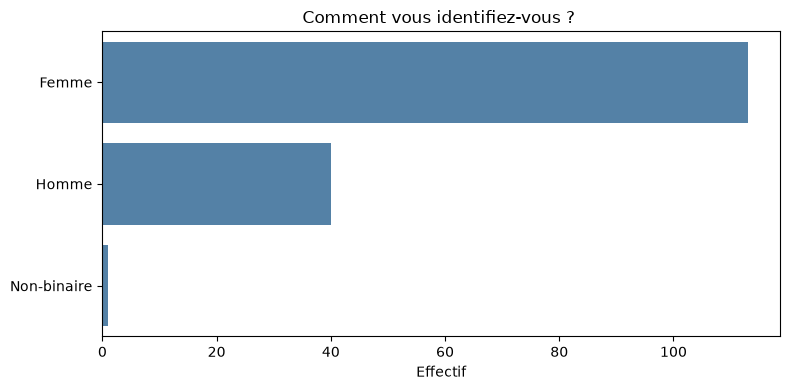

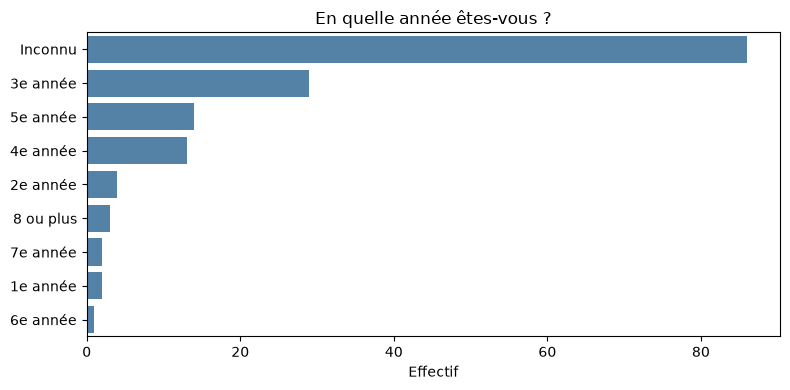

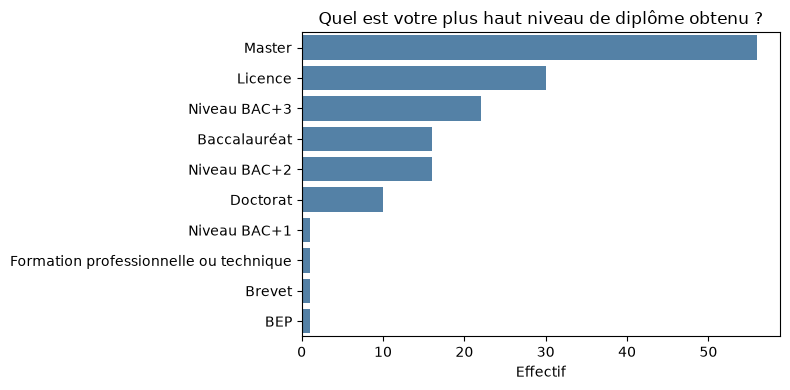

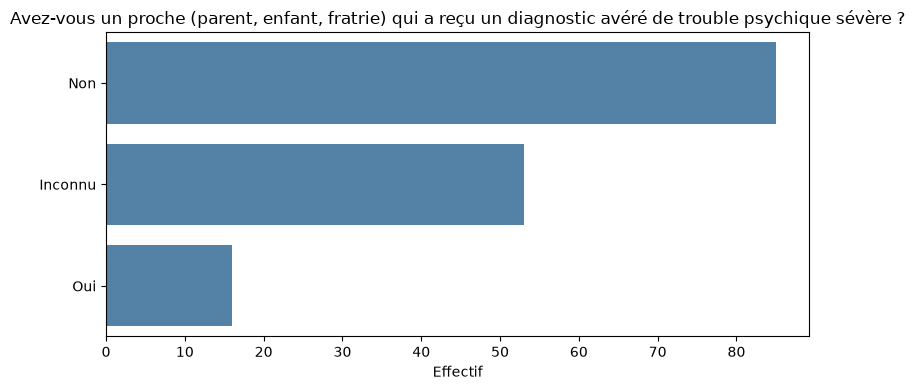

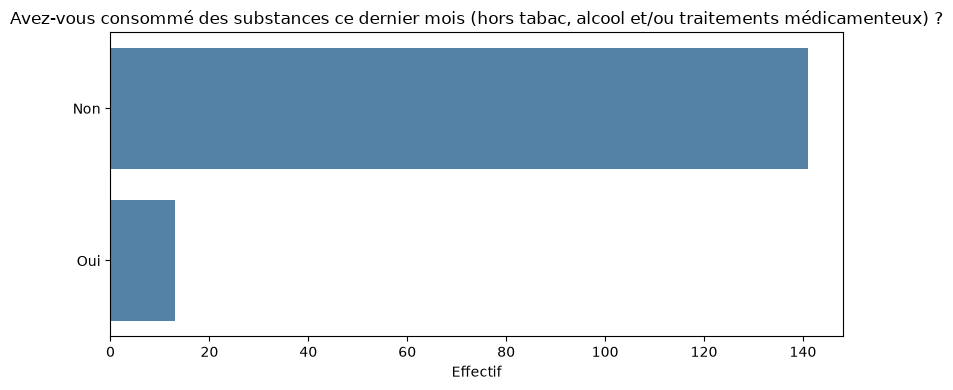

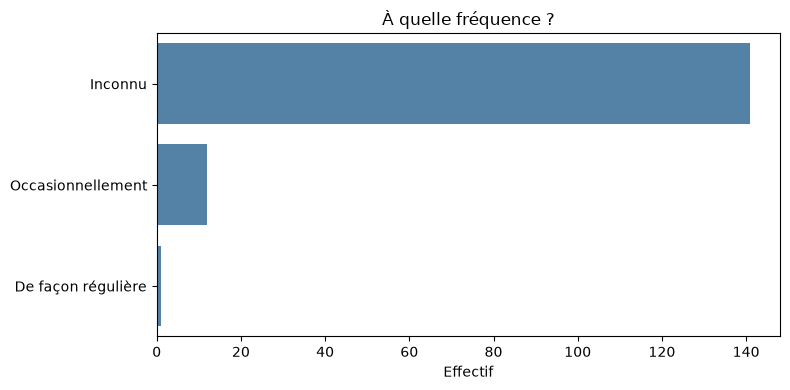

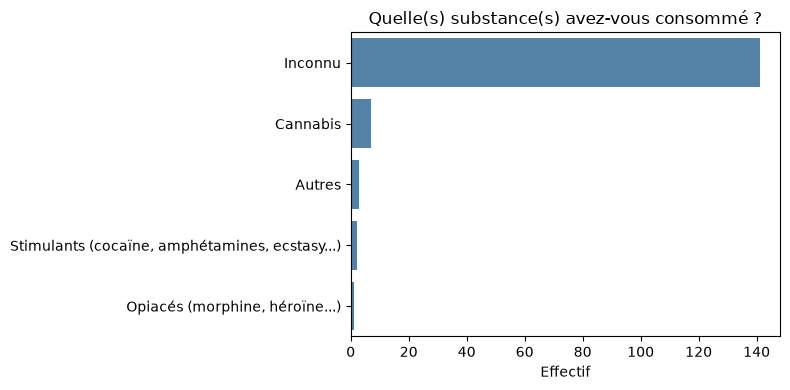

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

colonnes = [
    'Comment vous identifiez-vous ?\xa0',
    'En quelle année êtes-vous ?',
    'Quel est votre plus haut niveau de diplôme obtenu ?',
    'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?',
    'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?',
    'À quelle fréquence ?',
    'Quelle(s) substance(s) avez-vous consommé ?'
]

for col in colonnes:
    plt.figure(figsize=(8, 4))
    order = df_SD_PS[col].value_counts().index  # trie les barres par fréquence décroissante
    sns.countplot(y=df_SD_PS[col], order=order, color='steelblue')
    plt.xlabel('Effectif')
    plt.ylabel('')
    plt.title(col)
    plt.tight_layout()
    plt.show()

# Faire un df pour échelle BAI

21 items à côter de 0 (pas du tout) à 3 (beaucoup)
→ 0 - 7 = anxiété minimale
→ 8 à 15 = anxiété légère
→ 16 - 25 = anxiété modérée
→ 26 - 63 = anxiété sévère


In [46]:
cols_selection_BAI = df_PS.columns[25:46]  # de la colonne 27 à la colonne 47 incluse (27 + 20 suivantes = 21 colonnes)
print(cols_selection_BAI)
print(len(cols_selection_BAI)) 

Index(['Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [9- Terrifié(e)]',
       'Au cours des 7 derniers jo

In [47]:
df_BAI = df_PS[cols_selection_BAI]

In [48]:
cols_selection_BAI = df_PD.columns[25:46] 
df_BAI_PD = df_PD[cols_selection_BAI]

In [49]:
df_BAI_PD["score_total"] = df_BAI_PD.sum(axis=1)

In [50]:
for i, col in enumerate(df_BAI.columns):
    print(i, col)

0 Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]
1 Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]
2 Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]
3 Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]
4 Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]
5 Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]
6 Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]
7 Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]
8 Au cours des 7 derniers jours, j’ai été affecté(e) par… [9- Terrifié(e)]
9 Au cours des 7 derniers jours, j’ai été affecté(e) par… [10- Nervosité]
10 Au cours des 7 derniers jours

# On va commencer par TT les données manquantes/abbérantes

In [51]:
df_BAI.describe()

,"Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [9- Terrifié(e)]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [10- Nervosité]",...,"Au cours des 7 derniers jours, j’ai été affecté(e) par… [12- Tremblements des mains]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [13- Tremblements, chancelant(e) ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [14- Crainte de perdre le contrôle de soi]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [15- Respiration difficile ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [16- Peur de mourir ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [17- Sensation de peur, «avoir la frousse»]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [18- Indigestion ou malaise abdominal ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [19- Sensation de défaillance ou d’évanouissement]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [20- Rougissement du visage]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [21- Transpiration (non associé(e) à la chaleur) ]"
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,...,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,0.396104,0.675325,0.311688,1.142857,0.837662,0.422078,0.694805,0.331169,0.201299,1.220779,...,0.246753,0.064935,0.350649,0.389610,0.233766,0.389610,0.707792,0.194805,0.448052,0.616883
std,0.640862,0.920948,0.610577,0.903360,0.980001,0.739037,0.909844,0.616284,0.564527,0.923525,...,0.563737,0.295397,0.700443,0.743703,0.569281,0.679405,0.892418,0.486120,0.714392,0.810052
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,1.000000,0.750000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,...,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000


In [52]:
# Compter le nombre de lignes complètement vides (toutes les valeurs sont NaN)
lignes_vides = df_BAI.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")
percent_missing = (df_BAI.isnull().sum() / len(df_BAI) * 100).sort_values(ascending=False)
print(percent_missing)
# rien n'est vide, on peut donc continuer avec le traitement 

Nombre de lignes complètement vides : 0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]            0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]                                       0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]          0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]                                 0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]                          0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]                0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]                 0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans 

# Visualisation de la répartition des scores

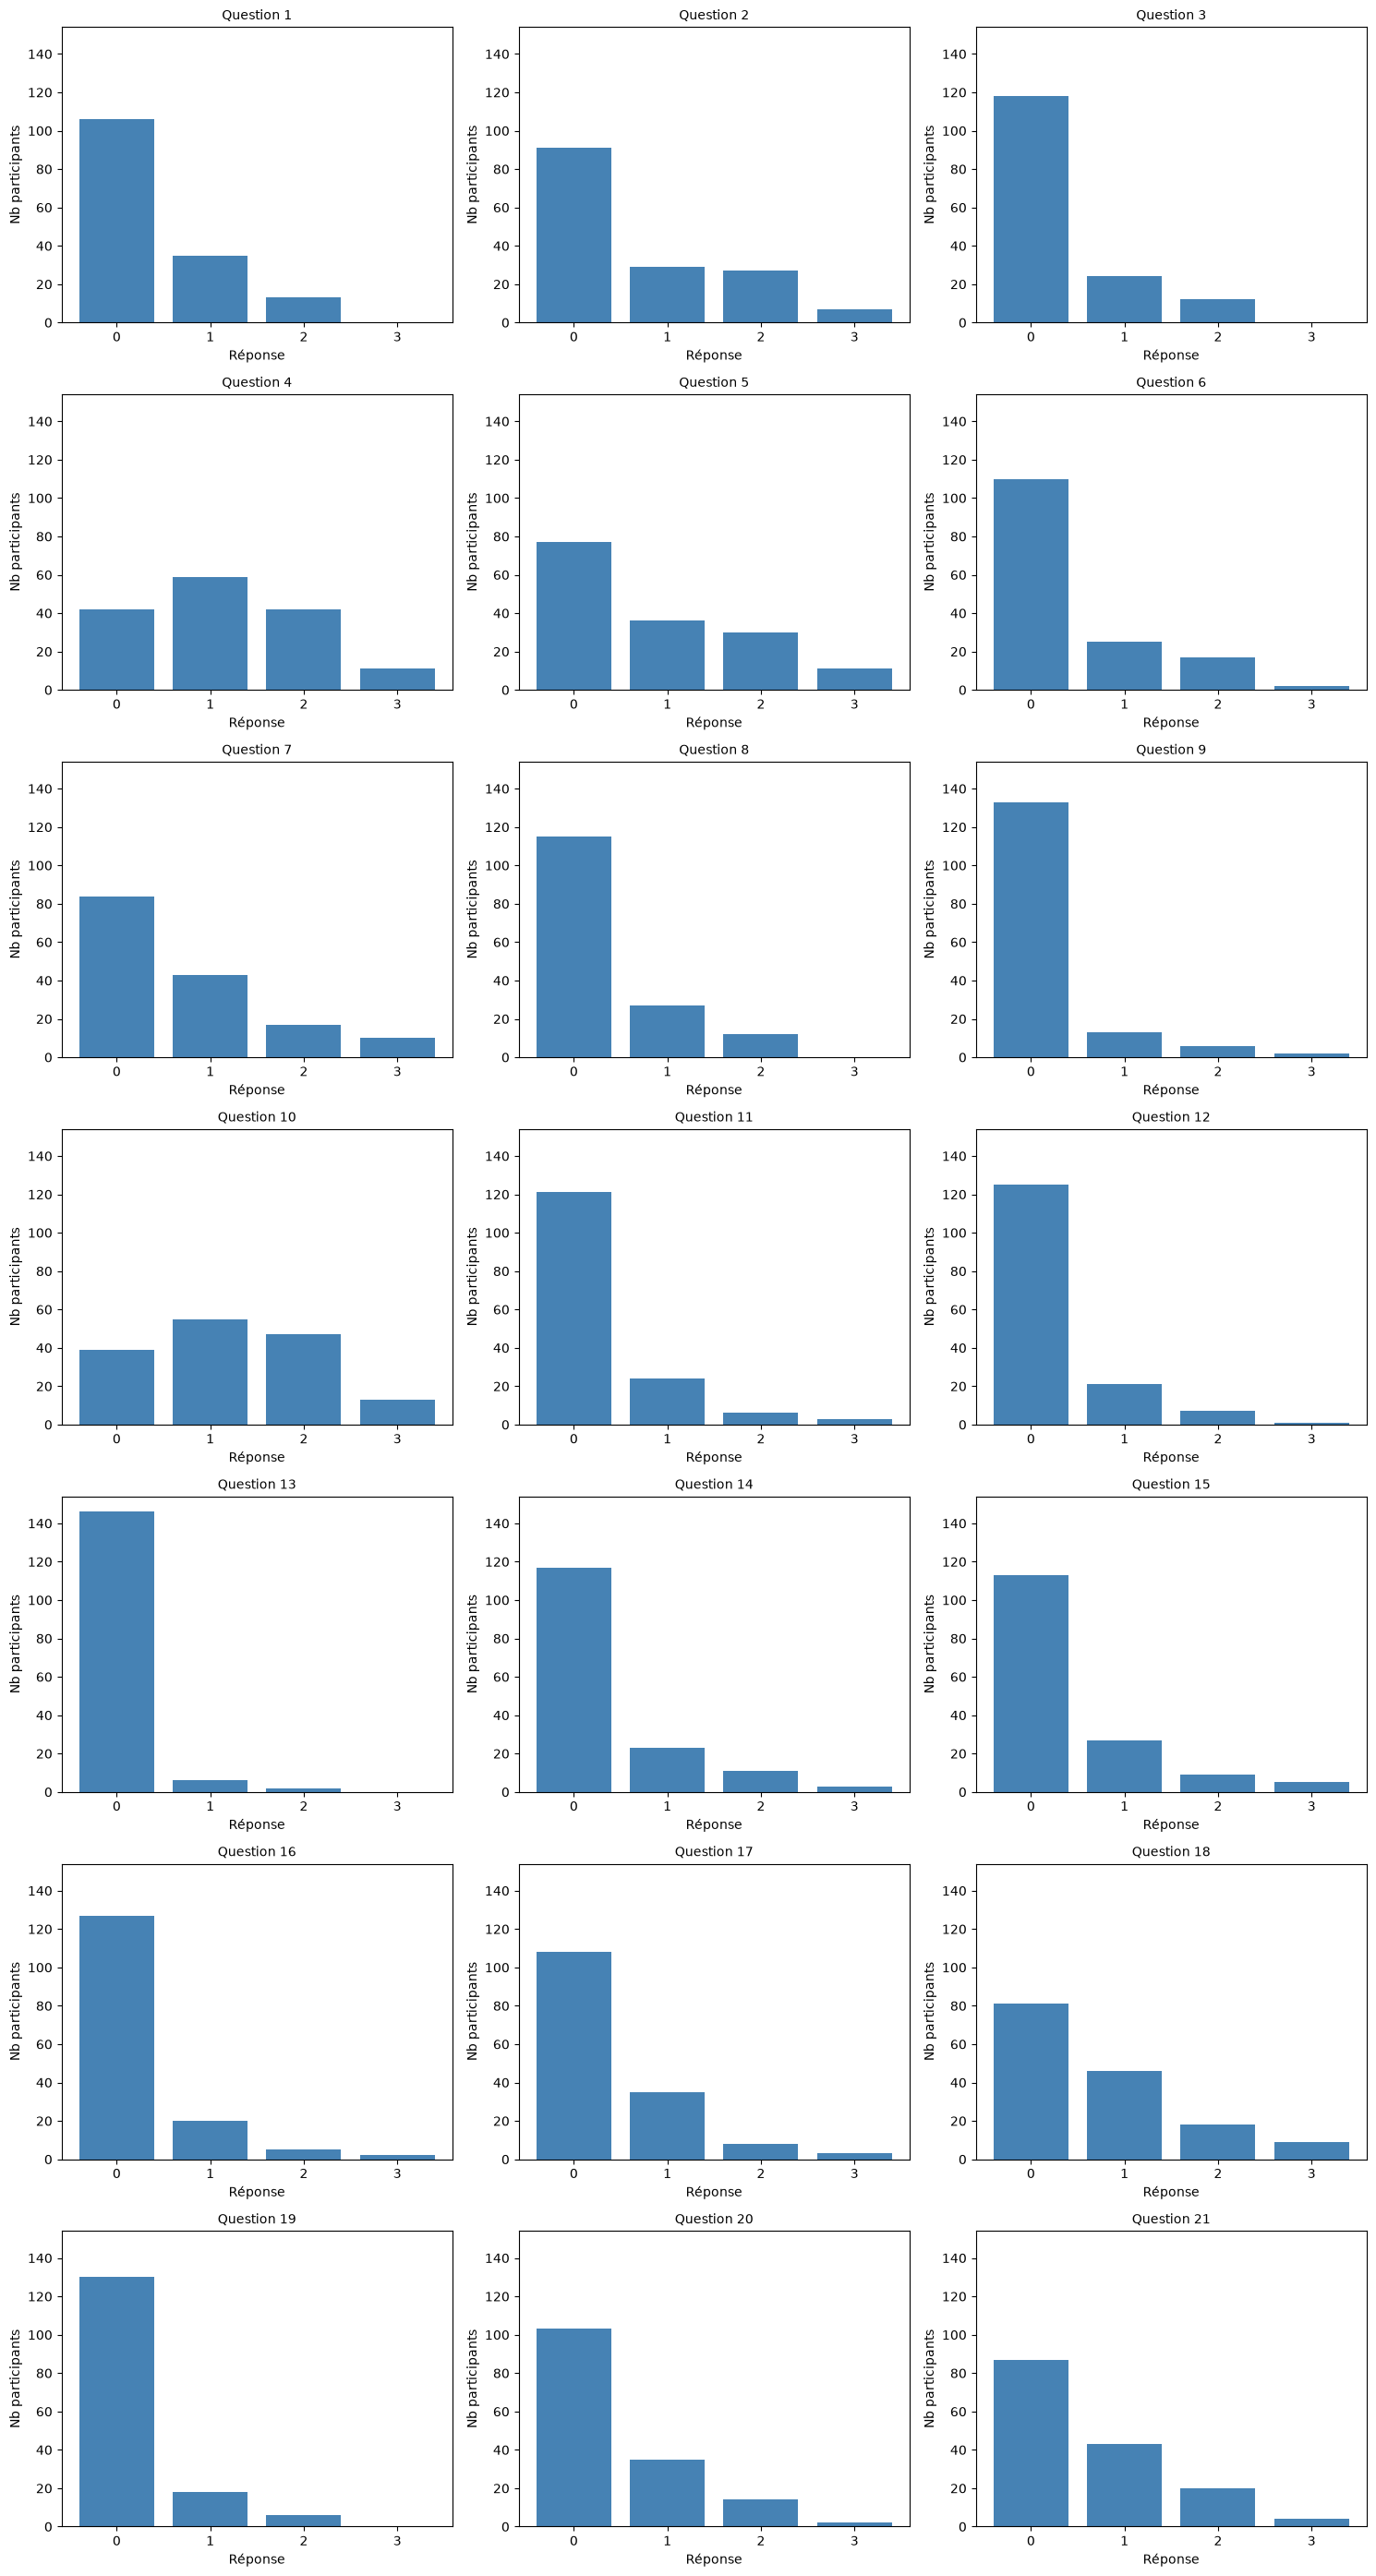

In [53]:
items = df_BAI.columns.tolist()

n = len(items)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_BAI[q].value_counts().reindex([0, 1, 2, 3], fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks([0, 1, 2, 3])
    axes[i].set_ylim(0, 154)

# Masquer les sous-graphiques vides (21 questions sur une grille de 21 ou plus)
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [54]:
for i in items:
    print(f"Question : {i}")
    print(df_BAI[i].value_counts())
    print("\n")

Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]
0.0    106
1.0     35
2.0     13
Name: count, dtype: int64


Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]
0.0    91
1.0    29
2.0    27
3.0     7
Name: count, dtype: int64


Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]
0.0    118
1.0     24
2.0     12
Name: count, dtype: int64


Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se déte

# Répartition des scores totaux

In [55]:
df_BAI["score_total"] = df_BAI.sum(axis=1)



In [56]:
df_BAI["score_total"].describe()

count    154.000000
mean      10.168831
std        8.717652
min        0.000000
25%        4.000000
50%        8.000000
75%       14.000000
max       42.000000
Name: score_total, dtype: float64

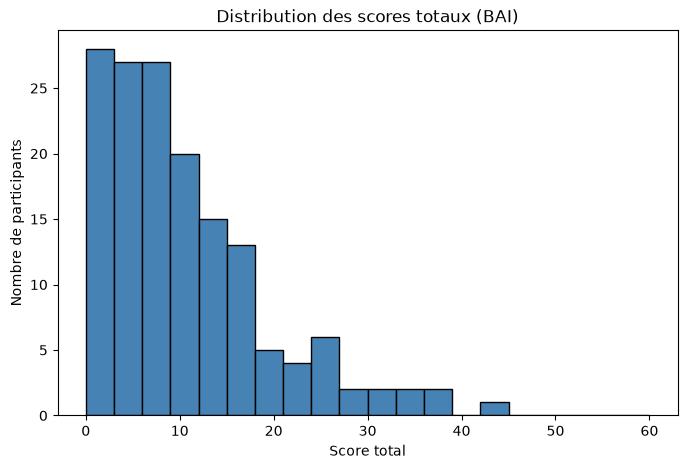

In [57]:
plt.figure(figsize=(8, 5))
plt.hist(df_BAI["score_total"], bins=range(0, 63, 3), color="steelblue", edgecolor="black") #21 × 3 = 63 (score max possible)
plt.xlabel("Score total")
plt.ylabel("Nombre de participants")
plt.title("Distribution des scores totaux (BAI)")
plt.show()

# On va établir des profils de niveau d'anxiété 

In [58]:
bornes = [0, 7, 15, 25, 63] 
labels = ["Minimale (0-7)", "Légère (8-15)", "Modérée (16-25)", "Sévère (26-63)"]

df_BAI["categorie_anxiete"] = pd.cut(
    df_BAI["score_total"],
    bins=bornes,
    labels=labels,
    include_lowest=True
)

# Compter le nombre de participants par catégorie
repartition = df_BAI["categorie_anxiete"].value_counts().reindex(labels)
print(repartition)

categorie_anxiete
Minimale (0-7)     72
Légère (8-15)      49
Modérée (16-25)    20
Sévère (26-63)     13
Name: count, dtype: int64


In [59]:
pourcentages = (repartition / len(df_BAI) * 100).round(1)
print(pourcentages)

categorie_anxiete
Minimale (0-7)     46.8
Légère (8-15)      31.8
Modérée (16-25)    13.0
Sévère (26-63)      8.4
Name: count, dtype: float64


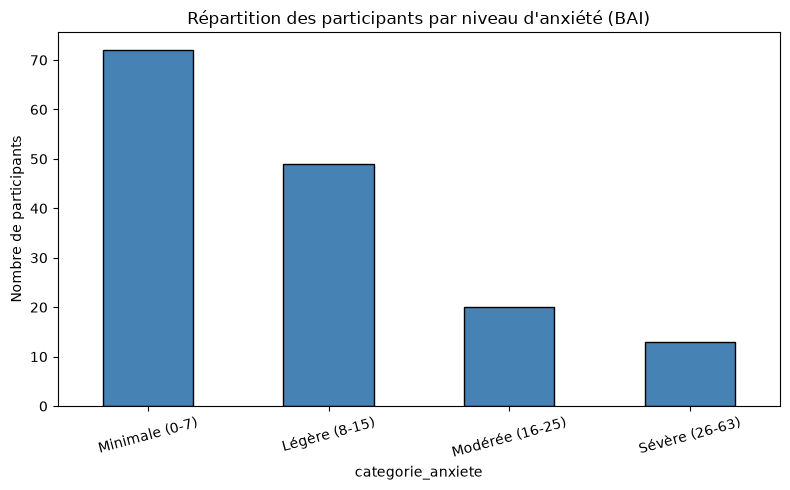

In [60]:
plt.figure(figsize=(8, 5))
repartition.plot(kind="bar", color="steelblue", edgecolor="black")
plt.ylabel("Nombre de participants")
plt.title("Répartition des participants par niveau d'anxiété (BAI)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Relation entre score BAI et info socio demo? 

In [61]:
df_SD_PS = df_SD_PS.rename(columns={
    "Quel est votre âge ?": "age",
    "Comment vous identifiez-vous ?\xa0": "genre"
})

#df_merged = pd.concat([df_BAI[["score_total"]], df_SD_PS[["age", "genre"]]], axis=1)
df_merged = pd.concat([df_BAI[items + ["score_total"]], df_SD_PS[["age", "genre"]]], axis=1)


In [62]:
# correlation age et chq item de BAI
from scipy import stats
resultats = []

for item in items:
    sous_df = df_merged[["age", item]].dropna()
    
    r_pearson, p_pearson = stats.pearsonr(sous_df["age"], sous_df[item])
    rho_spearman, p_spearman = stats.spearmanr(sous_df["age"], sous_df[item])
    
    resultats.append({
        "item": item,
        "pearson_r": round(r_pearson, 3),
        "pearson_p": round(p_pearson, 4),
        "spearman_rho": round(rho_spearman, 3),
        "spearman_p": round(p_spearman, 4)
    })

df_resultats = pd.DataFrame(resultats)
print(df_resultats)

                                                 item  pearson_r  pearson_p  \
0   Au cours des 7 derniers jours, j’ai été affect...     -0.237     0.0031   
1   Au cours des 7 derniers jours, j’ai été affect...     -0.164     0.0420   
2   Au cours des 7 derniers jours, j’ai été affect...     -0.286     0.0003   
3   Au cours des 7 derniers jours, j’ai été affect...     -0.268     0.0008   
4   Au cours des 7 derniers jours, j’ai été affect...     -0.241     0.0026   
5   Au cours des 7 derniers jours, j’ai été affect...     -0.324     0.0000   
6   Au cours des 7 derniers jours, j’ai été affect...     -0.225     0.0050   
7   Au cours des 7 derniers jours, j’ai été affect...     -0.122     0.1333   
8   Au cours des 7 derniers jours, j’ai été affect...     -0.147     0.0689   
9   Au cours des 7 derniers jours, j’ai été affect...     -0.297     0.0002   
10  Au cours des 7 derniers jours, j’ai été affect...     -0.230     0.0041   
11  Au cours des 7 derniers jours, j’ai été affect..

In [63]:
# correlation entre age et le total score BAI


# Corrélation de Pearson (relation linéaire)
r, p = stats.pearsonr(df_merged["age"].dropna(), df_merged.loc[df_merged["age"].notna(), "score_total"])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# Corrélation de Spearman (plus robuste, ne suppose pas de linéarité)
rho, p = stats.spearmanr(df_merged["age"], df_merged["score_total"], nan_policy="omit")
print(f"Spearman rho = {rho:.3f}, p = {p:.4f}")

Pearson r = -0.361, p = 0.0000
Spearman rho = -0.359, p = 0.0000


Il y a une difference significative d'age pour le score d'anxiete

In [64]:
print(df_merged["genre"].value_counts())

# Moyennes par groupe
print(df_merged.groupby("genre")["score_total"].mean())

# Test statistique (si 2 groupes : test t ; si plus de 2 : ANOVA)
groupes = [g["score_total"].dropna().values for _, g in df_merged.groupby("genre")]

if len(groupes) == 2:
    t, p = stats.ttest_ind(*groupes)
    print(f"Test t : t = {t:.3f}, p = {p:.4f}")
else:
    f, p = stats.f_oneway(*groupes)
    print(f"ANOVA : F = {f:.3f}, p = {p:.4f}")

genre
Femme          113
Homme           40
Non-binaire      1
Name: count, dtype: int64
genre
Femme          11.672566
Homme           6.050000
Non-binaire     5.000000
Name: score_total, dtype: float64
ANOVA : F = 6.801, p = 0.0015


IL y a une difference significative entre les genres en ce qui concerne le score BAI d'anxiete, avec les femmes un score significativement plus élevé. En revanche, bcp plus de femmes ont participé à l'étude, ce qui biaise les resultats. 

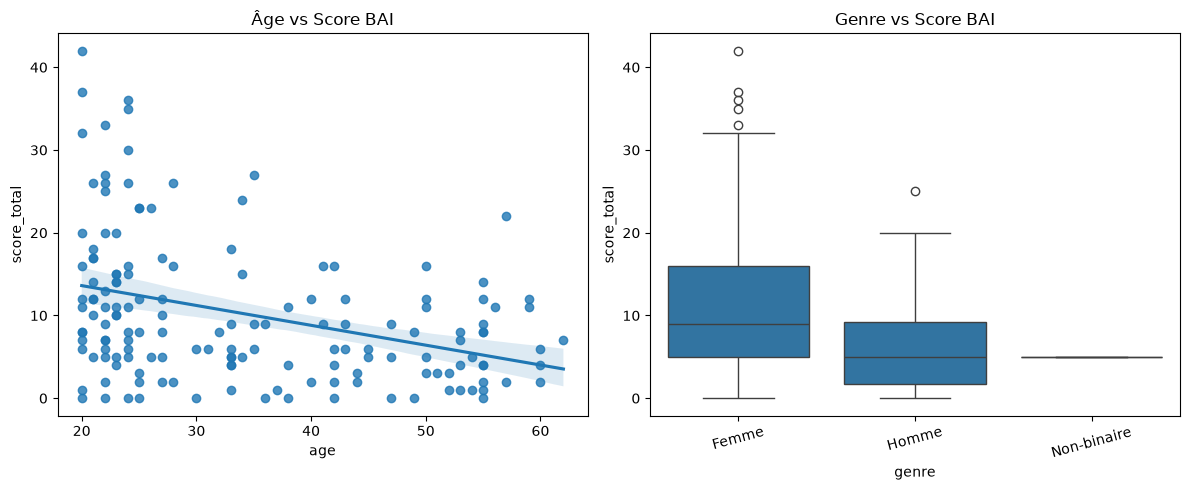

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Âge vs score (nuage de points + droite de régression)
sns.regplot(data=df_merged, x="age", y="score_total", ax=axes[0])
axes[0].set_title("Âge vs Score BAI")

# Genre vs score (boxplot)
sns.boxplot(data=df_merged, x="genre", y="score_total", ax=axes[1])
axes[1].set_title("Genre vs Score BAI")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [66]:

from scipy.stats import shapiro

for g in df_merged["genre"].unique():
    stat, p = shapiro(df_merged[df_merged["genre"] == g]["score_total"])
    print(f"{g} : p = {p:.4f}")

Femme : p = 0.0000
Homme : p = 0.0004
Non-binaire : p = nan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12208\2498309101.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_merged[df_merged["genre"] == g]["score_total"])


In [67]:
from scipy.stats import mannwhitneyu
groupe1 = df_merged[df_merged["genre"] == "Homme"]["score_total"]
groupe2 = df_merged[df_merged["genre"] == "Femme"]["score_total"]

stat, p_value = mannwhitneyu(groupe1, groupe2)
print(f"U = {stat:.3f}, p = {p_value:.4f}")

U = 1348.500, p = 0.0002


difference significative entre homme femme selon BAI

* df_PS --> age, sexe 
* df_BAI --> score total 
* Modele lineaire avec score total comme variable dépendante et age et sexe comme variables indépendantes.

In [68]:

import statsmodels.formula.api as smf

model = smf.ols("score_total ~ age + genre", data=df_merged).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            score_total   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     11.81
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           5.44e-07
Time:                        12:37:05   Log-Likelihood:                -535.15
No. Observations:                 154   AIC:                             1078.
Df Residuals:                     150   BIC:                             1090.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               19.0664 

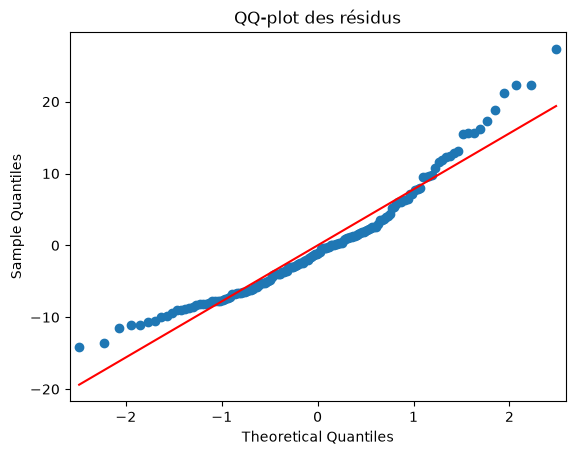

In [69]:

import statsmodels.api as sm
resid = model.resid

# 3. QQ-plot (vérifie la normalité des résidus)
sm.qqplot(resid, line='r')
plt.title('QQ-plot des résidus')
plt.show()

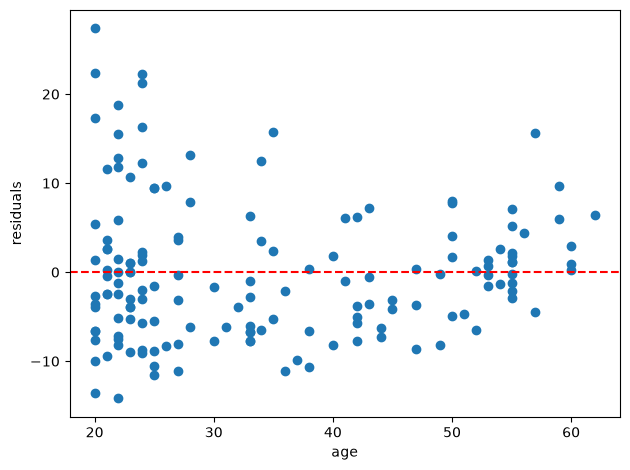

In [70]:
# Distrib doit etre autour de 0
plt.scatter(df_merged['age'], resid)
plt.xlabel('age')
plt.ylabel('residuals') 
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Extraction df TSQ

In [71]:
cols_TSQ = df_PS.columns[46:87]  # de la colonne 48 à la colonne 88 incluse (48 + 40 suivantes = 40 colonnes)
print(cols_TSQ)
print(len(cols_TSQ)) 

Index(['1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []',
       '2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le passé et le présent semblent être des îles isolées sans aucun pont entre elles.""Je n'ai pas accès à mon passé.""Je me sens déconnecté(e) de mon propre passé."  []',
       '3 - Je me sens vraiment à cran, comme si j'étais constamment sur mes gardes.  Exemples :"J’ai constamment l’impression, qu'à tout moment, quelque chose de grave pourrait se produire.""Je ne parviens jamais à me détendre.""Je peux difficilement me contrôler face à des mouvements brusques ou lorsque j'entends de

In [72]:

df_TSQ = df_PS[cols_TSQ]

In [73]:

df_TSQ.drop(columns=["Nous vous remercions pour votre engagement et vous invitons à passer à la suite de ce questionnaire.\xa0"], inplace=True) 

il y a une colonne en trop : "nous vous remercions pour votre engagement etc"

In [74]:

for i, col in enumerate(df_TSQ.columns):
    print(i, col)

0 1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
1 2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le passé et le présent semblent être des îles isolées sans aucun pont entre elles.""Je n'ai pas accès à mon passé.""Je me sens déconnecté(e) de mon propre passé."  []
2 3 - Je me sens vraiment à cran, comme si j'étais constamment sur mes gardes.  Exemples :"J’ai constamment l’impression, qu'à tout moment, quelque chose de grave pourrait se produire.""Je ne parviens jamais à me détendre.""Je peux difficilement me contrôler face à des mouvements brusques ou lorsque j'entends des sons forts."  []
3 4

In [75]:

df_TSQ.describe()

,"1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus. Exemples :""J'ai le sentiment que le futur est bien trop incertain pour moi.""""Je ressens que le futur est comme bloqué pour moi.""""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."" []","2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas. Exemples :"" Le futur, le passé et le présent semblent être des îles isolées sans aucun pont entre elles.""""Je n'ai pas accès à mon passé.""""Je me sens déconnecté(e) de mon propre passé."" []","3 - Je me sens vraiment à cran, comme si j'étais constamment sur mes gardes. Exemples :""J’ai constamment l’impression, qu'à tout moment, quelque chose de grave pourrait se produire.""""Je ne parviens jamais à me détendre.""""Je peux difficilement me contrôler face à des mouvements brusques ou lorsque j'entends des sons forts."" []","4 - Parfois, certaines parties de mon corps me semblent étranges, comme si elles ne m'appartenaient pas ou avaient été déconnectées les unes des autres, ou même comme si elles n'existaient pas du tout. Exemples :""J’ai l'étrange sentiment qu'il s'agit du corps de quelqu’un d’autre.""""Mon corps semble mort.""""Mon corps et/ou ses parties me sont étrangers et peuvent même me donner l'impression d'appartenir à quelqu'un d'autre."" []","5 - Parfois, j'ai l'impression qu'il y a un espace énorme entre ce qu'il s'est passé avant par rapport à ce qu'il se passe maintenant ou pourrait se passer après. C'est que j'ai tellement de mauvais souvenirs qu'il m'est difficile de me concentrer sur autre chose que le passé. Exemples :""Le passé m'importe chaque jour, ce qui me cause beaucoup de stress.""""Ma vie quotidienne est influencée par des milliers de souvenirs.""""Mes souvenirs du passé me bloquent dans le présent.""""Les souvenirs du passé me submergent et ne me laissent aucun répit."" []","6 - Parmi le passé, le présent et le futur, c'est le présent qui m'accable le plus. Exemples :""J’ai l'impression d’être enfermé(e) dans le présent.""""J'ai l'impression de ne pouvoir accéder ni au passé ni au futur.""""Je sens que je suis exclu(e) du passé ou que mon avenir est coincé dans le moment présent."" []","7 - Même dans des endroits que je connais bien, je me sens parfois complètement perdu(e) ou désorienté(e), n'étant pas certain(e) de comment avancer ou reculer. C'est comme si j'étais constamment désorienté(e) et confus(e). Exemples :""Il m'est arrivé de me promener sans savoir où j'étais.""""Je n'arrive pas à trouver mon chemin ; je perds souvent mes repères et ne sais ni où aller ni comment avancer.""""J'ai souvent l'impression d'être coincé(e) et paralysé(e) dans certaines positions et moments précis.""""Je ne peux pas décider où aller et comment y aller."" []","8 - Je me sens déconnecté(e) et désynchronisé(e) de moi-même, notamment de mes pensées, émotions et souvenirs. Exemples :""Je me sens déconnecté(e) de mes propres pensées, qui sont sans rapport avec moi même.""""Mes émotions me semblent étrangères, sans lien avec moi-même.""""Mon esprit ressemble à un orchestre dont les différents instruments ne jouent pas du tout ensemble.""""Je ne suis pas du tout en phase/harmonie avec moi-même."" []","9 - Je suis inquiet(e) des changements dans ma vie, et me sens submergé(e). Exemples :""C’est comme si mon esprit était rempli d’une musique cacophonique au volume sonore de plus en plus fort.""""Si je devais peindre ce que je ressens dans mes mauvais moments, je peindrais un tableau entièrement noir avec moi à peine coloré(e) au centre.""""Je me sens complètement submergé(e) par mes propres émotions et pensées."" []","10 - J'ai souvent le sentiment que le futur contient une série de menaces, comme si je savais que quelque chose de grave allait arriver imminemment. Exemples :""L'avenir me semble dangereux.""""J'évite de penser à l'avenir.""""Je suis i

In [76]:

# Compter le nombre de lignes complètement vides (toutes les valeurs sont NaN)
lignes_vides = df_TSQ.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")
percent_missing = (df_TSQ.isnull().sum() / len(df_TSQ) * 100).sort_values(ascending=False)
print(percent_missing)
# rien n'est vide, on peut donc continuer avec le traitement 

Nombre de lignes complètement vides : 0
1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []                                                                                                                                                                                                                                                                                                                                                                                                                                                       0.0
2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le passé et le présent s

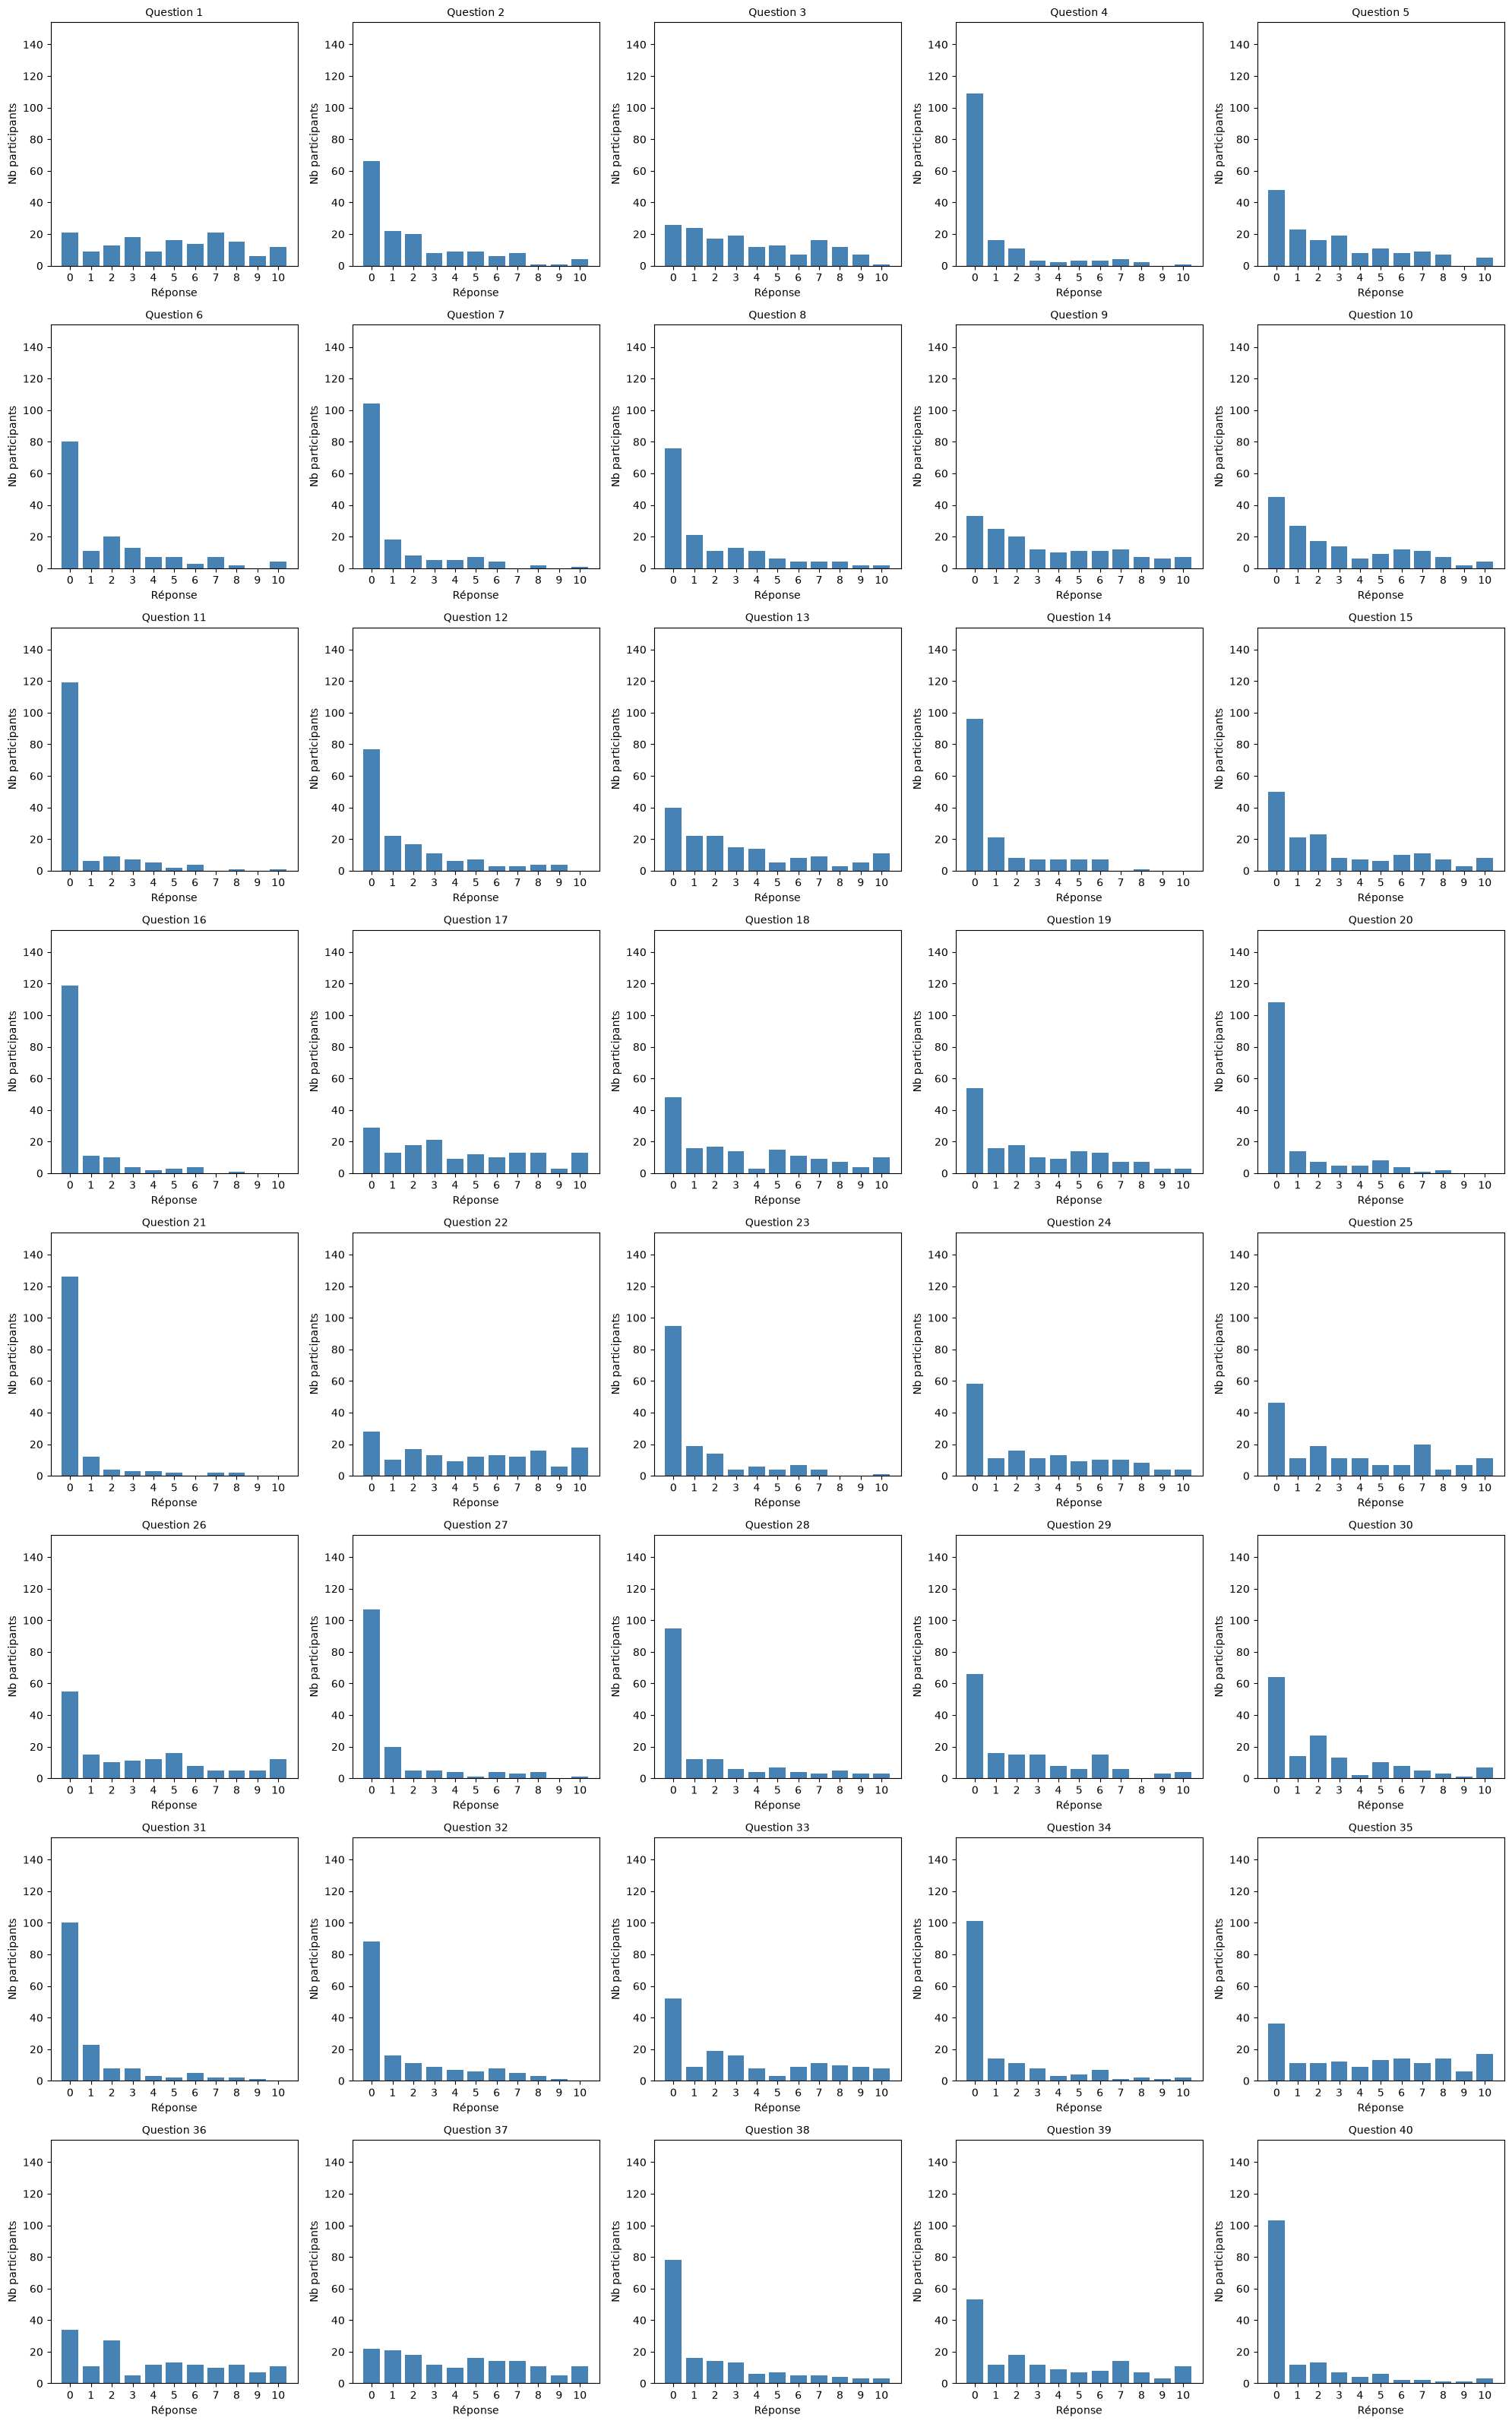

In [77]:

items = df_TSQ.columns.tolist()
df_TSQ[items] = df_TSQ[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_TSQ[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [78]:

for i in items:
    print(f"Question : {i}")
    print(df_TSQ[i].value_counts())
    print("\n")

Question : 1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
7.0     21
0.0     21
3.0     18
5.0     16
8.0     15
6.0     14
2.0     13
10.0    12
1.0      9
4.0      9
9.0      6
Name: count, dtype: int64


Question : 2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exe

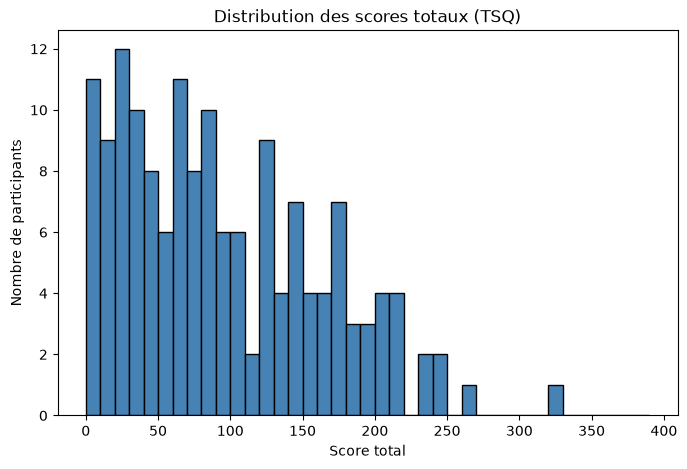

In [79]:
df_TSQ["score_total"] = df_TSQ.sum(axis=1)
df_TSQ["score_total"] = df_TSQ[items].sum(axis=1)
df_TSQ["score_total"].describe()

plt.figure(figsize=(8, 5))
plt.hist(df_TSQ["score_total"], bins=range(0, 400, 10), color="steelblue", edgecolor="black") #10 x40  = 400 (score max possible)
plt.xlabel("Score total")
plt.ylabel("Nombre de participants")
plt.title("Distribution des scores totaux (TSQ)")
plt.show()

# voir le score des participants avec diag pour établir un seuil "élevé" à la TSQ pour les participants sains. Avoir comme une reference

In [80]:
df_TSQ_PD = df_PD[cols_TSQ]
df_TSQ_PD.drop(columns=["Nous vous remercions pour votre engagement et vous invitons à passer à la suite de ce questionnaire.\xa0"], inplace=True) 

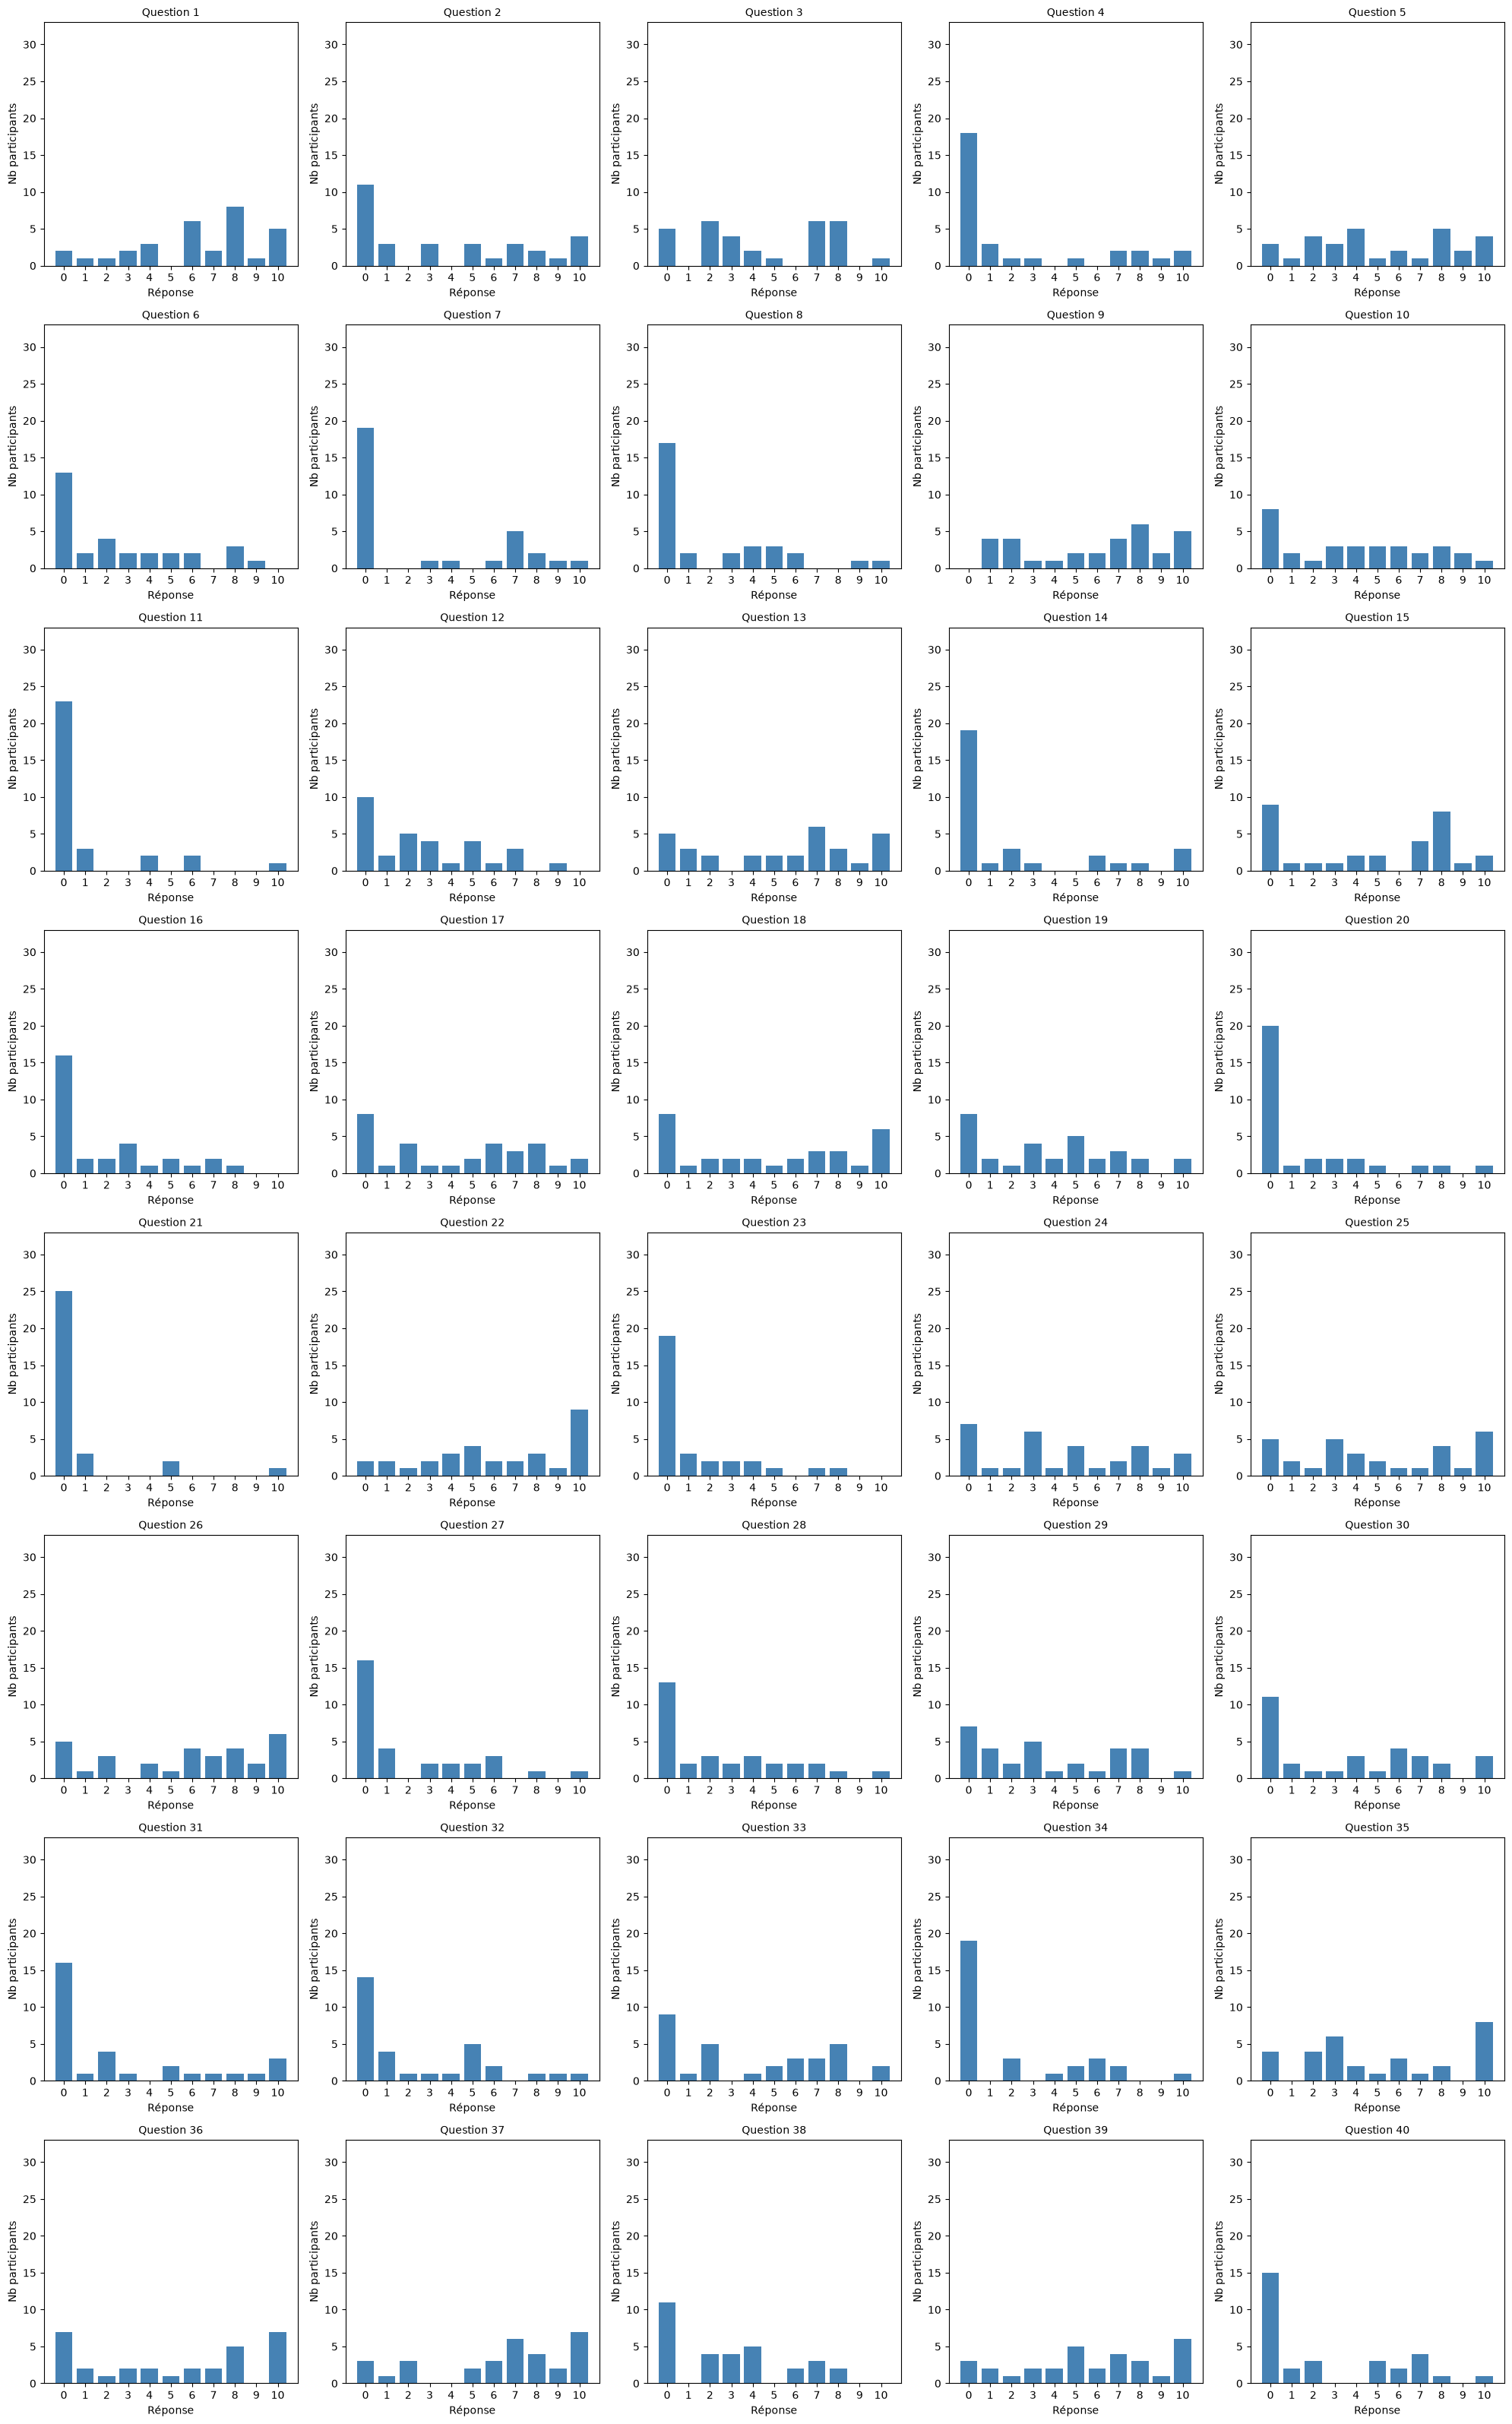

In [81]:
items = df_TSQ_PD.columns.tolist()
df_TSQ_PD[items] = df_TSQ_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_TSQ_PD[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 33)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [82]:
for i in items:
    print(f"Question : {i}")
    print(df_TSQ_PD[i].value_counts())
    print("\n")


Question : 1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
8.0     8
6.0     6
10.0    5
4.0     3
0.0     2
3.0     2
7.0     2
1.0     1
9.0     1
2.0     1
Name: count, dtype: int64


Question : 2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le

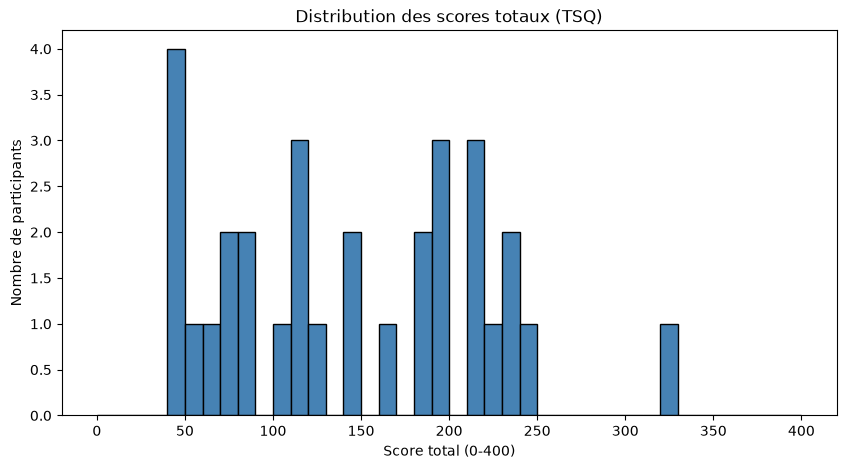

In [83]:
df_TSQ_PD["score_total"] = df_TSQ_PD[items].sum(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(df_TSQ_PD["score_total"], bins=range(0, 401, 10), color="steelblue", edgecolor="black")
plt.xlabel("Score total (0-400)")
plt.ylabel("Nombre de participants")
plt.title("Distribution des scores totaux (TSQ)")
plt.show()

In [84]:
df_TSQ["score_total"].median()

np.float64(81.0)

In [85]:
df_TSQ_PD["score_total"].median()
df_TSQ_PD["score_total"].describe()

count     31.000000
mean     145.774194
std       74.449853
min       43.000000
25%       81.000000
50%      141.000000
75%      204.500000
max      322.000000
Name: score_total, dtype: float64

# OK on va prendre la mediane = 145 comme seuil

In [86]:
# voir si les participants qui ont des scores élevés sur le TSQ ont aussi des score élevés sur le BAI
# prendre un seuil = quand est ce que le score est considéré élevé
# sélectionner les personnes qui ont ces scores
# prendre les personnes qui ont des profils BAI modérés et sévères et comparer si ce sont les memes personness (scores cote à cote pour chaque indiv)

In [87]:
# 1. Sélectionner les participants "Modérée" et "Sévère" dans BAI
profils_eleves_bai = df_BAI["categorie_anxiete"].isin(["Modérée (16-25)", "Sévère (26-63)"])

# 2. Sélectionner les participants avec TSQ > 145
score_eleve_tsq = df_TSQ["score_total"] > 145

# Vérification rapide que les deux ont bien la même longueur / ordre
print(len(df_BAI), len(df_TSQ))

154 154


In [88]:
comparaison = pd.DataFrame({
    "BAI_eleve": profils_eleves_bai.values,
    "TSQ_eleve": score_eleve_tsq.values
})

# Table croisée : qui est dans quel groupe
tableau_croise = pd.crosstab(comparaison["BAI_eleve"], comparaison["TSQ_eleve"])
print(tableau_croise)

TSQ_eleve  False  True 
BAI_eleve              
False        101     20
True          16     17


26/154 participants sains qui ont de l'anxiété élevée ont des scores TSQ élevés. 7/154 personnes qui ont de l'anxiété élevée n'ont pas des scores TSQ élevées. 85/154 n'ont pas d'anxiété elevée ni des scores TSQ élevés. 36/154 ont un score TSQ élevé sans avoir d'anxiété élevé. 

In [89]:
n_total = len(comparaison)
n_bai_eleve = profils_eleves_bai.sum()
n_tsq_eleve = score_eleve_tsq.sum()
n_les_deux = (profils_eleves_bai & score_eleve_tsq).sum()

print(f"Participants BAI élevé : {n_bai_eleve} ({n_bai_eleve/n_total*100:.1f}%)")
print(f"Participants TSQ élevé : {n_tsq_eleve} ({n_tsq_eleve/n_total*100:.1f}%)")
print(f"Participants avec les deux : {n_les_deux} ({n_les_deux/n_total*100:.1f}%)")

# % des BAI élevés qui ont aussi un TSQ élevé
if n_bai_eleve > 0:
    print(f"Parmi les BAI élevés, {n_les_deux/n_bai_eleve*100:.1f}% ont aussi un TSQ élevé")

Participants BAI élevé : 33 (21.4%)
Participants TSQ élevé : 37 (24.0%)
Participants avec les deux : 17 (11.0%)
Parmi les BAI élevés, 51.5% ont aussi un TSQ élevé


Ici on voit que 78.8% des personnes avec anxiété élevée ont un score TSQ élevé

In [90]:
comparaison_df = pd.DataFrame({
    "score_BAI": df_BAI["score_total"],
    "profil_BAI": df_BAI["categorie_anxiete"],
    "score_TSQ": df_TSQ["score_total"]
})

print(comparaison_df)

print(comparaison_df)
comparaison_df["BAI_eleve"] = comparaison_df["profil_BAI"].isin(["Modérée (16-25)", "Sévère (26-63)"])
comparaison_df["TSQ_eleve"] = comparaison_df["score_TSQ"] > 145
comparaison_df["les_deux_eleves"] = comparaison_df["BAI_eleve"] & comparaison_df["TSQ_eleve"]

print(comparaison_df)

     score_BAI       profil_BAI  score_TSQ
1         18.0  Modérée (16-25)      141.0
3         12.0    Légère (8-15)      170.0
5         20.0  Modérée (16-25)      146.0
9          4.0   Minimale (0-7)        8.0
10         2.0   Minimale (0-7)       31.0
..         ...              ...        ...
304        8.0    Légère (8-15)       37.0
306       18.0  Modérée (16-25)      131.0
307        9.0    Légère (8-15)      116.0
308       12.0    Légère (8-15)       79.0
311        4.0   Minimale (0-7)       28.0

[154 rows x 3 columns]
     score_BAI       profil_BAI  score_TSQ
1         18.0  Modérée (16-25)      141.0
3         12.0    Légère (8-15)      170.0
5         20.0  Modérée (16-25)      146.0
9          4.0   Minimale (0-7)        8.0
10         2.0   Minimale (0-7)       31.0
..         ...              ...        ...
304        8.0    Légère (8-15)       37.0
306       18.0  Modérée (16-25)      131.0
307        9.0    Légère (8-15)      116.0
308       12.0    Légère (8-15

In [91]:
concordants = comparaison_df[comparaison_df["les_deux_eleves"]]
print(concordants)

     score_BAI       profil_BAI  score_TSQ  BAI_eleve  TSQ_eleve  \
5         20.0  Modérée (16-25)      146.0       True       True   
16        26.0   Sévère (26-63)      214.0       True       True   
31        23.0  Modérée (16-25)      161.0       True       True   
121       33.0   Sévère (26-63)      212.0       True       True   
124       35.0   Sévère (26-63)      213.0       True       True   
132       20.0  Modérée (16-25)      170.0       True       True   
145       23.0  Modérée (16-25)      208.0       True       True   
159       17.0  Modérée (16-25)      192.0       True       True   
160       36.0   Sévère (26-63)      323.0       True       True   
175       30.0   Sévère (26-63)      231.0       True       True   
184       24.0  Modérée (16-25)      150.0       True       True   
206       32.0   Sévère (26-63)      249.0       True       True   
212       37.0   Sévère (26-63)      263.0       True       True   
226       25.0  Modérée (16-25)      209.0      

In [92]:
cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

In [93]:
index_concordants = concordants.index
items_concordants = df.loc[index_concordants, items]

# pour chaque participant, on obtient une liste "nom de l'item -> score"
resultat = items_concordants.stack()
resultat_filtre = resultat[resultat > 5]
with pd.option_context("display.max_rows", None):
    print(resultat_filtre)


5    TSQ1      7.0
     TSQ5      6.0
     TSQ12     9.0
     TSQ13     6.0
     TSQ15    10.0
     TSQ17     6.0
     TSQ19     8.0
     TSQ26     8.0
     TSQ30     6.0
     TSQ33     6.0
     TSQ37     8.0
     TSQ38     6.0
     TSQ39     6.0
16   TSQ1      7.0
     TSQ4      8.0
     TSQ6      7.0
     TSQ8      8.0
     TSQ9      7.0
     TSQ12     7.0
     TSQ13     6.0
     TSQ14     6.0
     TSQ15     6.0
     TSQ18     7.0
     TSQ19     6.0
     TSQ20     7.0
     TSQ22     9.0
     TSQ24     8.0
     TSQ25     7.0
     TSQ27    10.0
     TSQ30    10.0
     TSQ33     8.0
     TSQ34     6.0
     TSQ35     8.0
     TSQ36     9.0
     TSQ37     6.0
     TSQ39     7.0
31   TSQ1      7.0
     TSQ3      7.0
     TSQ6      7.0
     TSQ9      8.0
     TSQ15    10.0
     TSQ17     8.0
     TSQ22    10.0
     TSQ29     6.0
     TSQ32     6.0
     TSQ33     7.0
     TSQ35     8.0
     TSQ36     6.0
     TSQ37     6.0
121  TSQ1      9.0
     TSQ3      7.0
     TSQ5      7.0
     TSQ9   

In [94]:
index_concordants = concordants.index
items_concordants = df.loc[index_concordants, items]
resultat = items_concordants.stack()

resultat_df = resultat.reset_index()
resultat_df.columns = ["participant", "item", "score"]

# on garde seulement les scores entre 6 et 10 inclus
resultat_6_10 = resultat_df[(resultat_df["score"] >= 6) & (resultat_df["score"] <= 10)]

# on groupe par score, et on liste les items concernés
groupes = resultat_6_10.groupby("score")["item"].apply(list)

with pd.option_context("display.max_rows", None):
    print(groupes)

score
6.0     [TSQ5, TSQ13, TSQ17, TSQ30, TSQ33, TSQ38, TSQ3...
7.0     [TSQ1, TSQ1, TSQ6, TSQ9, TSQ12, TSQ18, TSQ20, ...
8.0     [TSQ19, TSQ26, TSQ37, TSQ4, TSQ8, TSQ24, TSQ33...
9.0     [TSQ12, TSQ22, TSQ36, TSQ1, TSQ9, TSQ19, TSQ31...
10.0    [TSQ15, TSQ27, TSQ30, TSQ15, TSQ22, TSQ25, TSQ...
Name: item, dtype: object


In [95]:
comptage = (
    resultat_6_10
    .groupby(["score", "item"])
    .size()
    .reset_index(name="nombre_participants")
)

with pd.option_context("display.max_rows", None):
    print(comptage)

     score   item  nombre_participants
0      6.0   TSQ1                    2
1      6.0  TSQ10                    3
2      6.0  TSQ11                    2
3      6.0  TSQ13                    3
4      6.0  TSQ14                    3
5      6.0  TSQ15                    1
6      6.0  TSQ16                    2
7      6.0  TSQ17                    2
8      6.0  TSQ19                    5
9      6.0   TSQ2                    1
10     6.0  TSQ20                    2
11     6.0  TSQ22                    1
12     6.0  TSQ23                    1
13     6.0  TSQ26                    1
14     6.0  TSQ27                    1
15     6.0  TSQ28                    1
16     6.0  TSQ29                    3
17     6.0  TSQ30                    2
18     6.0  TSQ31                    2
19     6.0  TSQ32                    4
20     6.0  TSQ33                    2
21     6.0  TSQ34                    1
22     6.0  TSQ35                    2
23     6.0  TSQ36                    2
24     6.0  TSQ37        

Parmis les personnes avec scores TSQ élevés + BAi élevés. 
Les items cotés à 10 (les plus votés cad >5 participants qui ont mis 10 à cet item) à la TSQ sont représentent (core) --> 4 items l'anxiete, 4 items MDD, 3 PTSD, 1 SZ, 1 Man. 
Ceux côtés à 9 --> majoritairement anxiété et MDD
Ceux cotés à 8 -- >maj anx et PTSD
Ceux côtés à 7 --> maj anx et PTSD
Ceux côtés à 6 --> maj SZ

Pour les participants avec TSQ élevés 

In [96]:
# sélection des participants avec TSQ élevé uniquement
tsq_eleve_seuls = comparaison_df[comparaison_df["TSQ_eleve"]]
index_tsq_eleve = tsq_eleve_seuls.index

# items pour ces participants
items_tsq_eleve = df.loc[index_tsq_eleve, items]

# format long : participant / item / score
resultat_tsq = items_tsq_eleve.stack().reset_index()
resultat_tsq.columns = ["participant", "item", "score"]

# filtrer les scores entre 6 et 10
resultat_tsq_6_10 = resultat_tsq[(resultat_tsq["score"] >= 6) & (resultat_tsq["score"] <= 10)]

# compter le nombre de participants par score/item
comptage_tsq = (
    resultat_tsq_6_10
    .groupby(["score", "item"])["participant"]
    .nunique()
    .reset_index(name="nombre_participants")
)

with pd.option_context("display.max_rows", None):
    print(comptage_tsq)

     score   item  nombre_participants
0      6.0   TSQ1                    5
1      6.0  TSQ10                    7
2      6.0  TSQ11                    4
3      6.0  TSQ12                    1
4      6.0  TSQ13                    3
5      6.0  TSQ14                    5
6      6.0  TSQ15                    4
7      6.0  TSQ16                    3
8      6.0  TSQ17                    4
9      6.0  TSQ18                    4
10     6.0  TSQ19                    7
11     6.0   TSQ2                    1
12     6.0  TSQ20                    4
13     6.0  TSQ22                    2
14     6.0  TSQ23                    5
15     6.0  TSQ24                    4
16     6.0  TSQ25                    1
17     6.0  TSQ26                    4
18     6.0  TSQ27                    2
19     6.0  TSQ28                    2
20     6.0  TSQ29                   10
21     6.0   TSQ3                    2
22     6.0  TSQ30                    2
23     6.0  TSQ31                    3
24     6.0  TSQ32        

pour les quotations :  
* 6 : majoritairement (>5 participant ont voté 6 à ces items): (4 items)anxiété, 3 MDD, 2 Man, 2 Sz, 1 PTSD
* 7 : maj 4 items anx, 4 MDD, 3 PTSD, 3 SZ, 1 Man
* 8 : maj 7 items anx, 5 PTSD, 3 MDD, 3 SZ, 3 Man
* 9 : maj 1 item anx, 1 man, 1 SZ
* 10 : maj 8 items anx, 5 PTSD, 4 MDD, 2 man, 2 SZ

Pour les participants avec TSQ élevés sans avoir BAI élevés

In [97]:
comparaison_df["tsq_seul"] = comparaison_df["TSQ_eleve"] & ~comparaison_df["BAI_eleve"]

# sélection des participants concernés
tsq_seul = comparaison_df[comparaison_df["tsq_seul"]]
index_tsq_seul = tsq_seul.index

# items pour ces participants
items_tsq_seul = df.loc[index_tsq_seul, items]

# format long : participant / item / score
resultat_tsq_seul = items_tsq_seul.stack().reset_index()
resultat_tsq_seul.columns = ["participant", "item", "score"]

# filtrer les scores entre 6 et 10
resultat_tsq_seul_6_10 = resultat_tsq_seul[(resultat_tsq_seul["score"] >= 6) & (resultat_tsq_seul["score"] <= 10)]

# compter le nombre de participants par score/item
comptage_tsq_seul = (
    resultat_tsq_seul_6_10
    .groupby(["score", "item"])["participant"]
    .nunique()
    .reset_index(name="nombre_participants")
)

with pd.option_context("display.max_rows", None):
    print(comptage_tsq_seul)

     score   item  nombre_participants
0      6.0   TSQ1                    3
1      6.0  TSQ10                    4
2      6.0  TSQ11                    2
3      6.0  TSQ12                    1
4      6.0  TSQ14                    2
5      6.0  TSQ15                    3
6      6.0  TSQ16                    1
7      6.0  TSQ17                    2
8      6.0  TSQ18                    4
9      6.0  TSQ19                    2
10     6.0  TSQ20                    2
11     6.0  TSQ22                    1
12     6.0  TSQ23                    4
13     6.0  TSQ24                    4
14     6.0  TSQ25                    1
15     6.0  TSQ26                    3
16     6.0  TSQ27                    1
17     6.0  TSQ28                    1
18     6.0  TSQ29                    7
19     6.0   TSQ3                    2
20     6.0  TSQ31                    1
21     6.0  TSQ32                    3
22     6.0  TSQ33                    2
23     6.0  TSQ34                    4
24     6.0  TSQ35        

pour les quotations :  
* 6 : majoritairement (>5 participant ont voté 6 à ces items): 1 item anxiété,  1 PTSD
* 7 : maj  3 MDD,1 item anx,1 SZ
* 8 : maj 1 items PTSD, 1 MDD, 1 Man
* 9 : maj 1 item anx, 1 man, 1 SZ
* 10 : maj 3 items anx, 1 PTSD, 2 MDD, 1 man, 1 SZ

# correlation entre score BAI et TSQ

r = 0.619, p = 0.0000


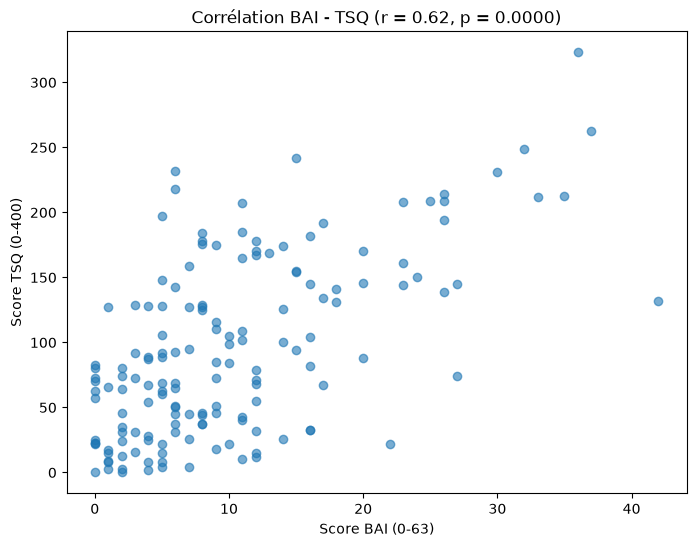

In [98]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df_BAI["score_total"], df_TSQ["score_total"])
print(f"r = {r:.3f}, p = {p_value:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(df_BAI["score_total"], df_TSQ["score_total"], alpha=0.6)
plt.xlabel("Score BAI (0-63)")
plt.ylabel("Score TSQ (0-400)")
plt.title(f"Corrélation BAI - TSQ (r = {r:.2f}, p = {p_value:.4f})")
plt.show()

on voit que plus le score BAI est élevé plus la TSQ est élevé. Correl + significative

In [99]:

print(len(df_SD_PS), len(df_TSQ))  # vérifie d'abord que ça correspond


154 154


r = -0.476, p = 0.0000


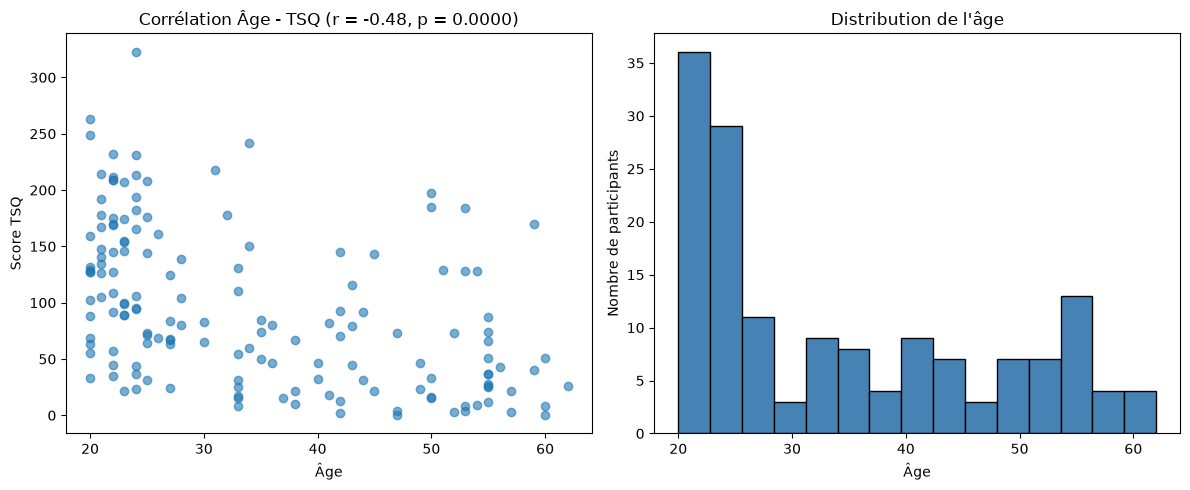

In [100]:
r, p_value = pearsonr(df_SD_PS["age"], df_TSQ["score_total"])
print(f"r = {r:.3f}, p = {p_value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sous-graphique 1 : nuage de points Age vs TSQ
axes[0].scatter(df_SD_PS["age"], df_TSQ["score_total"], alpha=0.6)
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Score TSQ")
axes[0].set_title(f"Corrélation Âge - TSQ (r = {r:.2f}, p = {p_value:.4f})")

# Sous-graphique 2 : par exemple un histogramme de l'âge
axes[1].hist(df_SD_PS["age"], bins=15, color="steelblue", edgecolor="black")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Nombre de participants")
axes[1].set_title("Distribution de l'âge")

plt.tight_layout()
plt.show()

On voit qu'il y a une correl negative significative cad que plus les participants sont jeunes plus les scores TSQ sont élevés. Cependant la majorité des participants sont jeunes cela biaise donc les résultats

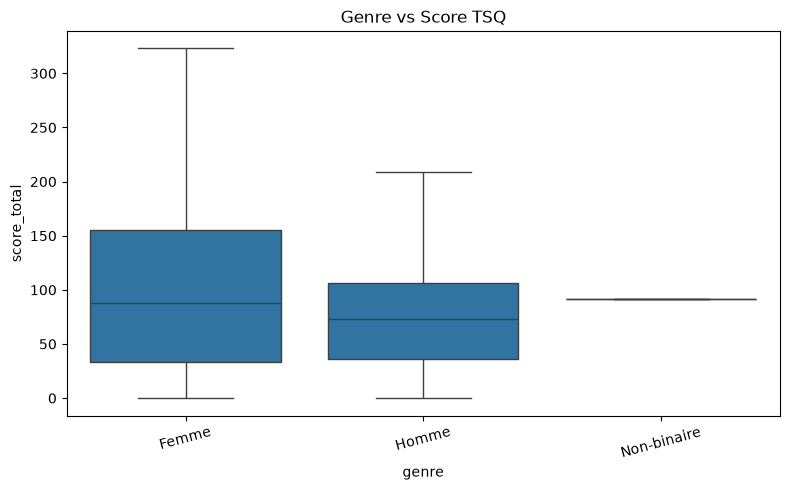

In [101]:
df_merged2 = pd.DataFrame({
    "genre": df_SD_PS["genre"].values,
    "age": df_SD_PS["age"].values,
    "score_total": df_TSQ["score_total"].values
})

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_merged2, x="genre", y="score_total", ax=ax)
ax.set_title("Genre vs Score TSQ")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [102]:
from scipy.stats import mannwhitneyu
groupe1 = df_merged2[df_merged2["genre"] == "Homme"]["score_total"]
groupe2 = df_merged2[df_merged2["genre"] == "Femme"]["score_total"]

stat, p_value = mannwhitneyu(groupe1, groupe2)
print(f"U = {stat:.3f}, p = {p_value:.4f}")

U = 1986.000, p = 0.2561


In [103]:
from scipy.stats import ttest_ind #suit une loi normale car p >0.05

groupe1 = df_merged2[df_merged2["genre"] == "Homme"]["score_total"]
groupe2 = df_merged2[df_merged2["genre"] == "Femme"]["score_total"]

stat, p_value = ttest_ind(groupe1, groupe2)
print(f"t = {stat:.3f}, p = {p_value:.4f}")

t = -1.573, p = 0.1178


pas de diff de genre selon TSQ 

                            OLS Regression Results                            
Dep. Variable:            score_total   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     44.49
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.46e-10
Time:                        12:38:42   Log-Likelihood:                -850.37
No. Observations:                 154   AIC:                             1705.
Df Residuals:                     152   BIC:                             1711.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    180.8903     13.800     13.108      0.0

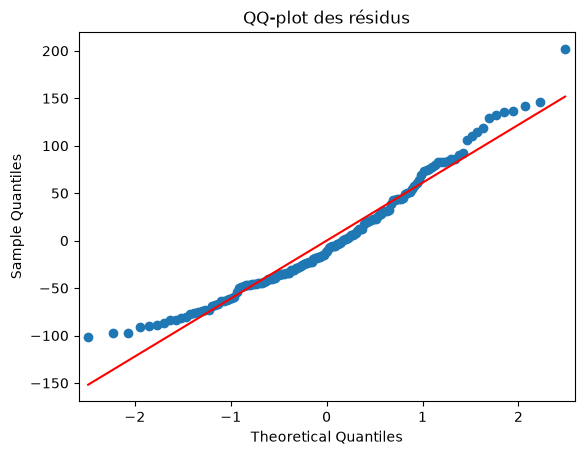

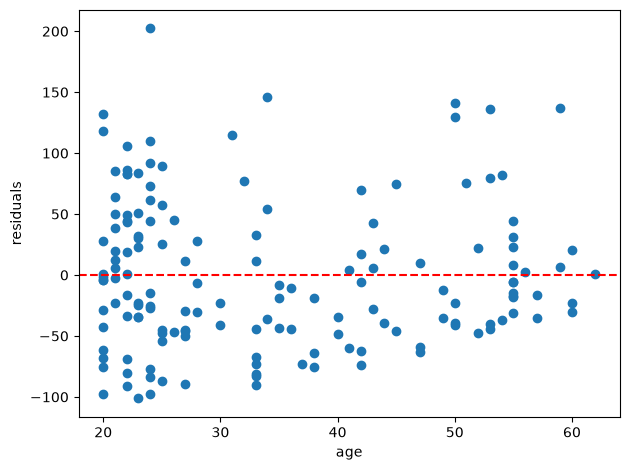

In [104]:

import statsmodels.formula.api as smf

model = smf.ols("score_total ~ age ", data=df_merged2).fit()
print(model.summary())
import statsmodels.api as sm
resid = model.resid

# 3. QQ-plot (vérifie la normalité des résidus)
sm.qqplot(resid, line='r')
plt.title('QQ-plot des résidus')
plt.show()# Distrib doit etre autour de 0
plt.scatter(df_merged2['age'], resid)
plt.xlabel('age')
plt.ylabel('residuals') 
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Correlation entre items core anxieux TSQ et BAI ? 

In [105]:
print(df_BAI.shape)
print(df.shape)

(154, 23)
(154, 41)


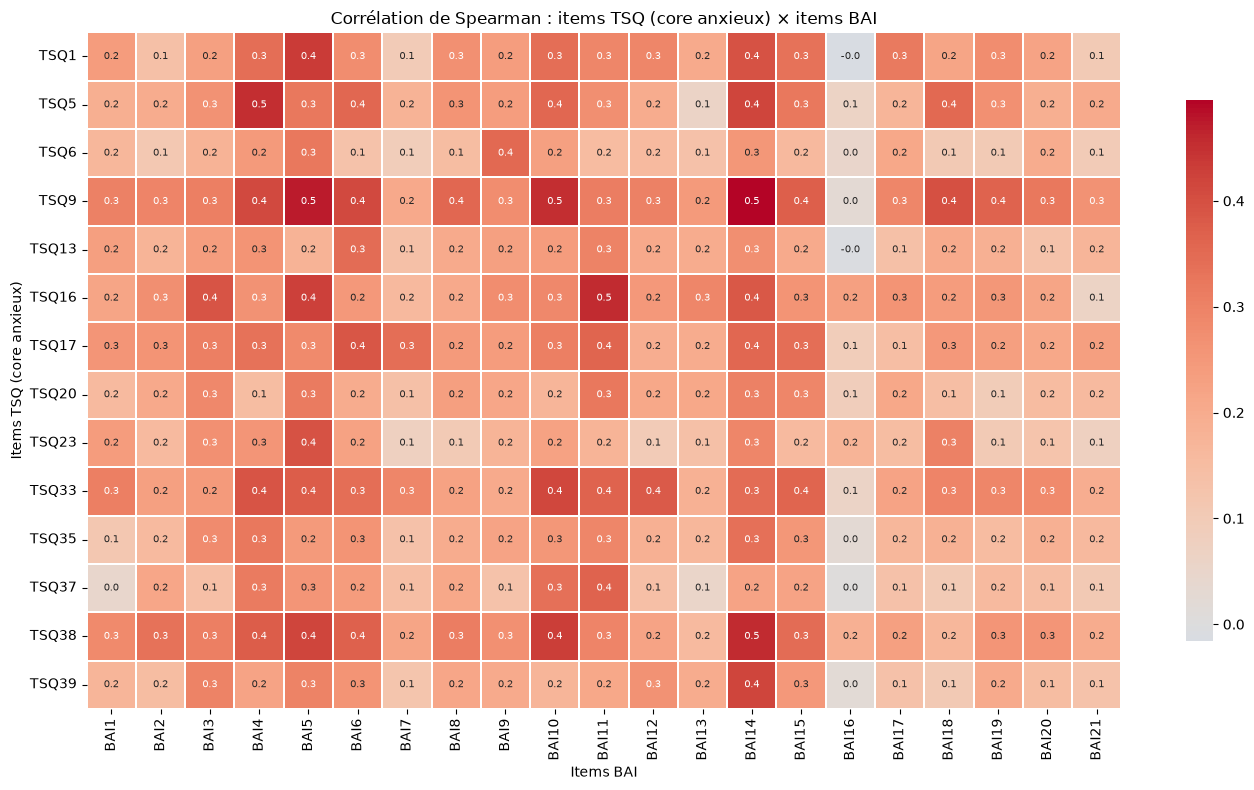

In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20',
                  'TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']

cols_bai_brutes = df_BAI.columns[0:21]

df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df[items_core_an], df_BAI[items_bai]], axis=1)

# matrice de corrélation complète (TSQ + BAI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes BAI
corr_matrix = corr_matrix_full.loc[items_core_an, items_bai]

# heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", annot_kws={"size": 7}, cmap="coolwarm", center=0,
            square=False, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Corrélation de Spearman : items TSQ (core anxieux) × items BAI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr
import numpy as np
from statsmodels.stats.multitest import multipletests

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)

for tsq_item in items_core_an:
    for bai_item in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[tsq_item, bai_item]].dropna()
        r, p = spearmanr(paired[tsq_item], paired[bai_item])
        corr_matrix.loc[tsq_item, bai_item] = r
        pval_matrix.loc[tsq_item, bai_item] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations significatives (Spearman, p corrigé < .05, FDR)")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

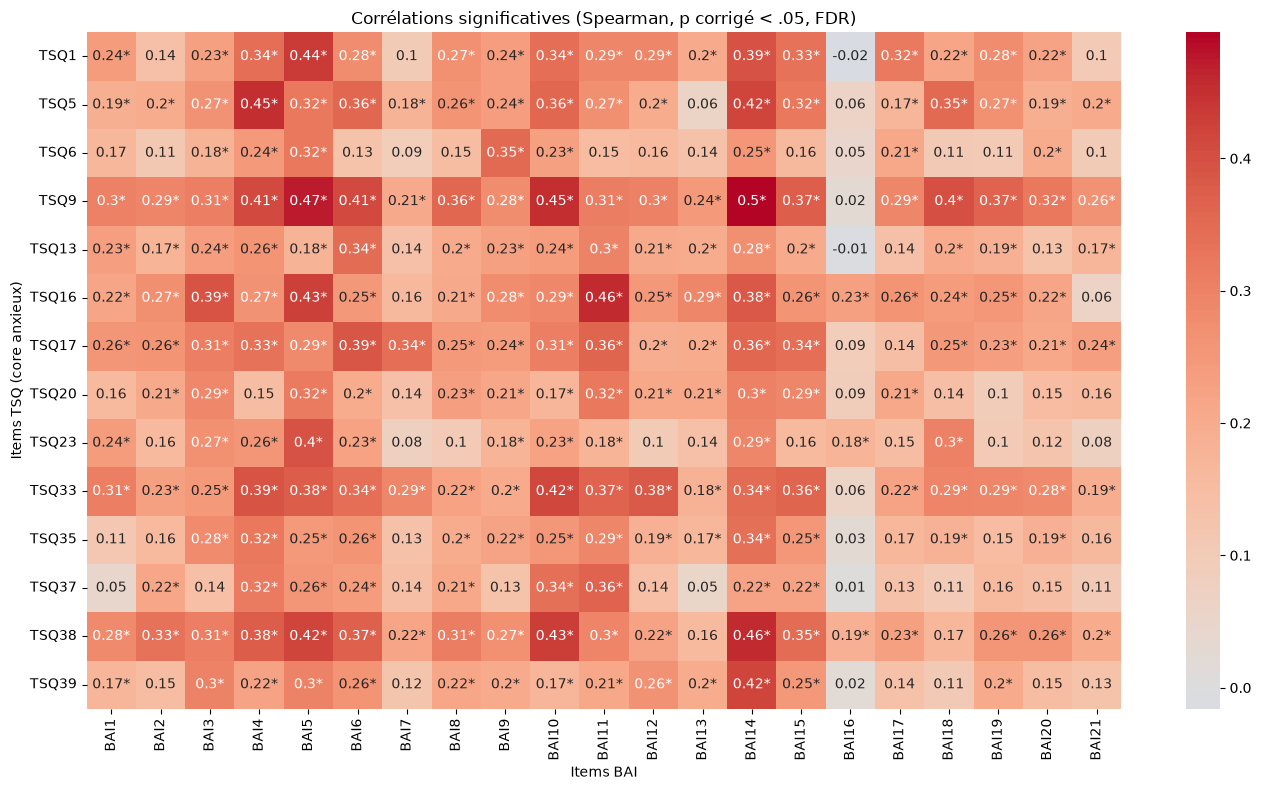

In [250]:
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations significatives (Spearman, p corrigé < .05, FDR)")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

rien au dessus de 0.5. 

Voir si different chez les personnes avec diag

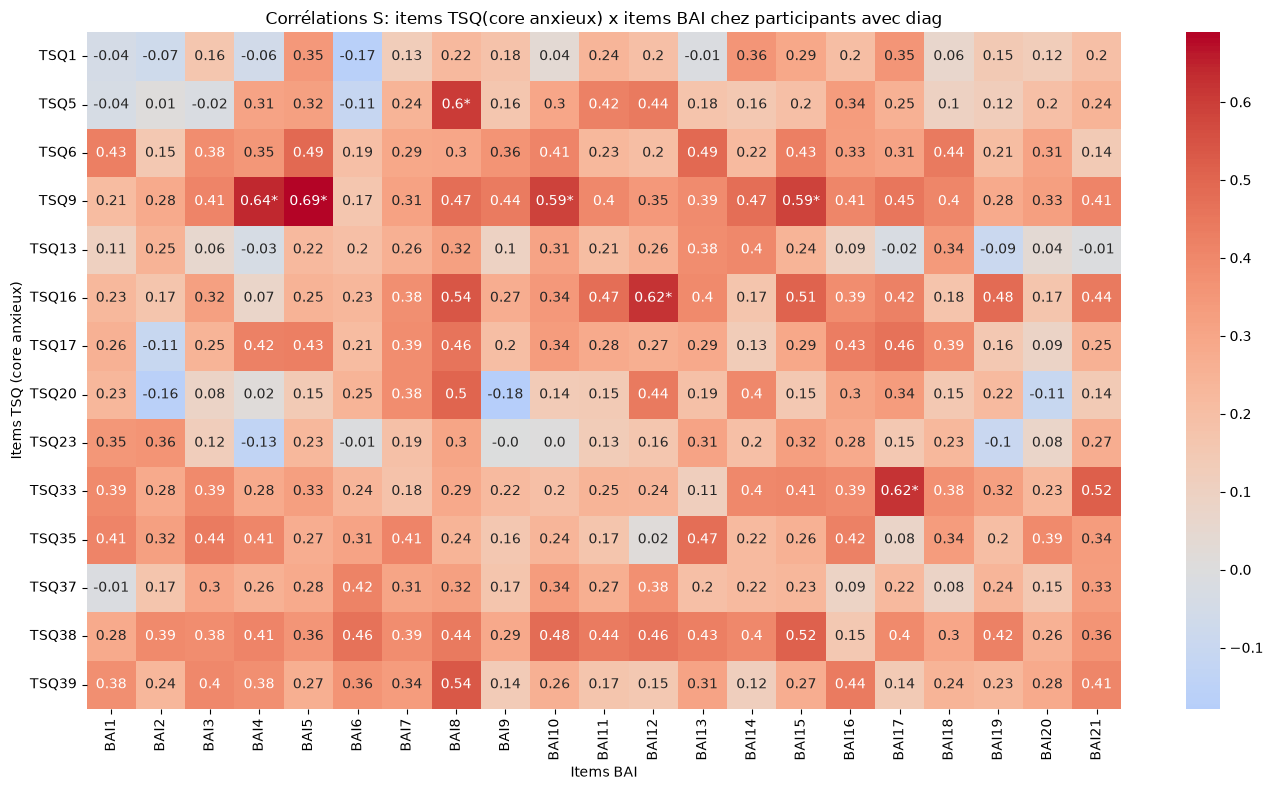

In [254]:
cols_tsq_brutes = df_TSQ_PD.columns[0:40]
df1 = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df1[items] = df1[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20',
                  'TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']

cols_bai_PD= df_BAI_PD.columns[0:21]

df_BAI_PD = df_BAI_PD.rename(columns=dict(zip(cols_bai_PD, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI_PD[items_bai] = df_BAI_PD[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df1[items_core_an], df_BAI_PD[items_bai]], axis=1)

# matrice de corrélation complète (TSQ + BAI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes BAI
corr_matrix = corr_matrix_full.loc[items_core_an, items_bai]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)

for i in items_core_an:
    for u in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(core anxieux) x items BAI chez participants avec diag")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

In [108]:
import numpy as np

# transformer la matrice croisée en liste de paires (item_TSQ, item_BAI, corrélation)
strong_corr = corr_matrix.stack().reset_index()
strong_corr.columns = ['item_TSQ', 'item_BAI', 'correlation']

# filtrer les corrélations fortes (positives > 0.6)
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

    item_TSQ item_BAI  correlation
67      TSQ9     BAI5     0.689310
66      TSQ9     BAI4     0.639427
116    TSQ16    BAI12     0.622842
205    TSQ33    BAI17     0.619786
28      TSQ5     BAI8     0.602008


In [109]:
print(df.index[:10], df_BAI.index[:10])
print(df.index.equals(df_BAI.index))
print(len(df), len(df_BAI))

Index([1, 3, 5, 9, 10, 12, 16, 17, 18, 19], dtype='int64') Index([1, 3, 5, 9, 10, 12, 16, 17, 18, 19], dtype='int64')
True
154 154


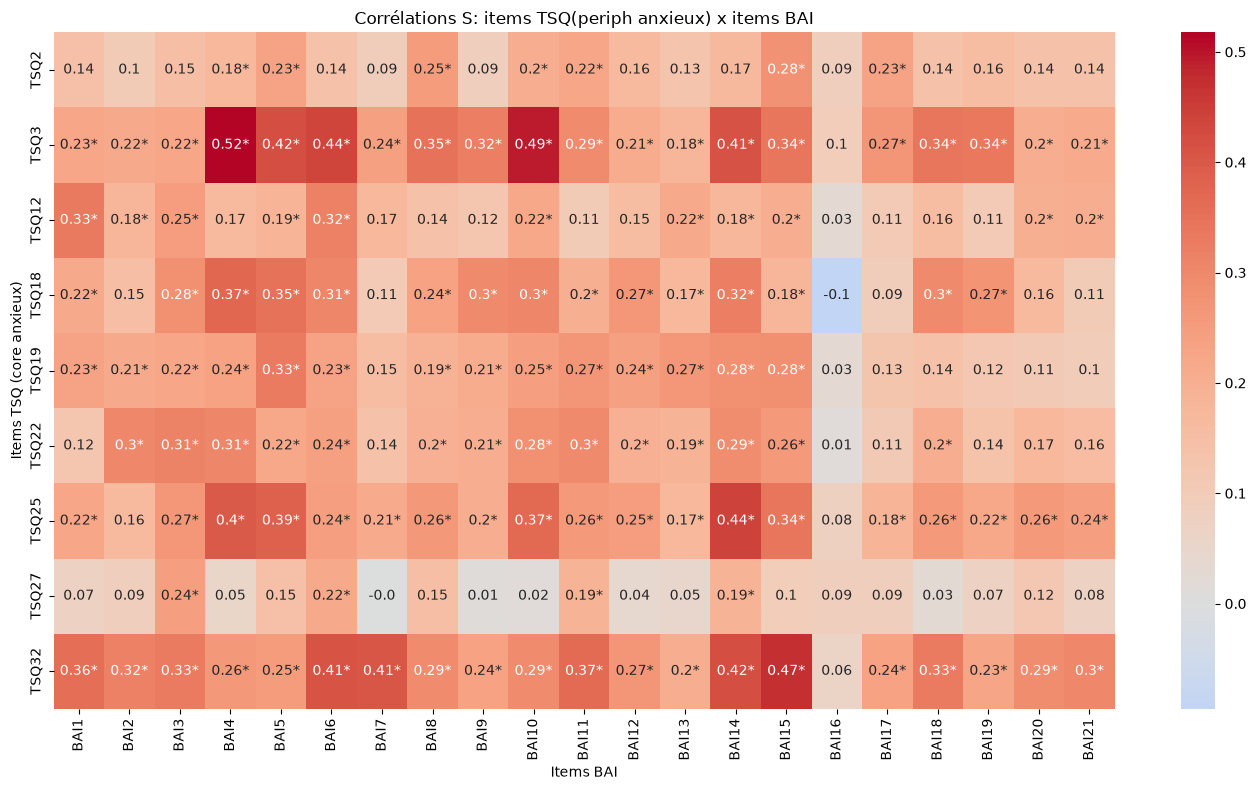

In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_periph_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27',
                  'TSQ32']

cols_bai_brutes = df_BAI.columns[0:21]

df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df[items_periph_an], df_BAI[items_bai]], axis=1)

# matrice de corrélation complète (TSQ + BAI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes BAI
corr_matrix = corr_matrix_full.loc[items_periph_an, items_bai]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)

for i in items_periph_an:
    for u in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(periph anxieux) x items BAI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

il n'y a pas de fortes correl

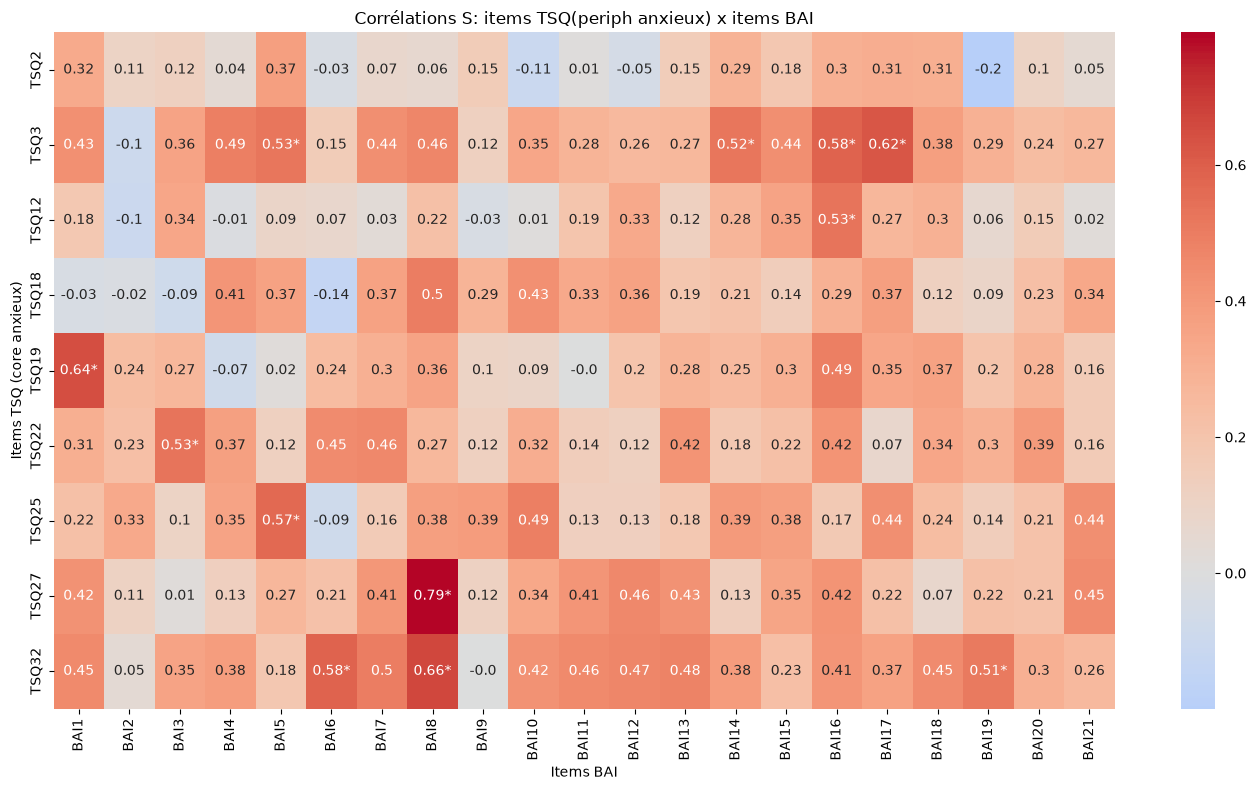

In [ ]:

items_periph_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27',
                  'TSQ32']

cols_tsq_brutes = df_TSQ_PD.columns[0:40]
df1 = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df1[items] = df1[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

cols_bai_PD= df_BAI_PD.columns[0:21]

df_BAI_PD = df_BAI_PD.rename(columns=dict(zip(cols_bai_PD, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI_PD[items_bai] = df_BAI_PD[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df1[items_periph_an], df_BAI_PD[items_bai]], axis=1)

# matrice de corrélation complète (TSQ + BAI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes BAI
corr_matrix = corr_matrix_full.loc[items_periph_an, items_bai]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)

for i in items_periph_an:
    for u in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(periph anxieux) x items BAI chez participants avec diag")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()



In [112]:
import numpy as np

# transformer la matrice croisée en liste de paires (item_TSQ, item_BAI, corrélation)
strong_corr = corr_matrix.stack().reset_index()
strong_corr.columns = ['item_TSQ', 'item_BAI', 'correlation']

# filtrer les corrélations fortes (positives > 0.6)
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

    item_TSQ item_BAI  correlation
154    TSQ27     BAI8     0.794750
175    TSQ32     BAI8     0.664263
84     TSQ19     BAI1     0.643314
37      TSQ3    BAI17     0.622178


# Extraction df echelle positivité

In [113]:
cols_EP_PD = df_PD.columns[87:94]  # 7 items à coter de 1 à 5
print(cols_EP_PD)
df_EP_PD = df_PD[cols_EP_PD]

Index(['[1- J'ai une grande confiance en l'avenir]',
       '[2- Je suis satisfait(e) de ma vie]',
       '[3- Je regarde l'avenir avec espoir et enthousiasme]',
       '[4- Dans l’ensemble, je suis satisfait(e) de moi]',
       '[5- Par moment, l’avenir me semble incertain]',
       '[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]',
       '[7- En général, j’ai confiance en moi]'],
      dtype='str')


In [114]:

cols_EP = df_PS.columns[87:94]  # 7 items à coter de 1 à 5
print(cols_EP)

Index(['[1- J'ai une grande confiance en l'avenir]',
       '[2- Je suis satisfait(e) de ma vie]',
       '[3- Je regarde l'avenir avec espoir et enthousiasme]',
       '[4- Dans l’ensemble, je suis satisfait(e) de moi]',
       '[5- Par moment, l’avenir me semble incertain]',
       '[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]',
       '[7- En général, j’ai confiance en moi]'],
      dtype='str')


In [115]:

df_EP = df_PS[cols_EP]

In [116]:

df_EP.describe()

,[1- J'ai une grande confiance en l'avenir],[2- Je suis satisfait(e) de ma vie],[3- Je regarde l'avenir avec espoir et enthousiasme],"[4- Dans l’ensemble, je suis satisfait(e) de moi]","[5- Par moment, l’avenir me semble incertain]",[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier],"[7- En général, j’ai confiance en moi]"
count,154.000000,154.000000,154.00000,154.000000,154.000000,154.000000,154.000000
mean,2.876623,3.577922,3.24026,3.454545,3.889610,3.467532,2.961039
std,0.931145,0.934330,1.13791,1.016793,1.082008,1.079632,1.214741
min,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,3.000000,2.00000,3.000000,3.000000,3.000000,2.000000
50%,3.000000,4.000000,3.00000,4.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.00000,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000


In [117]:

# Compter le nombre de lignes complètement vides (toutes les valeurs sont NaN)
lignes_vides = df_EP.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")

Nombre de lignes complètement vides : 0


In [118]:

percent_missing = (df_EP.isnull().sum() / len(df_EP) * 100).sort_values(ascending=False)
print(percent_missing)

[1- J'ai une grande confiance en l'avenir]                                  0.0
[2- Je suis satisfait(e) de ma vie]                                         0.0
[3- Je regarde l'avenir avec espoir et enthousiasme]                        0.0
[4- Dans l’ensemble, je suis satisfait(e) de moi]                           0.0
[5- Par moment, l’avenir me semble incertain]                               0.0
[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]    0.0
[7- En général, j’ai confiance en moi]                                      0.0
dtype: float64


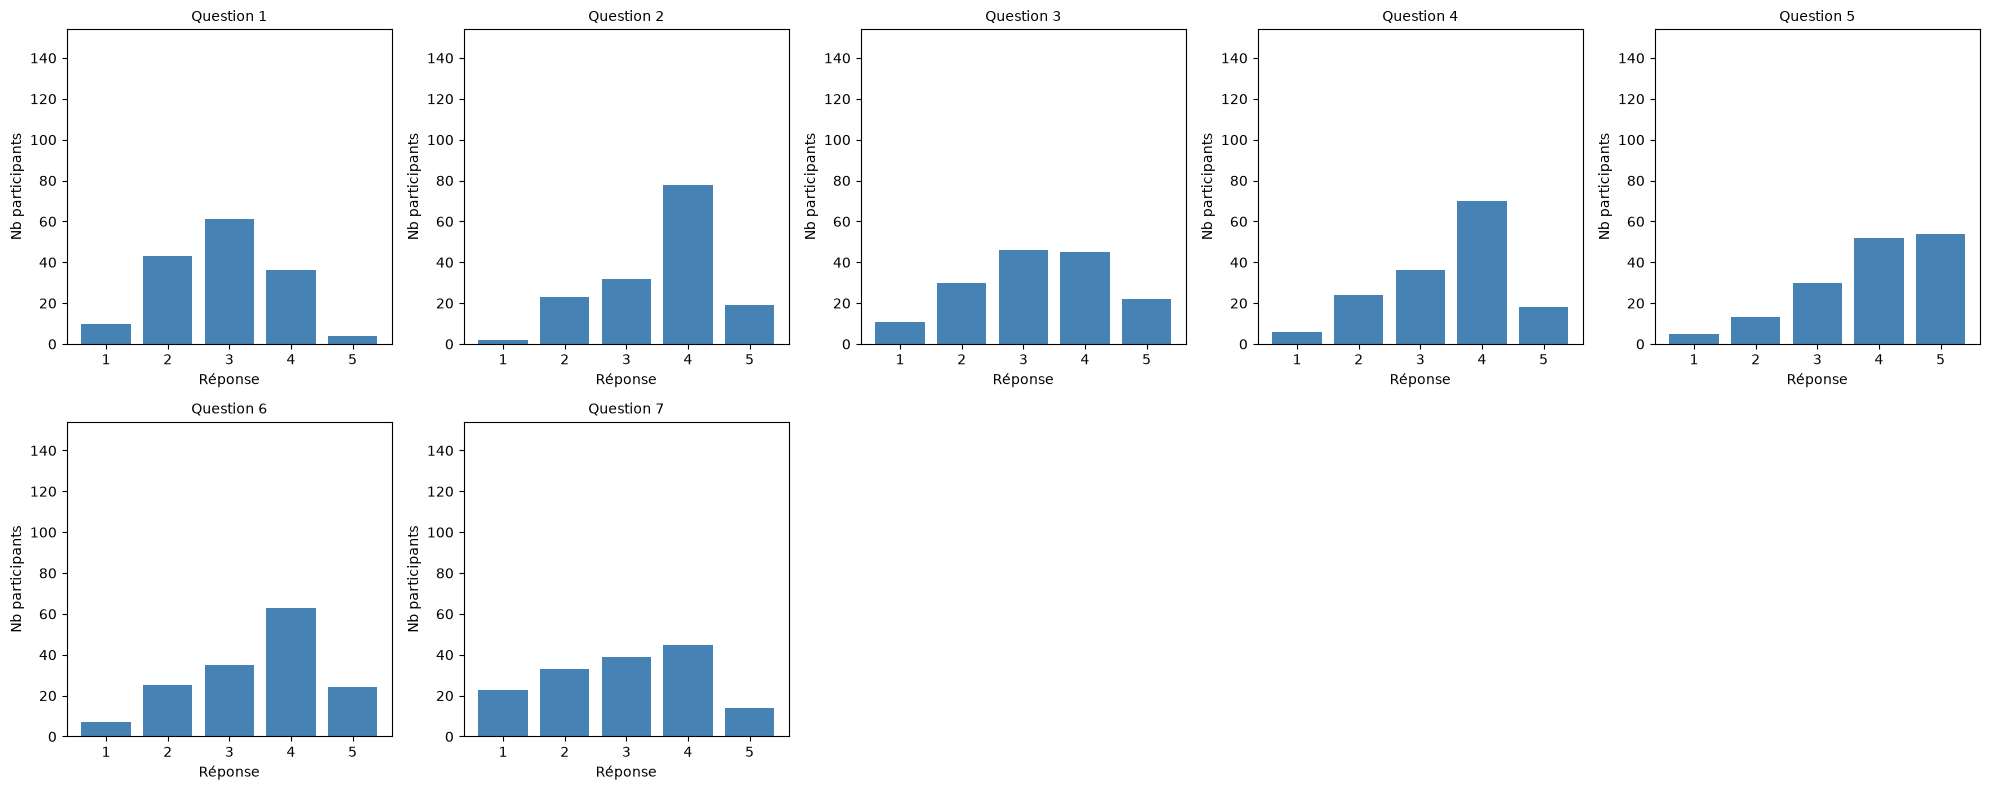

Question : [1- J'ai une grande confiance en l'avenir]
[1- J'ai une grande confiance en l'avenir]
3.0    61
2.0    43
4.0    36
1.0    10
5.0     4
Name: count, dtype: int64


Question : [2- Je suis satisfait(e) de ma vie]
[2- Je suis satisfait(e) de ma vie]
4.0    78
3.0    32
2.0    23
5.0    19
1.0     2
Name: count, dtype: int64


Question : [3- Je regarde l'avenir avec espoir et enthousiasme]
[3- Je regarde l'avenir avec espoir et enthousiasme]
3.0    46
4.0    45
2.0    30
5.0    22
1.0    11
Name: count, dtype: int64


Question : [4- Dans l’ensemble, je suis satisfait(e) de moi]
[4- Dans l’ensemble, je suis satisfait(e) de moi]
4.0    70
3.0    36
2.0    24
5.0    18
1.0     6
Name: count, dtype: int64


Question : [5- Par moment, l’avenir me semble incertain]
[5- Par moment, l’avenir me semble incertain]
5.0    54
4.0    52
3.0    30
2.0    13
1.0     5
Name: count, dtype: int64


Question : [6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]
[6- J'ai le sen

In [119]:

# rien n'est vide, on peut donc continuer avec le traitement 

items = df_EP.columns.tolist()
df_EP[items] = df_EP[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(1, 6))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_EP[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
for i in items:
    print(f"Question : {i}")
    print(df_EP[i].value_counts())
    print("\n")

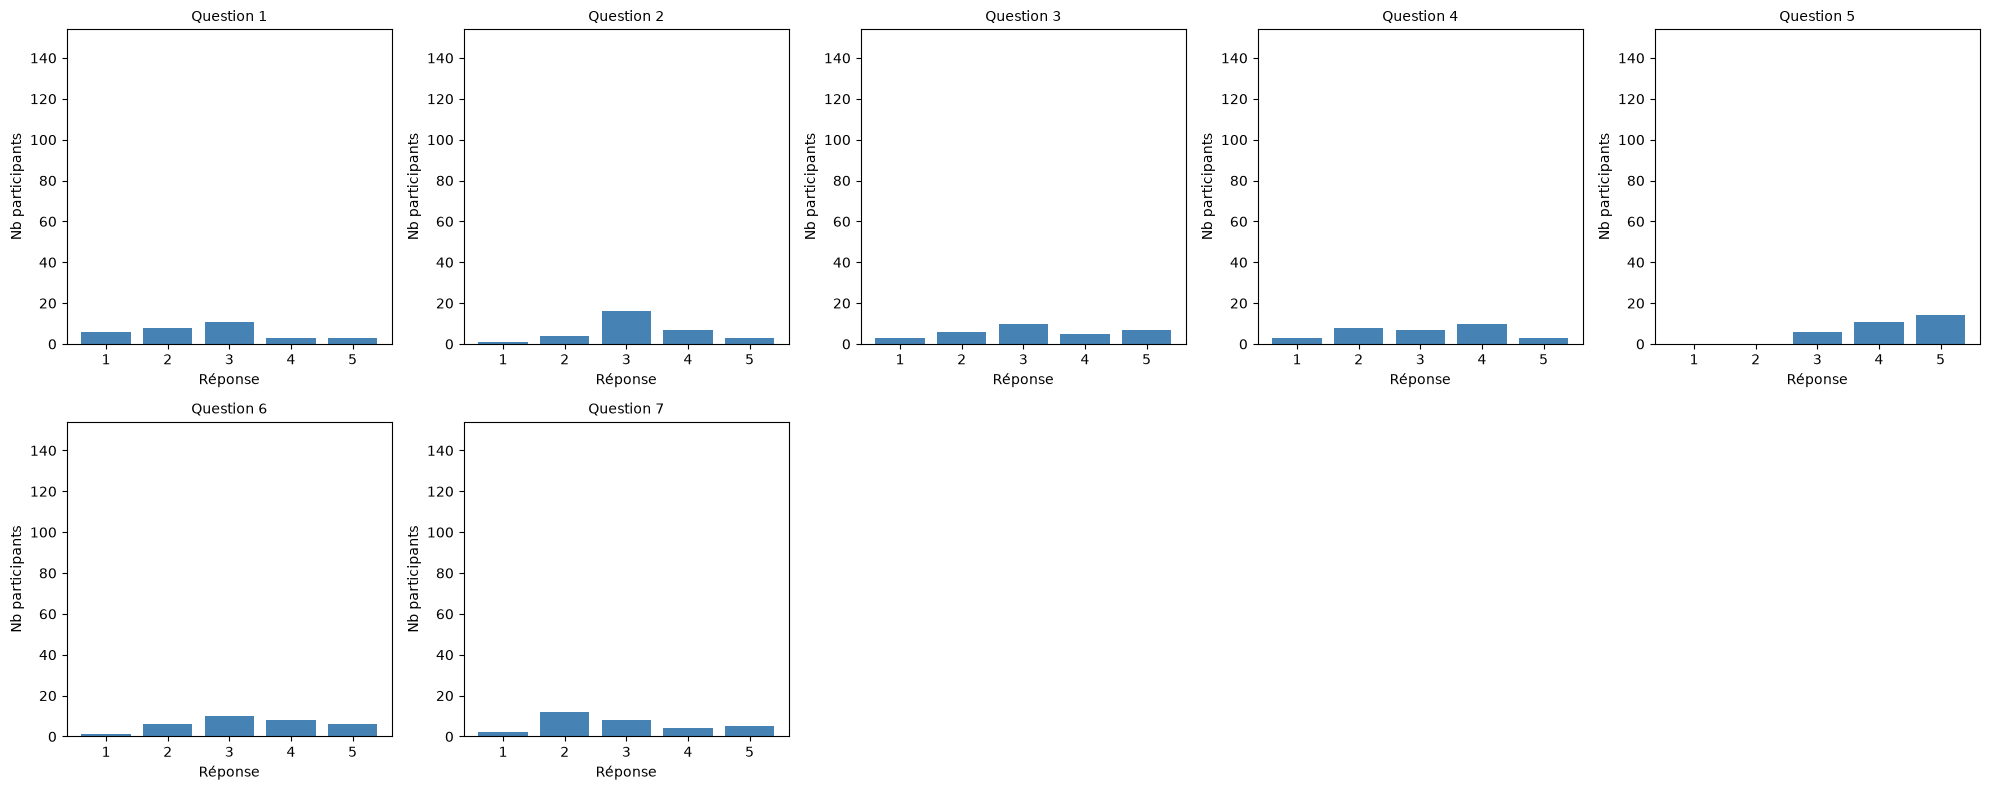

Question : [1- J'ai une grande confiance en l'avenir]
[1- J'ai une grande confiance en l'avenir]
3.0    11
2.0     8
1.0     6
5.0     3
4.0     3
Name: count, dtype: int64


Question : [2- Je suis satisfait(e) de ma vie]
[2- Je suis satisfait(e) de ma vie]
3.0    16
4.0     7
2.0     4
5.0     3
1.0     1
Name: count, dtype: int64


Question : [3- Je regarde l'avenir avec espoir et enthousiasme]
[3- Je regarde l'avenir avec espoir et enthousiasme]
3.0    10
5.0     7
2.0     6
4.0     5
1.0     3
Name: count, dtype: int64


Question : [4- Dans l’ensemble, je suis satisfait(e) de moi]
[4- Dans l’ensemble, je suis satisfait(e) de moi]
4.0    10
2.0     8
3.0     7
5.0     3
1.0     3
Name: count, dtype: int64


Question : [5- Par moment, l’avenir me semble incertain]
[5- Par moment, l’avenir me semble incertain]
5.0    14
4.0    11
3.0     6
Name: count, dtype: int64


Question : [6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]
[6- J'ai le sentiment d'avoir beauc

In [120]:
# rien n'est vide, on peut donc continuer avec le traitement 

items = df_EP_PD.columns.tolist()
df_EP_PD[items] = df_EP_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(1, 6))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_EP_PD[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
for i in items:
    print(f"Question : {i}")
    print(df_EP_PD[i].value_counts())
    print("\n")

In [121]:
df_EP_PD.describe()

,[1- J'ai une grande confiance en l'avenir],[2- Je suis satisfait(e) de ma vie],[3- Je regarde l'avenir avec espoir et enthousiasme],"[4- Dans l’ensemble, je suis satisfait(e) de moi]","[5- Par moment, l’avenir me semble incertain]",[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier],"[7- En général, j’ai confiance en moi]"
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2.645161,3.225806,3.225806,3.064516,4.258065,3.387097,2.935484
std,1.198565,0.920495,1.283476,1.181397,0.773207,1.115868,1.209283
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000
25%,2.000000,3.000000,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
75%,3.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [122]:
df_EP['score_total'] = df_EP.sum(axis=1)
df_EP_PD['score_total'] = df_EP_PD.sum(axis=1)

# Extraction df fPQ-16

In [123]:
cols_16 = df_PS.columns[94:126]  # 16 items (dichotomique : échelle 1: vrai ou faux et échelle 2 si vrai à quel point ou alors faux --> non concerné
cols_16_PD = df_PD.columns[94:126]
print(cols_16)

Index(['[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1]',
       '[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]',
       '[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1]',
       '[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]',
       '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1]',
       '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]',
       '[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]',
       '[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2

In [124]:
df_16 = df_PS[cols_16]
df_16_PD = df_PD[cols_16_PD]

In [125]:
df_16.describe()
df_16_PD.describe()

,[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1],[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2],[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1],[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2],[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1],[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2],"[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]","[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2]",[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 1],[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 2],...,[12- Parfois je me sens soudainement distrait par des sons éloignés dont je ne suis habituellement pas conscient.][Échelle 1],[12- Parfois je me sens soudainement distrait par des sons éloignés dont je ne suis habituellement pas conscient.][Échelle 2],[13- J'ai entendu des choses que les autres ne peuvent pas entendre comme des voix de personnes qui chuchotent où qui parlent.][Échelle 1],[13- J'ai entendu des choses que les autres ne peuvent pas entendre comme des voix de personnes qui chuchotent où qui parlent.][Échelle 2],[14- J'ai souvent l'impression que les autres sont contre moi.][Échelle 1],[14- J'ai souvent l'impression que les autres sont contre moi.][Échelle 2],[15- J'ai eu le sentiment que des personnes ou des forces m'entourent bien que je ne puisse voir personne.][Échelle 1],[15- J'ai eu le sentiment que des personnes ou des forces m'entourent bien que je ne puisse voir personne.][Échelle 2],[16- J'ai l'impression que des parties de mon corps ont changé d'une certaine manière ou que certaines parties de mon corps fonctionnent différemment d'avant.][Échelle 1],[16- J'ai l'impression que des parties de mon corps ont changé d'une certaine manière ou que certaines parties de mon corps fonctionnent différemment d'avant.][Échelle 2]
count,31,31,31,31,31,31,31,31,31,31,...,31,31,31,31,31,31,31,31,31,31
unique,2,5,2,5,2,5,2,5,2,5,...,2,4,2,5,2,4,2,5,2,5
top,FAUX,Non concerné(e),VRAI,Non concerné(e),VRAI,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e),...,FAUX,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e)
freq,20,18,18,12,16,14,17,14,17,15,...,20,19,27,24,21,19,27,24,24,24


# Score de symptomes positifs (0-16)

In [126]:
# Séparer les colonnes "vrai/faux" (échelle 1) et "intensité" (échelle 2)
echelle1 = cols_16[0::2]  # une colonne sur deux, en partant de la 1ère
echelle2 = cols_16[1::2]  # une colonne sur deux, en partant de la 2ème

print("Échelle 1 (vrai/faux) :", list(echelle1))
print("Échelle 2 (intensité) :", list(echelle2))

Échelle 1 (vrai/faux) : ["[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1]", "[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1]", '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1]', "[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]", '[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 1]', "[6- Quand je regarde quelqu'un ou que je me regarde dans le miroir j'ai vu ce visage se modifier juste sous mes yeux.][Échelle 1]", '[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1]', "[8- J'ai déjà vu des choses qu'apparemment d'autres personnes ne peuvent pas voir.][Échelle 1]", '[9- Mes pensées sont parfois tellement fortes que je peux pres

In [127]:
df_16["nb_vrai"] = (df_16[echelle1] == "VRAI").sum(axis=1)
df_16_PD["nb_vrai"] = (df_16_PD[echelle1] == "VRAI").sum(axis=1)
print(df_16["nb_vrai"].describe())

count    154.000000
mean       4.402597
std        3.175724
min        0.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       14.000000
Name: nb_vrai, dtype: float64


au maximum on a 14/16 vrai 

In [128]:
print(df_16["nb_vrai"].value_counts().sort_index())

nb_vrai
0     19
1      8
2     23
3     19
4     18
5     14
6     12
7     17
8      8
9      5
10     3
11     4
12     2
13     1
14     1
Name: count, dtype: int64


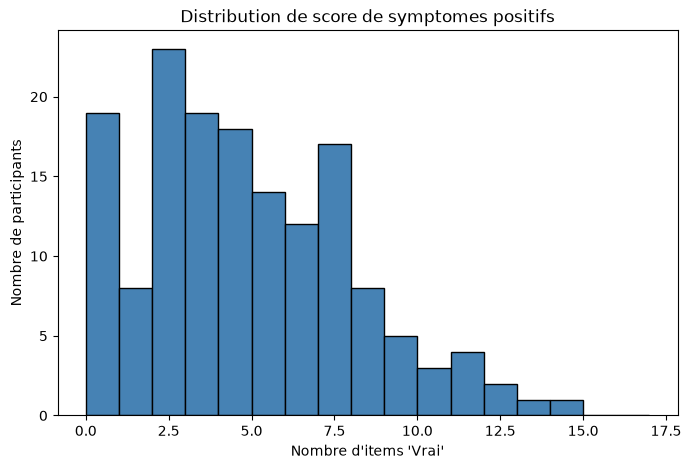

In [129]:
plt.figure(figsize=(8, 5))
plt.hist(df_16["nb_vrai"], bins=range(0, 18), color="steelblue", edgecolor="black")
plt.xlabel("Nombre d'items 'Vrai'")
plt.ylabel("Nombre de participants")
plt.title("Distribution de score de symptomes positifs")
plt.show()

In [130]:
groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9]

print(len(groupe_score_sup_9))

11


11 paritcipants ont un score au dessus du seuil (9)

In [131]:
print(groupe_score_sup_9["nb_vrai"].describe())



count    11.000000
mean     11.363636
std       1.286291
min      10.000000
25%      10.500000
50%      11.000000
75%      12.000000
max      14.000000
Name: nb_vrai, dtype: float64


In [132]:
# vérification du nombre de valeurs numériques valides par colonne, pour ce groupe uniquement
df_16_num_groupe = groupe_score_sup_9[echelle2].apply(pd.to_numeric, errors="coerce")
print(df_16_num_groupe.notna().sum())
# score total (échelle2) pour ce groupe
groupe_score_sup_9["score_total"] = df_16_num_groupe.sum(axis=1, skipna=True)
print(groupe_score_sup_9["score_total"].value_counts().sort_index())

[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]                                                                                                 7
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]                                                            9
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]                                                                                            7
[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2]                                 8
[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 2]                                                                           10
[6- Quand je regarde quelqu'un ou que je me regarde dans le miroi

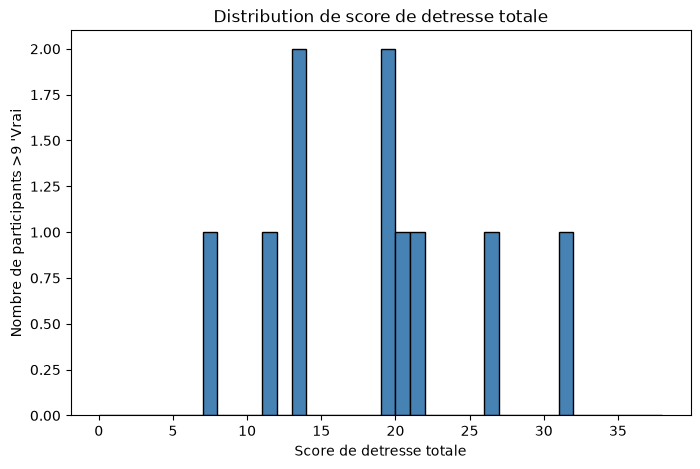

In [133]:

plt.figure(figsize=(8, 5))
plt.hist(groupe_score_sup_9["score_total"], bins=range(0, 39), color="steelblue", edgecolor="black")
plt.xlabel("Score de detresse totale")
plt.ylabel("Nombre de participants >9 'Vrai")
plt.title("Distribution de score de detresse totale")
plt.show()

In [134]:
items = list(echelle2)  # uniquement les 16 colonnes d'intensité, pas les 32
df_16[items] = df_16[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

for i in items:
    print(f"Question : {i}")
    print(groupe_score_sup_9[i].value_counts())
    print("\n")

Question : [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
Non concerné(e)    4
2                  3
1                  3
3                  1
Name: count, dtype: int64


Question : [2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
1                  4
2                  4
Non concerné(e)    2
3                  1
Name: count, dtype: int64


Question : [3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
Non concerné(e)    4
2                  3
3                  2
1                  1
0                  1
Name: count, dtype: 

# Score DE DETRESSE tot= intensité des symptomes uniquement chez les personnes qui ont repondu vrai

In [ ]:
# Convertir chaque valeur en numérique ; le texte non convertible = non concerné devient NaN

df_16_num = df_16[echelle2].apply(pd.to_numeric, errors="coerce")
df_16_PD_num = df_16_PD[echelle2].apply(pd.to_numeric, errors="coerce")

# Vérification : combien de valeurs numériques valides as-tu gardées par colonne ?
print(df_16_num.notna().sum())

[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]                                                                                                44
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]                                                           73
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]                                                                                           66
[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2]                                51
[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 2]                                                                           46
[6- Quand je regarde quelqu'un ou que je me regarde dans le miroi

In [136]:
# Score total : la somme ignore automatiquement les NaN
df_16["score_total"] = df_16_num.sum(axis=1, skipna=True)
df_16_PD["score_total"] = df_16_PD_num.sum(axis=1, skipna=True)
print(df_16["score_total"].describe())

count    154.000000
mean       6.012987
std        6.280988
min        0.000000
25%        2.000000
50%        4.000000
75%        9.000000
max       39.000000
Name: score_total, dtype: float64


In [137]:
print(df_16["score_total"].value_counts().sort_index())

score_total
0.0     25
1.0     13
2.0     22
3.0     11
4.0      7
5.0      7
6.0     12
7.0      9
8.0      6
9.0      7
10.0     7
11.0     4
12.0     3
13.0     6
14.0     3
15.0     1
16.0     3
19.0     3
20.0     1
21.0     1
26.0     1
31.0     1
39.0     1
Name: count, dtype: int64


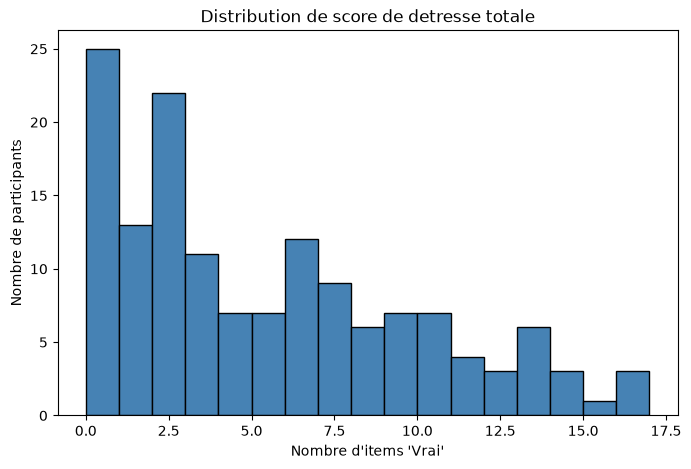

In [138]:

plt.figure(figsize=(8, 5))
plt.hist(df_16["score_total"], bins=range(0, 18), color="steelblue", edgecolor="black")
plt.xlabel("Nombre d'items 'Vrai'")
plt.ylabel("Nombre de participants")
plt.title("Distribution de score de detresse totale")
plt.show()


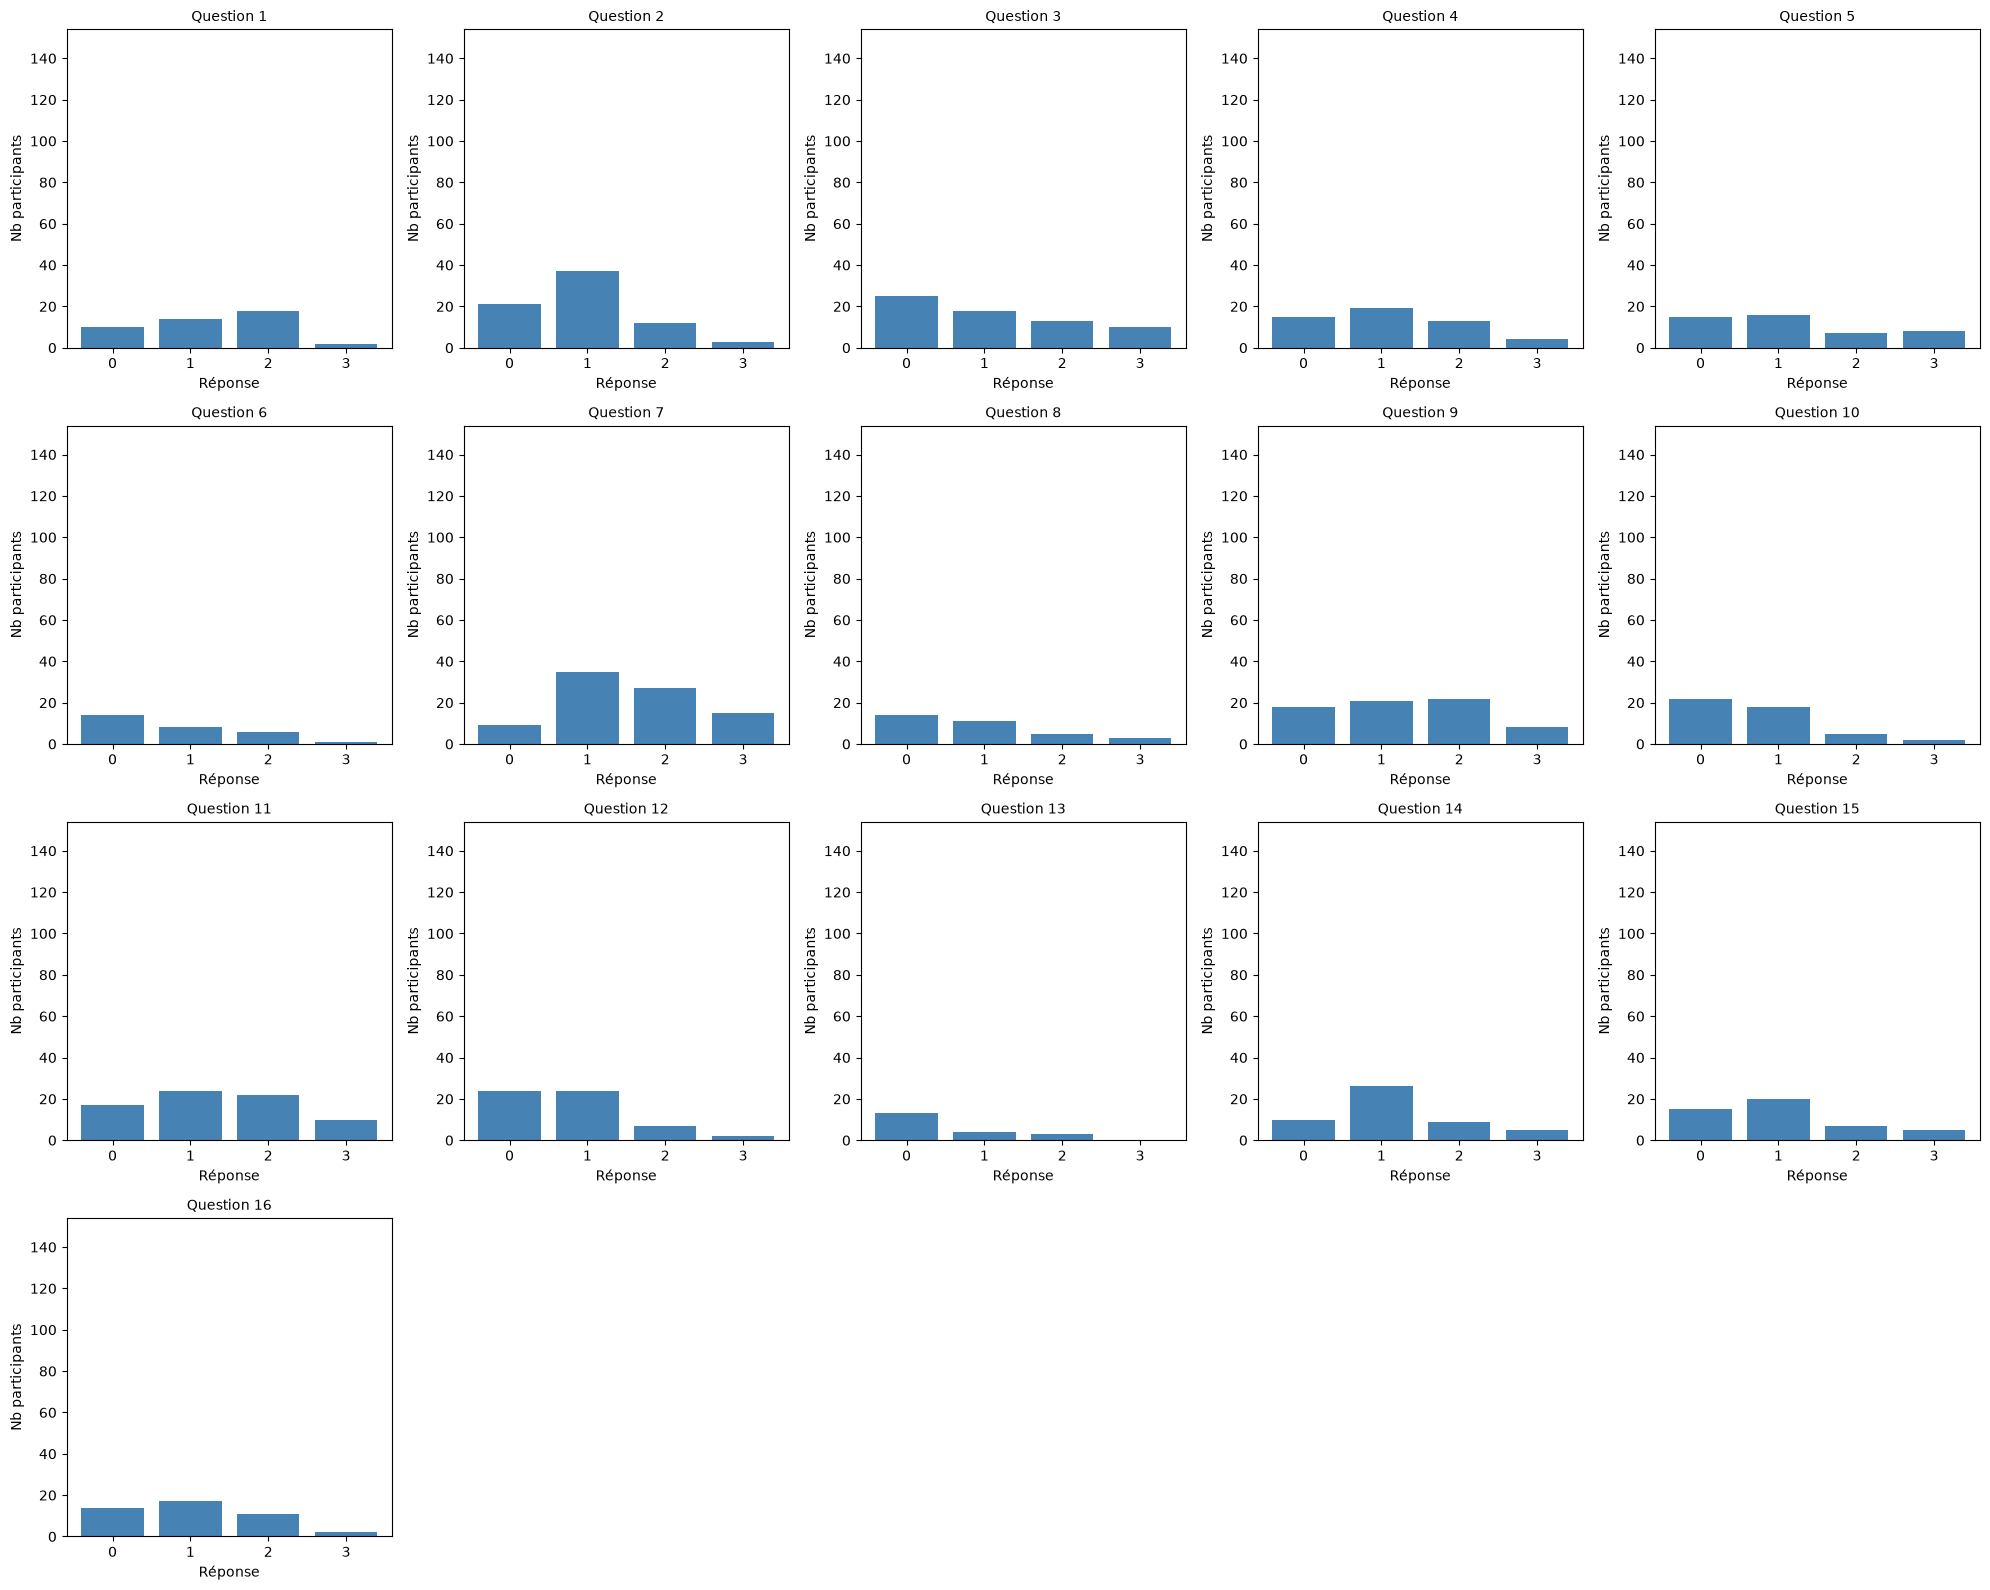

Question : [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
2.0    18
1.0    14
0.0    10
3.0     2
Name: count, dtype: int64


Question : [2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
1.0    37
0.0    21
2.0    12
3.0     3
Name: count, dtype: int64


Question : [3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
0.0    25
1.0    18
2.0    13
3.0    10
Name: count, dtype: int64


Question : [4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes ore

In [139]:
items = list(echelle2)  # uniquement les 16 colonnes d'intensité, pas les 32
df_16[items] = df_16[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 4))  # ⚠️ à vérifier : voir remarque ci-dessous

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_16[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

for i in items:
    print(f"Question : {i}")
    print(df_16[i].value_counts())
    print("\n")

# correlation score TSQ core sz et BAI

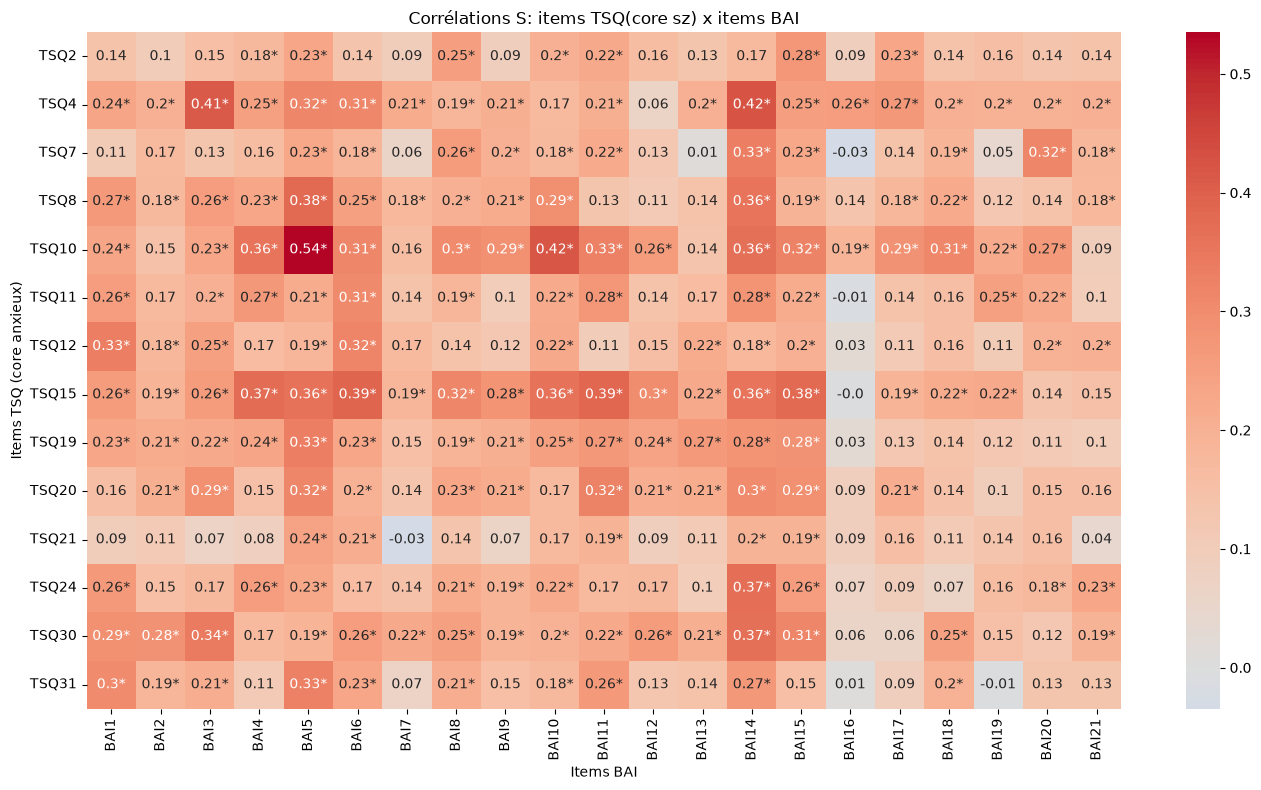

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15',
                  'TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31']

cols_bai_brutes = df_BAI.columns[0:21]

df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df[items_core_sz], df_BAI[items_bai]], axis=1)

# matrice de corrélation complète (TSQ + BAI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes BAI
corr_matrix = corr_matrix_full.loc[items_core_sz, items_bai]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_core_sz, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_sz, columns=items_bai, dtype=float)

for i in items_core_sz:
    for u in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(core sz) x items BAI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

In [141]:
import numpy as np

# transformer la matrice croisée en liste de paires (item_TSQ, item_BAI, corrélation)
strong_corr = corr_matrix.stack().reset_index()
strong_corr.columns = ['item_TSQ', 'item_BAI', 'correlation']

# filtrer les corrélations fortes (positives > 0.6)
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

Empty DataFrame
Columns: [item_TSQ, item_BAI, correlation]
Index: []


# participants avec des scores élevés à la BAI ont un profil TSQ type « Anxieux"??

# correlation pour TSQ total - echelle de positivité ?

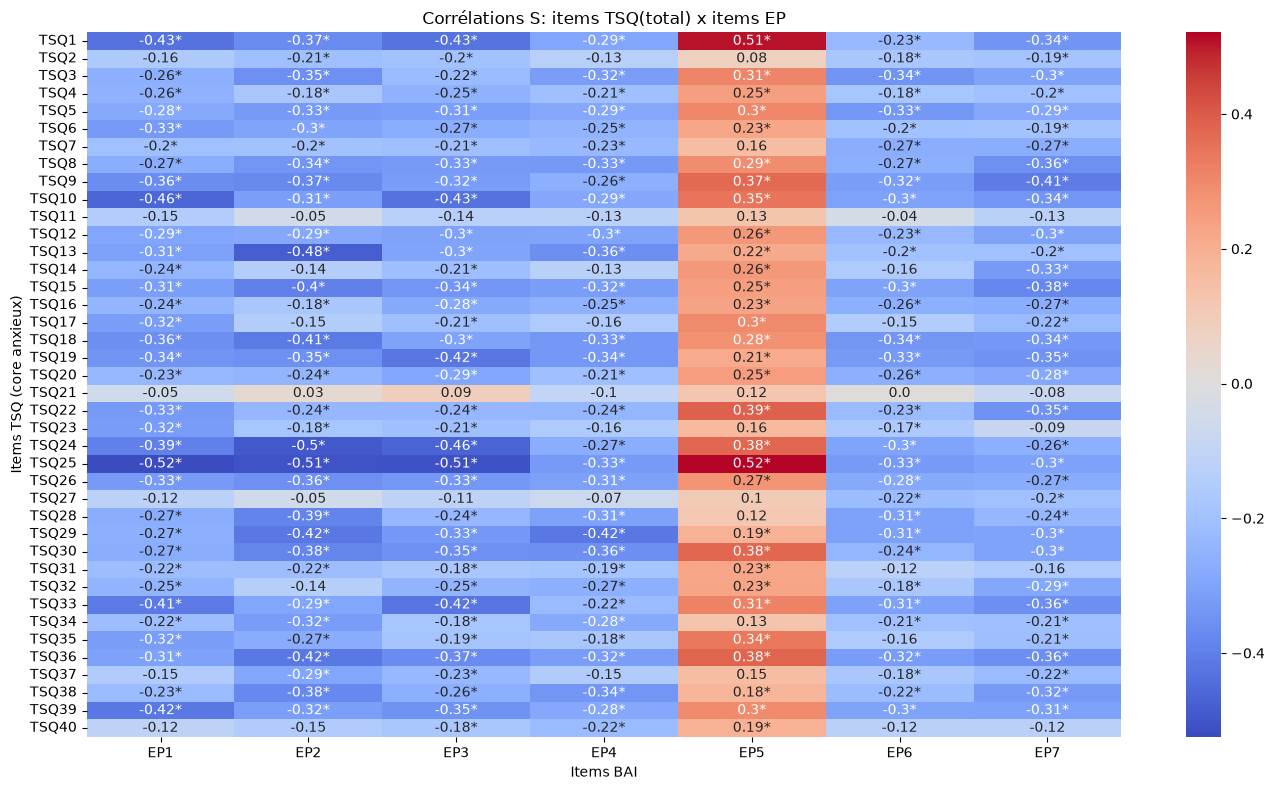

In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))


items = [f"TSQ{i}" for i in range(1, 41)]


cols_ep_brutes = df_EP.columns[0:7]

df_EP = df_EP.rename(columns=dict(zip(cols_ep_brutes, [f"EP{i}" for i in range(1, 8)])))
items_ep = [f"EP{i}" for i in range(1, 8)]
df_EP[items_ep] = df_EP[items_ep].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_EP
concat_items = pd.concat([df[items], df_EP[items_ep]], axis=1)

# matrice de corrélation complète (TSQ + EP ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes EP
corr_matrix = corr_matrix_full.loc[items, items_ep]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items, columns=items_ep, dtype=float)
pval_matrix = pd.DataFrame(index=items, columns=items_ep, dtype=float)

for i in items:
    for u in items_ep:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(total) x items EP")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()



TSQ1 (core ax) =  Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas 
avoir de vision claire dessus. 
TSQ 25 (core MDD, periph ax)= L’avenir s’annonce plutôt difficile ces derniers temps. C'est comme si je me noyais dans 
les inquiétudes et les peurs, ou parfois j'ai simplement l'impression que le futur n'existe pas, 
comme s'il n'avait pas d'importance. Il est difficile de trouver un sens ou d'établir un lien 
personnel avec ce futur. 

EP5 = [5- Par moment, l’avenir me semble incertain]

# plus TSQ Total est élevé, moins j’ai de positivité??

# correlation TSQ core sz vs f-PQ16? 

In [143]:
groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9]
print(len(groupe_score_sup_9))

idx_9 = groupe_score_sup_9.index
print(idx_9)  # les positions/labels des 11 participants concernés

11
Index([46, 60, 72, 88, 147, 160, 201, 217, 260, 289, 294], dtype='int64')


In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_TSQ = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15',
                  'TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31']


# 1. on repère les 11 participants du groupe (score_total échelle 16 déjà calculé)
groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9].copy()
print(len(groupe_score_sup_9))  # doit afficher 11

# 3. on extrait ces mêmes 11 participants dans df_TSQ, uniquement les items core_sz
df_TSQ_9 = df_TSQ.loc[groupe_score_sup_9.index, items_core_sz].copy()
print(df_TSQ_9.shape)  # doit afficher (11, 14)

# 4. on assemble items core_sz + score_total (alignés via l'index)
df_final = df_TSQ_9.copy()
df_final["score_total_16"] = groupe_score_sup_9["score_total"]

# 5. corrélation de Spearman
corr_9 = df_final.corr(method="spearman")
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as patches

# --- calcul r et p pour chaque item vs score_total ---
resultats = []
for item in items_core_sz:
    paired = df_final[[item, "score_total_16"]].dropna()
    r, p = spearmanr(paired[item], paired["score_total_16"])
    resultats.append({"item": item, "r": r, "p": p})

df_stats = pd.DataFrame(resultats).set_index("item")

# --- correction FDR (Benjamini-Hochberg) ---
rejected, p_corrected, _, _ = multipletests(df_stats["p"], alpha=0.05, method="fdr_bh")
df_stats["p_corrected"] = p_corrected
df_stats["significatif"] = rejected

print(df_stats)

11
(11, 14)
              r         p  p_corrected  significatif
item                                                
TSQ2   0.065746  0.847699     0.946869         False
TSQ4   0.257140  0.445270     0.946869         False
TSQ7   0.342703  0.302211     0.946869         False
TSQ8   0.116972  0.731966     0.946869         False
TSQ10 -0.105625  0.757256     0.946869         False
TSQ11 -0.425733  0.191719     0.946869         False
TSQ12  0.052034  0.879236     0.946869         False
TSQ15  0.011521  0.973181     0.973181         False
TSQ19 -0.174713  0.607389     0.946869         False
TSQ20  0.230382  0.495539     0.946869         False
TSQ21 -0.408041  0.212835     0.946869         False
TSQ24 -0.055558  0.871114     0.946869         False
TSQ30  0.124447  0.715435     0.946869         False
TSQ31  0.285778  0.394274     0.946869         False


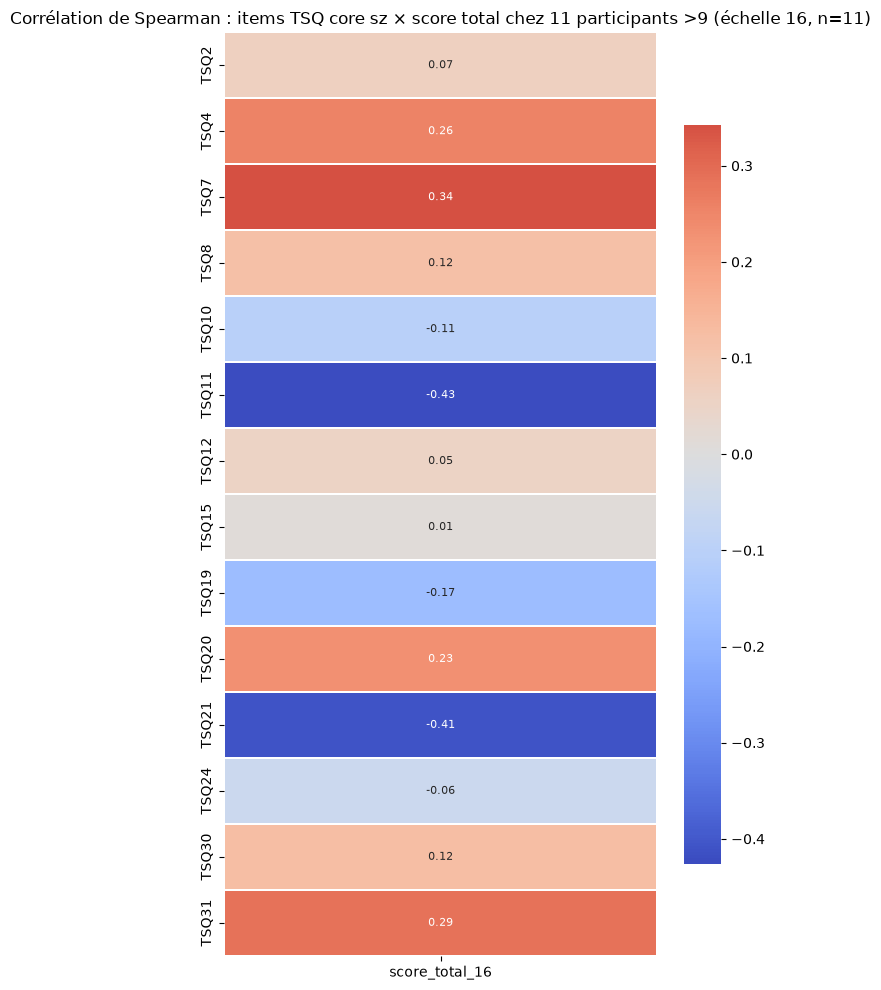

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_9[["score_total_16"]].drop("score_total_16", errors="ignore"),  # enlève la ligne redondante si présente
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="coolwarm", center=0,
    linewidths=0.3, cbar_kws={"shrink": 0.8}
)
plt.title("Corrélation de Spearman : items TSQ core sz × score total chez 11 participants >9 (échelle 16, n=11)")
plt.tight_layout()
plt.show()



TSQ4 = Parfois, certaines parties de mon corps me semblent étranges, comme si elles ne 
m'appartenaient pas ou avaient été déconnectées les unes des autres, ou même comme si elles 
n'existaient pas du tout. 
TSQ7 = Même dans des endroits que je connais bien, je me sens parfois complètement perdu(e) ou 
désorienté(e), n'étant pas certain(e) de comment avancer ou reculer. C'est comme si j'étais 
constamment désorienté(e) et confus(e). 
TSQ31 = J'ai eu l'impression que tout, autour de moi, était trop éloigné. C'est comme si l'espace et 
les choses physiques semblaient très éloignés et un peu futiles. C'est comme si tout s'étendait à 
l'infini et n'avait vraiment aucun sens. 

TSQ11 =  Parfois, je remarque que certaines parties de mon corps me paraissent comme rapetissées 
ou tendues, ou j'ai la sensation que mon corps tout entier se contracte ou s'étend, comme s'il 
était en train d'être pressé ou comprimé. 
TSQ21=  Il y a des moments où je ne peux pas vraiment dire où mon corps s'arrête et où tout le 
reste commence. C'est comme si les choses autour de moi semblaient faire partie de moi ou 
être collées à moi d'une manière ou d'une autre. Et puis il y a des moments où des choses 
semblent, depuis l'extérieur, faire directement irruption dans ma tête et dans mon corps, 
perturbant mon corps et mon esprit.

# correl TSQ periph sz vs fPQ16? 

In [260]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_TSQ = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))

items_periph_sz = ['TSQ1','TSQ3','TSQ5','TSQ6','TSQ13','TSQ14','TSQ23','TSQ27']


# 1. on repère les 11 participants du groupe (score_total échelle 16 déjà calculé)
groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9].copy()
print(len(groupe_score_sup_9))  # doit afficher 11

# 3. on extrait ces mêmes 11 participants dans df_TSQ, uniquement les items core_sz
df_TSQ_9 = df_TSQ.loc[groupe_score_sup_9.index, items_periph_sz].copy()
print(df_TSQ_9.shape)  # doit afficher (11, 14)

# 4. on assemble items core_sz + score_total (alignés via l'index)
df_final = df_TSQ_9.copy()
df_final["score_total_16"] = groupe_score_sup_9["score_total"]

# 5. corrélation de Spearman
corr_9 = df_final.corr(method="spearman")

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as patches

# --- calcul r et p pour chaque item vs score_total ---
resultats = []
for item in items_periph_sz:
    paired = df_final[[item, "score_total_16"]].dropna()
    r, p = spearmanr(paired[item], paired["score_total_16"])
    resultats.append({"item": item, "r": r, "p": p})

df_stats = pd.DataFrame(resultats).set_index("item")

# --- correction FDR (Benjamini-Hochberg) ---
rejected, p_corrected, _, _ = multipletests(df_stats["p"], alpha=0.05, method="fdr_bh")
df_stats["p_corrected"] = p_corrected
df_stats["significatif"] = rejected

print(df_stats)

11
(11, 8)
              r         p  p_corrected  significatif
item                                                
TSQ1  -0.286381  0.393232     0.859807         False
TSQ3   0.197702  0.560092     0.896147         False
TSQ5  -0.036952  0.914104     0.914104         False
TSQ6   0.265595  0.429903     0.859807         False
TSQ13  0.122099  0.720616     0.914104         False
TSQ14  0.367498  0.266195     0.859807         False
TSQ23  0.339525  0.307010     0.859807         False
TSQ27  0.058053  0.865370     0.914104         False


# participants avec fpQ16 élevés ont des scores plus élevés aux items « core SZ"??

# relation avec prise de sub ou pas - suite du questionnaire fPQI

In [151]:
cols_sub = df_PS.columns[126:131]
print(cols_sub)
# reponses possibles : Sans relation avec une consommation de substances ou En relation avec une consommation de substance et aussi à d'autres moments
# Oui ou N/A
# pareil
# chiffres avec des "et" des espaces ou des "/"
df_sub= df_PS[cols_sub]


Index(['Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :',
       'Avez-vous déjà ressenti des idées noires et/ou suicidaires ?',
       'Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?',
       'Si oui, quels symptômes (donner les propositions correspondantes entre 1 et 16) ?',
       'Pour chacun de ces symptômes, à quel point sont-ils en lien avec vos idées noires et/ou suicidaires selon vous (0=absence de lien 10=lien le plus intense et le plus direct)   Note .../10 :'],
      dtype='str')


In [152]:
print(df_sub["Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :"].value_counts())

Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :
Sans relation avec une consommation de substances                             130
Observés uniquement lors d'une consommation de substances                       1
En relation avec une consommation de substance et aussi à d'autres moments      1
Name: count, dtype: int64


In [153]:
df_merged3 = pd.DataFrame({
    "nb_vrai": df_16["nb_vrai"].values,
    "score_total": df_16["score_total"].values,
    "relation_sub": df_sub["Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :"].values
})
groupe_relation = df_merged3[
    df_merged3["relation_sub"] == "En relation avec une consommation de substance et aussi à d'autres moments"
]

groupe_uniquement = df_merged3[
    df_merged3["relation_sub"] == "Observés uniquement lors d'une consommation de substances"
]

print("--- En relation + autres moments (n =", len(groupe_relation), ") ---")
print(groupe_relation[["nb_vrai", "score_total"]])

print("\n--- Uniquement lors de consommation (n =", len(groupe_uniquement), ") ---")
print(groupe_uniquement[["nb_vrai", "score_total"]])
   

--- En relation + autres moments (n = 1 ) ---
     nb_vrai  score_total
119        6          9.0

--- Uniquement lors de consommation (n = 1 ) ---
    nb_vrai  score_total
83        7          1.0


In [154]:
print(df_sub["Avez-vous déjà ressenti des idées noires et/ou suicidaires ?"].value_counts())

Avez-vous déjà ressenti des idées noires et/ou suicidaires ?
Non    88
Oui    66
Name: count, dtype: int64


In [155]:
df_merged3 = pd.DataFrame({
    "nb_vrai": df_16["nb_vrai"].values,
    "score_total": df_16["score_total"].values,
    "suic": df_sub["Avez-vous déjà ressenti des idées noires et/ou suicidaires ?"].values
})
groupe_idees_noires = df_merged3[
    df_merged3["suic"] == "Oui"
]

print("--- Idées noires/suic (n =", len(groupe_idees_noires), ") ---")
print(groupe_idees_noires[["nb_vrai", "score_total"]])



--- Idées noires/suic (n = 66 ) ---
     nb_vrai  score_total
0          8          9.0
1          1          3.0
3          0          0.0
4          4          4.0
5          3          5.0
..       ...          ...
144       11         26.0
148        5          5.0
150        2          2.0
151        5          5.0
153        2          3.0

[66 rows x 2 columns]


In [156]:
print(df_sub["Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?"].value_counts())

Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?
Non    57
Oui     9
Name: count, dtype: int64


In [157]:
df_merged3 = pd.DataFrame({
    "nb_vrai": df_16["nb_vrai"].values,
    "score_total": df_16["score_total"].values,
    "lien": df_sub["Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?"].values
})
groupe_lien_idees_noires = df_merged3[
    df_merged3["lien"] == "Oui"
]

print("--- lien idées noires/suic (n =", len(groupe_lien_idees_noires), ") ---")
print(groupe_lien_idees_noires[["nb_vrai", "score_total"]])

--- lien idées noires/suic (n = 9 ) ---
     nb_vrai  score_total
6          8         16.0
28         7          6.0
64         9         12.0
78        14         39.0
81         7         11.0
82        13         31.0
89         7         12.0
93         5          6.0
120        3          7.0


In [158]:
col_symptomes = "Si oui, quels symptômes (donner les propositions correspondantes entre 1 et 16) ?"
print(df_sub[col_symptomes].unique())

<StringArray>
[                          nan,                     '7 et 11',
                           '1',                      '1 et 5',
                           '2',                     '9 11 14',
                          '11',                    '14 et 11',
 'Sentiment de pas être aimée']
Length: 9, dtype: str


In [159]:
# print les questions en loccurences 
# print les scores de ces personne sà côté et les questions 

In [160]:
# Mapping numéro (1 à 16) -> texte de la question
mapping_questions = {i+1: col for i, col in enumerate(echelle1)}
print(mapping_questions)

{1: "[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1]", 2: "[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1]", 3: '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1]', 4: "[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]", 5: '[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 1]', 6: "[6- Quand je regarde quelqu'un ou que je me regarde dans le miroir j'ai vu ce visage se modifier juste sous mes yeux.][Échelle 1]", 7: '[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1]', 8: "[8- J'ai déjà vu des choses qu'apparemment d'autres personnes ne peuvent pas voir.][Échelle 1]", 9: '[9- Mes pensées sont parfois tellement fortes que je peux p

In [161]:
import re

def extraire_numeros(texte):
    if pd.isna(texte):
        return []
    return [int(n) for n in re.findall(r"\d+", str(texte))]

# Ajouter la colonne symptômes au DataFrame fusionné, pour le même sous-groupe
df_merged3["symptomes_texte"] = df_sub[col_symptomes].values
df_merged3["symptomes_numeros"] = df_merged3["symptomes_texte"].apply(extraire_numeros)

# Convertir les numéros en texte des questions correspondantes
df_merged3["symptomes_questions"] = df_merged3["symptomes_numeros"].apply(
    lambda liste: [mapping_questions.get(n, f"Numéro {n} inconnu") for n in liste]
)

In [162]:
groupe_sympt = df_merged3[df_merged3["lien"] == "Oui"]

pd.set_option('display.max_colwidth', None)
print(groupe_sympt[["nb_vrai", "score_total", "symptomes_numeros", "symptomes_questions"]])

     nb_vrai  score_total symptomes_numeros  \
6          8         16.0           [7, 11]   
28         7          6.0               [1]   
64         9         12.0            [1, 5]   
78        14         39.0               [2]   
81         7         11.0       [9, 11, 14]   
82        13         31.0              [11]   
89         7         12.0              [11]   
93         5          6.0          [14, 11]   
120        3          7.0                []   

                                                                                                                                                                                                                                                              symptomes_questions  
6                                                                                 [[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1], [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où p

In [163]:
col_note_lien = "Pour chacun de ces symptômes, à quel point sont-ils en lien avec vos idées noires et/ou suicidaires selon vous (0=absence de lien 10=lien le plus intense et le plus direct)   Note .../10 :"

df_merged3["note_lien"] = df_sub[col_note_lien].values

# Vérifier le format des réponses (numérique direct, ou texte à nettoyer ?)
print(df_merged3["note_lien"].unique())

<StringArray>
[nan, '5/10 et 8/10', '5', '1 = 7 et 5 = 8', '8', '7/10', '6', '7', '10']
Length: 9, dtype: str


# Manuellement car je n'y arrive pas

In [164]:
#participant 6         nb vrai= 8         score_total= 16.0        note_lien = nan                                        items concernés= nan
# participant 28       nb vrai  7        score tot  6.0               note_lien = 5/10 pour item 7 et 8/10 pour item 11      items concernés= [7, 11]   -->  [[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1], [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.]
#participant 64        nb vrai= 9         score tot = 12.0          note_lien = 5                                        item concerné = 1                --> [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.
#participant 78        14                    39.0                  note_lien=7/10 et 8/10                              item concerné = 1 et 5            --> [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.  [5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.
#participant 81           7                  11.0                           note_lien= 8                                 = 2                              --> [2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu)
#participant 82        13                    31.0                       note_lien=7                                    = 9,11,14                         --> [9- Mes pensées sont parfois tellement fortes que je peux presque les entendre.][Échelle 1], [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.][Échelle 1], [14- J'ai souvent l'impression que les autres sont contre moi.]
#participant 89         7                    12.0                         note_lien6=                                = 11                                 --> [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.]
#participant 93         5                     6.0                         note_lien=7                                = 14 et 11                            --> [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.][Échelle 1], [14- J'ai souvent l'impression que les autres sont contre moi.]
#participant 120        3                      7.0                        note_lien=10                                = sentiment de pas etre aimé (on ne sait pas quelle question cela correspond)

# Extraction df ZTPI

* 56 items avec cinq sous-dimensions que sont le passé négatif, le passé positif, le présent fataliste, le présent hédoniste, et le futur – 1 (pas du tout caractéristique de moi) à 5 (tout à fait caractéristique de moi)
* 1 (pas du tout caractéristique de moi) à 5 (tout à fait caractéristique de moi).

In [165]:
cols_ZTPI = df_PS.columns[131:187]
cols_ZTPI = [col for i, col in enumerate(cols_ZTPI) if i not in (15, 36)]
print(cols_ZTPI)
df_ZTPI= df_PS[cols_ZTPI]


['[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]', '[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]', '[3- Le destin détermine beaucoup de choses dans ma vie.]', '[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]', '[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.]', '[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.]', '[7- Le fait de penser à mon passé me donne du plaisir.]', '[8- Je fais les choses de manière impulsive.]', '[9- Si les choses ne sont pas faites à temps, je ne m’en préoccupe pas.]', '[10- Quand je dois réaliser quelque chose, je me fixe des buts et j’envisage les moyens précis pour les atteindre.]', '[11- Tout compte fait, il y a beaucoup plus de bonnes choses à se souvenir dans mon passé que de mauvaises.]', '[12- Quand j’écoute ma musiq

In [166]:
df_ZTPI.describe()

,[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ],"[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]",[3- Le destin détermine beaucoup de choses dans ma vie.],[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.],[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.],[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.],[7- Le fait de penser à mon passé me donne du plaisir.],[8- Je fais les choses de manière impulsive.],"[9- Si les choses ne sont pas faites à temps, je ne m’en préoccupe pas.]","[10- Quand je dois réaliser quelque chose, je me fixe des buts et j’envisage les moyens précis pour les atteindre.]",...,"[47- Aujourd’hui, la vie est trop compliquée ; j’aurais préféré la vie simple du passé. ]",[48- Je préfère les amis qui sont spontanés à ceux qui sont prévisibles.],[49- J’aime bien les traditions et les coutumes familiales qui sont régulièrement répétées. ],[50- Je pense aux mauvaises choses qui me sont arrivées dans le passé],[51- Je persiste à travailler à des activités difficiles et sans intérêt si elles m’aident à prendre de l’avance.],[52- Je préfère dépenser ce que je gagne en me faisant plaisir aujourd’hui plutôt que d’épargner pour ma sécurité de demain.],"[53- Souvent, la chance rapporte plus que de travailler dur.]",[54- Je pense aux bonnes choses que j’ai ratées dans ma vie.],[55- J’aime bien que les relations avec mes proches soient passionnées.],[56- Il y aura toujours le temps pour que je rattrape mon travail.]
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,...,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,4.090909,3.785714,2.506494,3.253247,3.097403,2.376623,2.850649,2.642857,1.811688,3.675325,...,2.162338,3.175325,3.402597,2.577922,2.435065,2.584416,2.194805,2.376623,3.480519,2.649351
std,0.959055,1.060055,1.184026,1.306403,1.052662,1.204989,1.083341,1.219014,0.981991,1.113689,...,1.212521,1.085454,1.134829,1.261716,1.142897,1.118480,1.126496,1.252855,1.036717,1.111629
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,3.000000,1.250000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,3.000000,...,1.000000,3.000000,3.000000,2.000000,1.000000,2.000000,1.000000,1.000000,3.000000,2.000000
50%,4.000000,4.000000,2.000000,3.000000,3.000000,2.000000,3.000000,3.000000,1.500000,4.000000,...,2.000000,3.000000,4.000000,2.000000,2.000000,3.000000,2.000000,2.000000,4.000000,3.000000
75%,5.000000,5.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,2.000000,4.000000,...,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.750000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [167]:
df_ZTPI.median()

[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]                                  4.0
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]                            4.0
[3- Le destin détermine beaucoup de choses dans ma vie.]                                                                                     2.0
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]                                                                      3.0
[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.]                                             3.0
[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.]                                                     2.0
[7- Le fait de penser à mon passé me donne du plaisir.]                                                                           

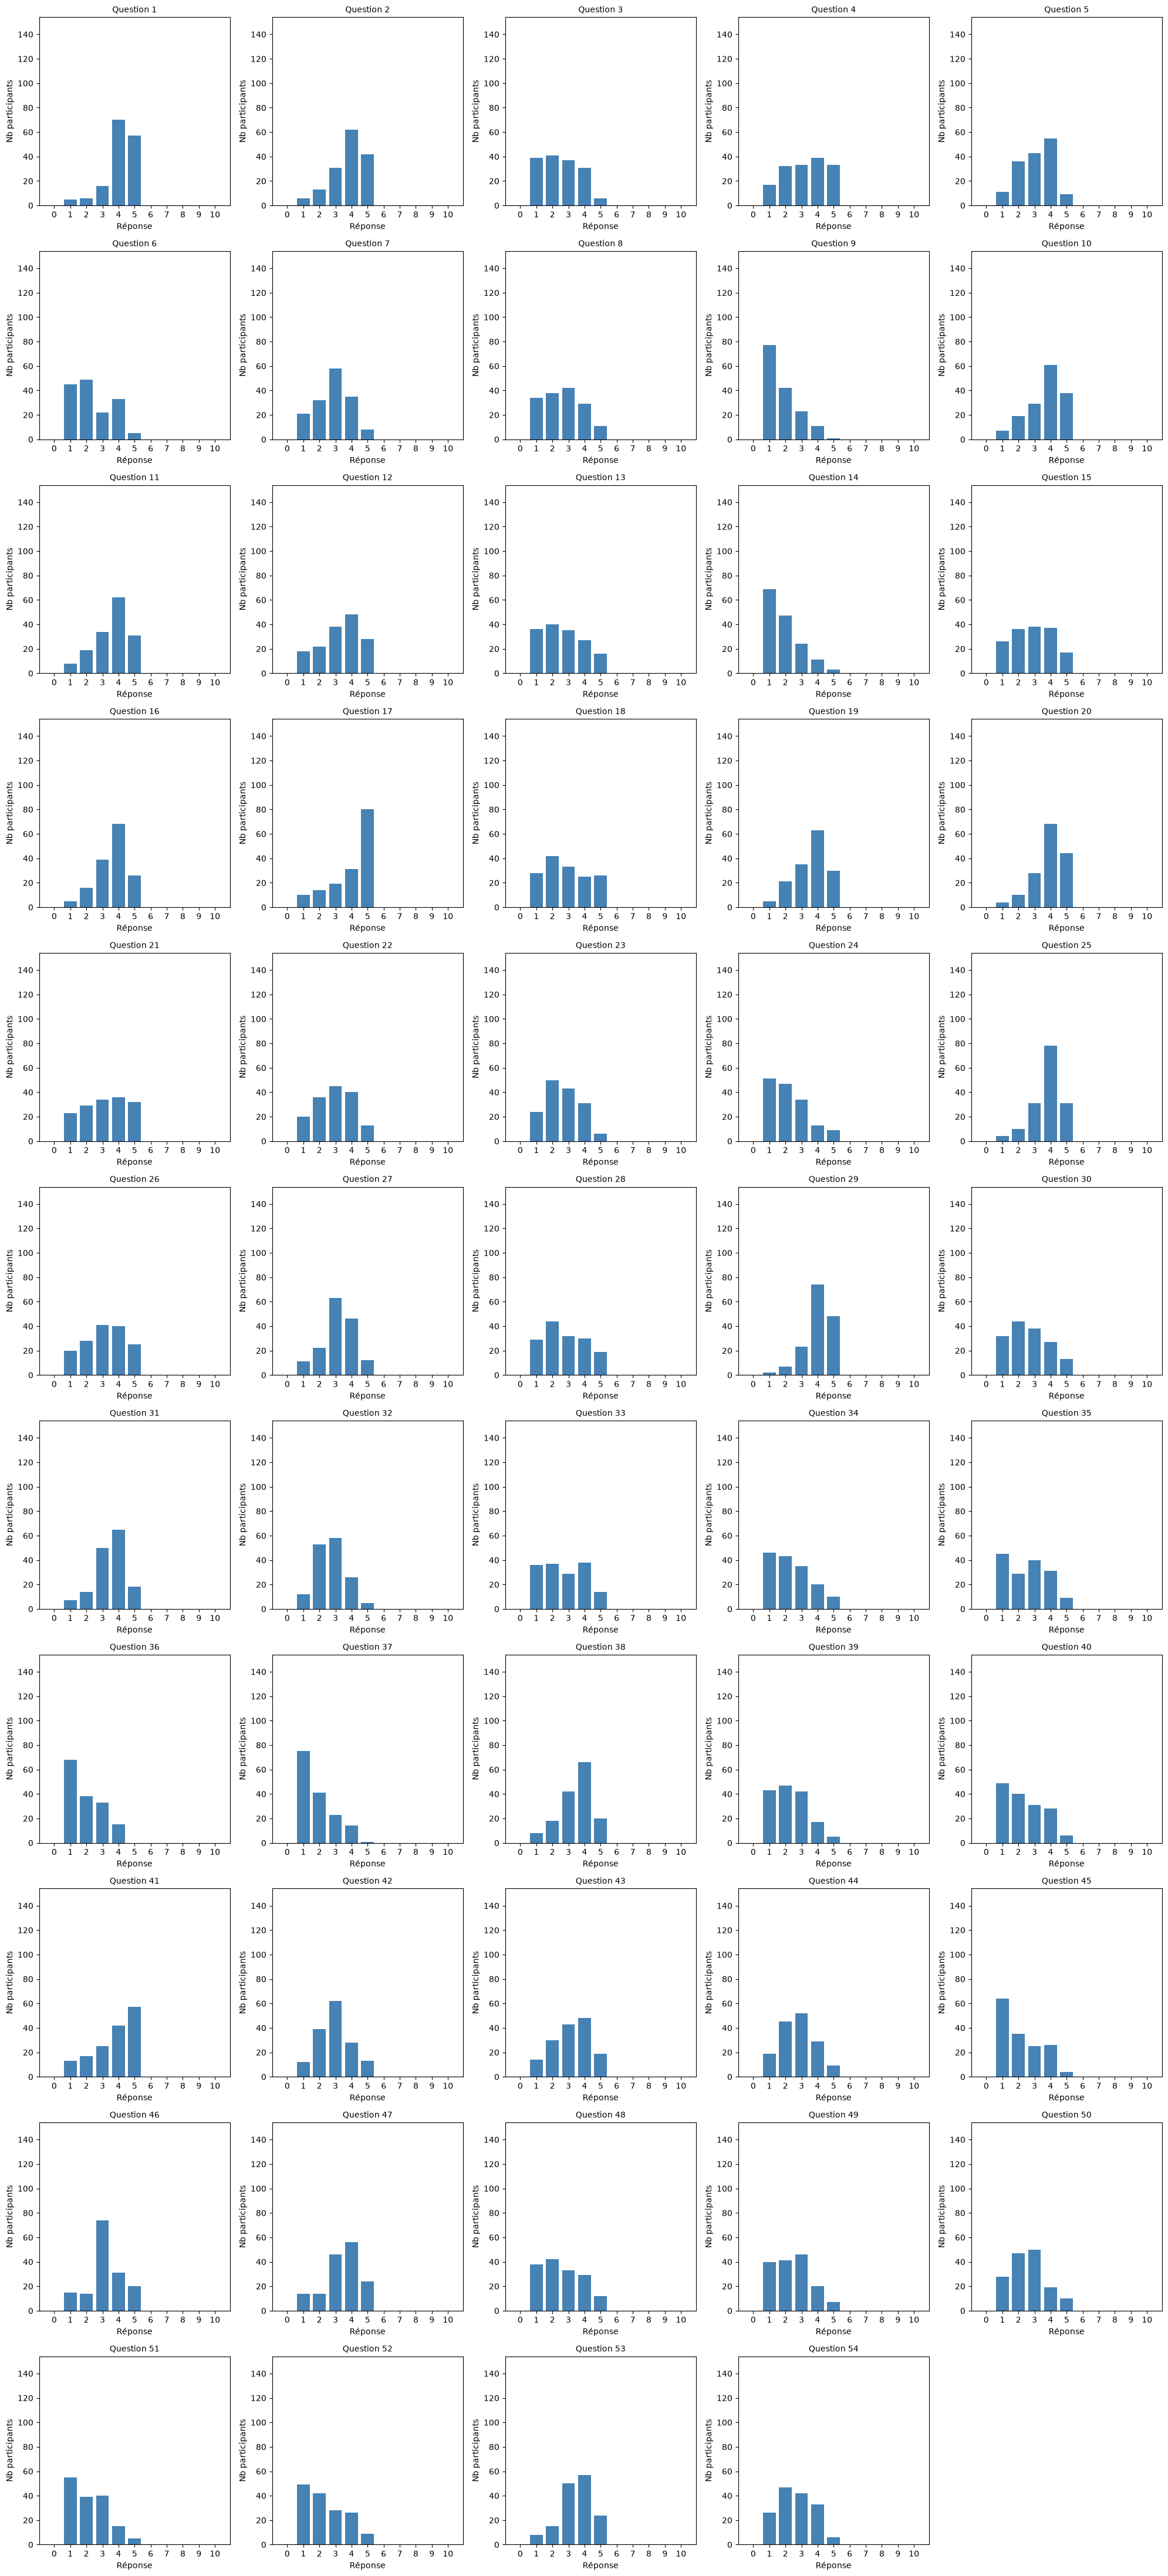

In [168]:
items = df_ZTPI.columns.tolist()
df_ZTPI[items] = df_ZTPI[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_ZTPI[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [169]:

for i in items:
    print(f"Question : {i}")
    print(df_ZTPI[i].value_counts())
    print("\n")

Question : [1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
4.0    70
5.0    57
3.0    16
2.0     6
1.0     5
Name: count, dtype: int64


Question : [2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
4.0    62
5.0    42
3.0    31
2.0    13
1.0     6
Name: count, dtype: int64


Question : [3- Le destin détermine beaucoup de choses dans ma vie.]
[3- Le destin détermine beaucoup de choses dans ma vie.]
2.0    41
1.0    39
3.0    37
4.0    31
5.0     6
Name: count, dtype: int64


Question : [4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
4.0    39
3.0    33


In [170]:
cols_ZTPI_PD= df_PD.columns[131:187]
cols_ZTPI_PD = [col for i, col in enumerate(cols_ZTPI_PD) if i not in (15, 36)]

df_ZTPI_PD= df_PD[cols_ZTPI_PD]


In [171]:
df_ZTPI_PD.describe()

,[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ],"[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]",[3- Le destin détermine beaucoup de choses dans ma vie.],[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.],[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.],[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.],[7- Le fait de penser à mon passé me donne du plaisir.],[8- Je fais les choses de manière impulsive.],"[9- Si les choses ne sont pas faites à temps, je ne m’en préoccupe pas.]","[10- Quand je dois réaliser quelque chose, je me fixe des buts et j’envisage les moyens précis pour les atteindre.]",...,"[47- Aujourd’hui, la vie est trop compliquée ; j’aurais préféré la vie simple du passé. ]",[48- Je préfère les amis qui sont spontanés à ceux qui sont prévisibles.],[49- J’aime bien les traditions et les coutumes familiales qui sont régulièrement répétées. ],[50- Je pense aux mauvaises choses qui me sont arrivées dans le passé],[51- Je persiste à travailler à des activités difficiles et sans intérêt si elles m’aident à prendre de l’avance.],[52- Je préfère dépenser ce que je gagne en me faisant plaisir aujourd’hui plutôt que d’épargner pour ma sécurité de demain.],"[53- Souvent, la chance rapporte plus que de travailler dur.]",[54- Je pense aux bonnes choses que j’ai ratées dans ma vie.],[55- J’aime bien que les relations avec mes proches soient passionnées.],[56- Il y aura toujours le temps pour que je rattrape mon travail.]
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,...,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,4.032258,3.354839,2.483871,3.612903,3.225806,2.322581,2.322581,2.870968,1.709677,3.935484,...,2.451613,3.064516,3.193548,3.419355,2.741935,3.064516,2.612903,2.967742,3.709677,2.548387
std,1.168585,1.305077,1.287659,1.174093,1.359158,1.326326,1.275071,1.335214,0.937854,1.093480,...,1.501970,1.062559,1.536649,1.057487,1.290161,1.209283,1.145351,1.277599,1.070624,1.312471
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.500000,1.000000,3.000000,2.000000,1.000000,1.000000,2.000000,1.000000,3.500000,...,1.000000,3.000000,1.500000,3.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.500000
50%,5.000000,3.000000,3.000000,4.000000,3.000000,2.000000,2.000000,3.000000,1.000000,4.000000,...,2.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,2.000000
75%,5.000000,4.500000,3.500000,4.500000,4.000000,3.000000,3.000000,4.000000,2.000000,5.000000,...,4.000000,3.000000,4.500000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.500000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000


In [172]:
df_ZTPI_PD.median()

[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]                                  5.0
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]                            3.0
[3- Le destin détermine beaucoup de choses dans ma vie.]                                                                                     3.0
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]                                                                      4.0
[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.]                                             3.0
[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.]                                                     2.0
[7- Le fait de penser à mon passé me donne du plaisir.]                                                                           

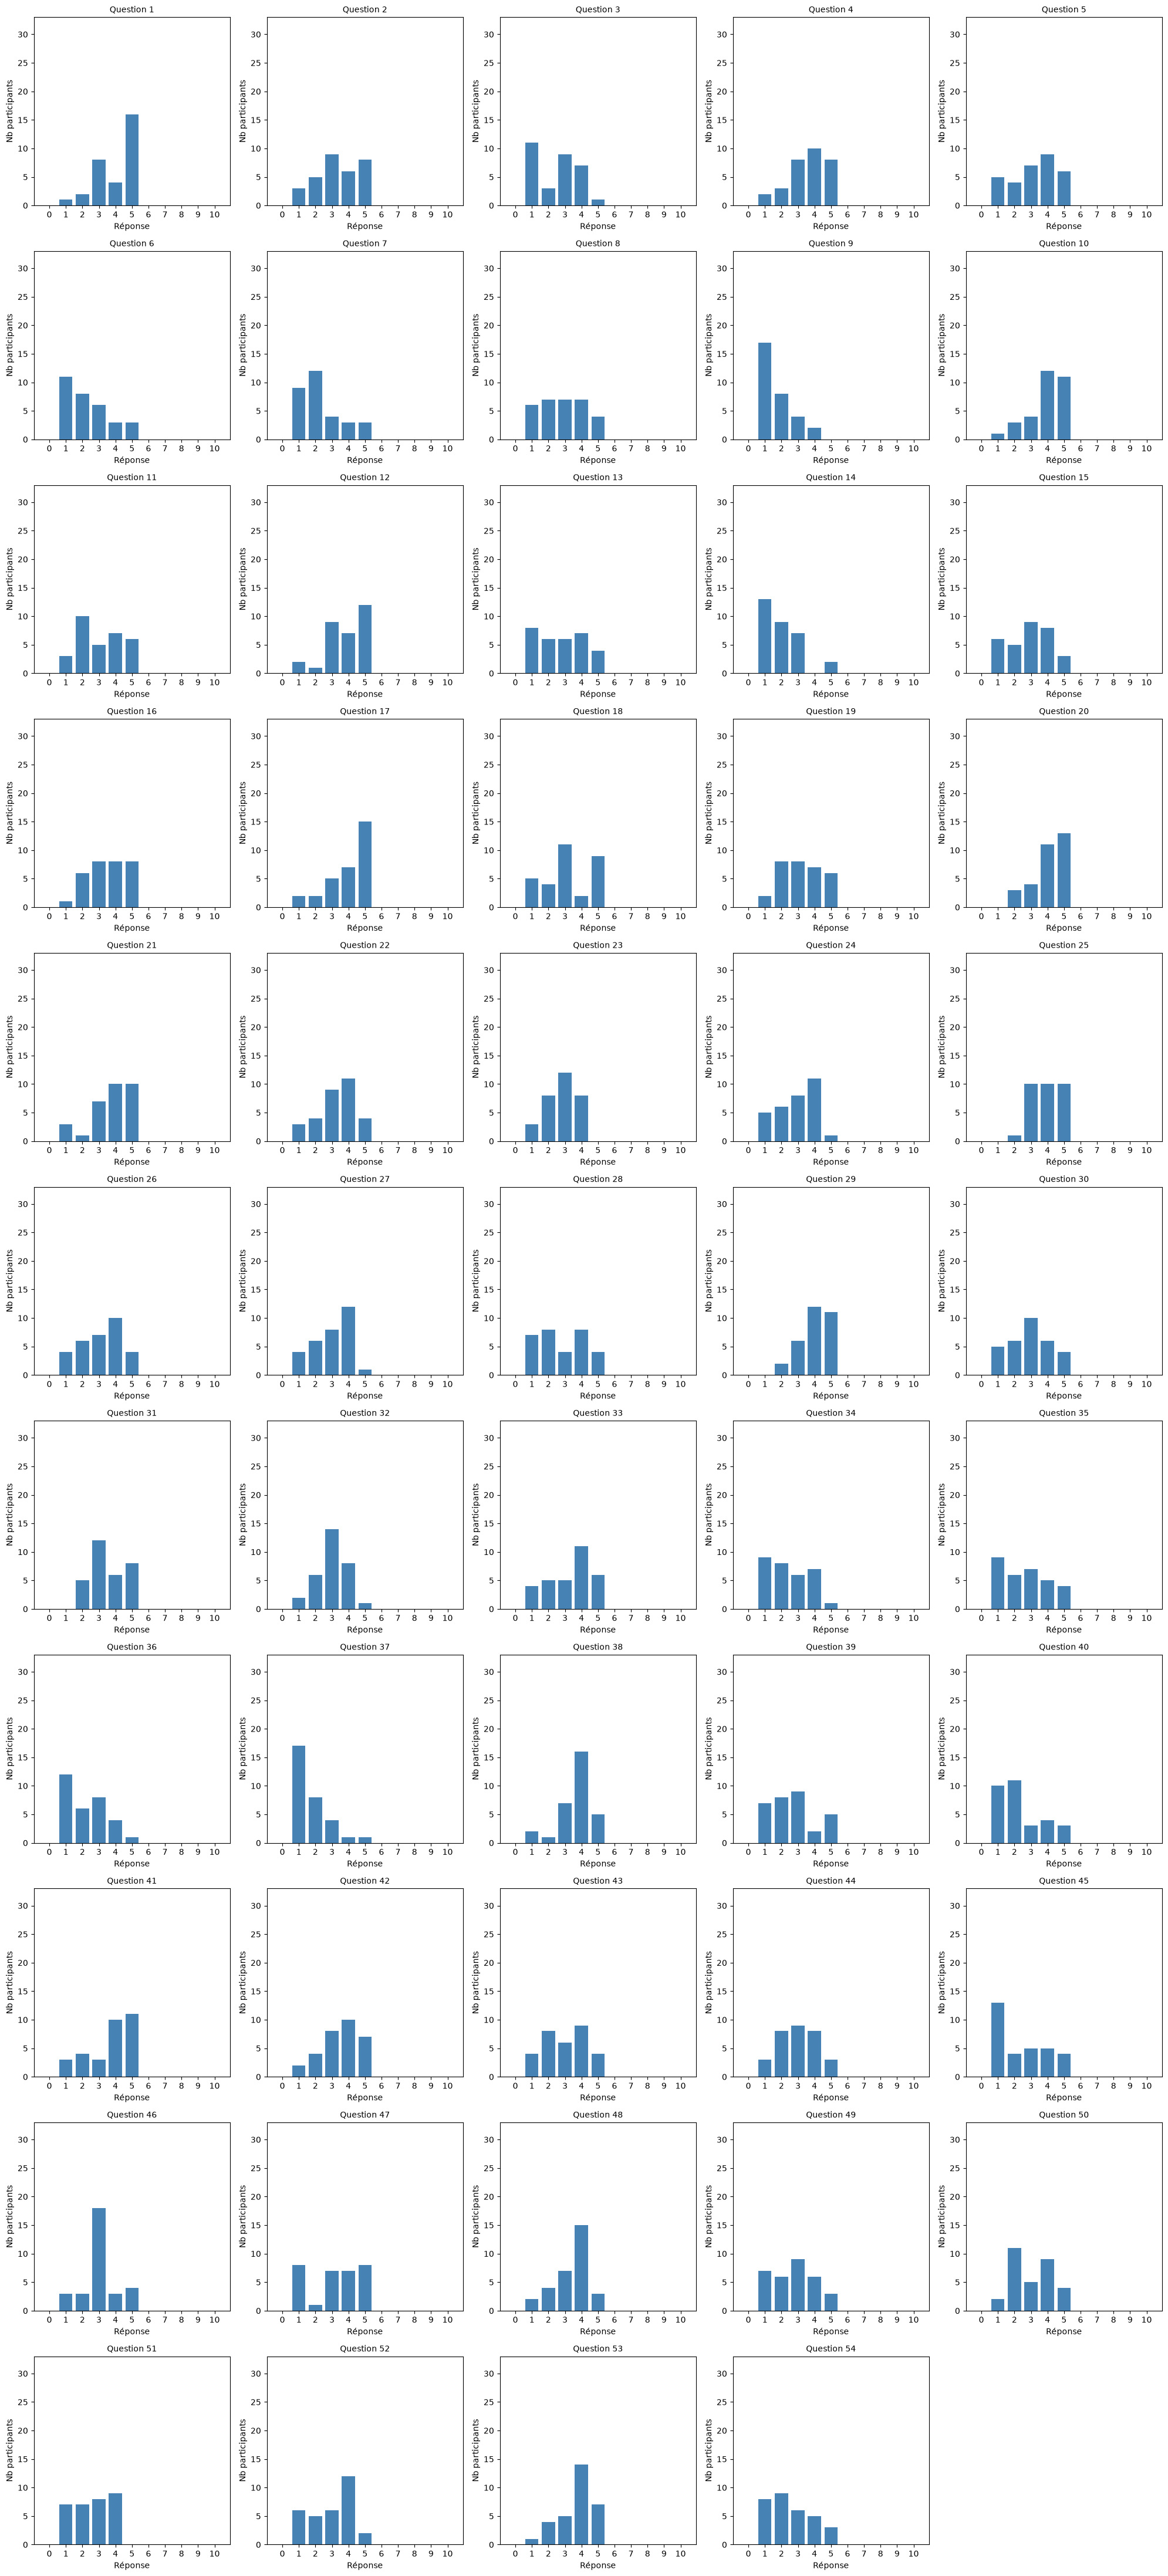

In [173]:

items = df_ZTPI_PD.columns.tolist()
df_ZTPI_PD[items] = df_ZTPI_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_ZTPI_PD[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 33)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [174]:

for i in items:
    print(f"Question : {i}")
    print(df_ZTPI_PD[i].value_counts())
    print("\n")

Question : [1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
5.0    16
3.0     8
4.0     4
2.0     2
1.0     1
Name: count, dtype: int64


Question : [2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
3.0    9
5.0    8
4.0    6
2.0    5
1.0    3
Name: count, dtype: int64


Question : [3- Le destin détermine beaucoup de choses dans ma vie.]
[3- Le destin détermine beaucoup de choses dans ma vie.]
1.0    11
3.0     9
4.0     7
2.0     3
5.0     1
Name: count, dtype: int64


Question : [4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
4.0    10
3.0     8
5.0  

In [175]:
df_ZTPI["score_total"] = df_ZTPI.sum(axis=1)
df_ZTPI["score_total"].describe()

count    154.000000
mean     158.435065
std       16.550941
min      116.000000
25%      146.250000
50%      159.000000
75%      167.750000
max      219.000000
Name: score_total, dtype: float64

In [176]:
df_ZTPI["score_total"].median()

np.float64(159.0)

In [177]:
df_ZTPI_PD["score_total"] = df_ZTPI_PD.sum(axis=1)
df_ZTPI_PD["score_total"].describe()

count     31.000000
mean     165.741935
std       19.273415
min      132.000000
25%      151.500000
50%      164.000000
75%      182.000000
max      212.000000
Name: score_total, dtype: float64

In [178]:
df_ZTPI_PD["score_total"].median()

np.float64(164.0)

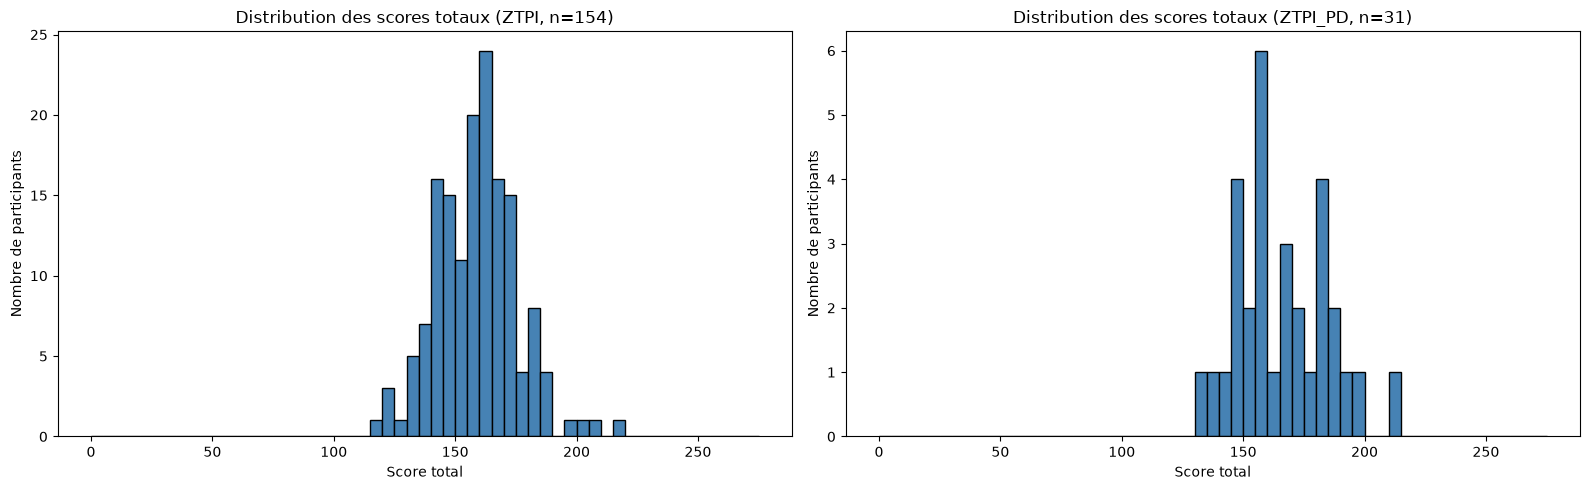

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_ZTPI["score_total"], bins=range(0, 280, 5), color="steelblue", edgecolor="black")
axes[0].set_xlabel("Score total")
axes[0].set_ylabel("Nombre de participants")
axes[0].set_title(f"Distribution des scores totaux (ZTPI, n={len(df_ZTPI)})")

axes[1].hist(df_ZTPI_PD["score_total"], bins=range(0, 280, 5), color="steelblue", edgecolor="black")
axes[1].set_xlabel("Score total")
axes[1].set_ylabel("Nombre de participants")
axes[1].set_title(f"Distribution des scores totaux (ZTPI_PD, n={len(df_ZTPI_PD)})")

plt.tight_layout()
plt.show()

In [180]:
print(df_EP_PD.loc[242, "score_total"]) # pour voir les scores d'une ligne en particulier

23.0


# correlation BAI et present fataliste ZTPI? 
item ZTPI : 28, 14, 39, 35, 53

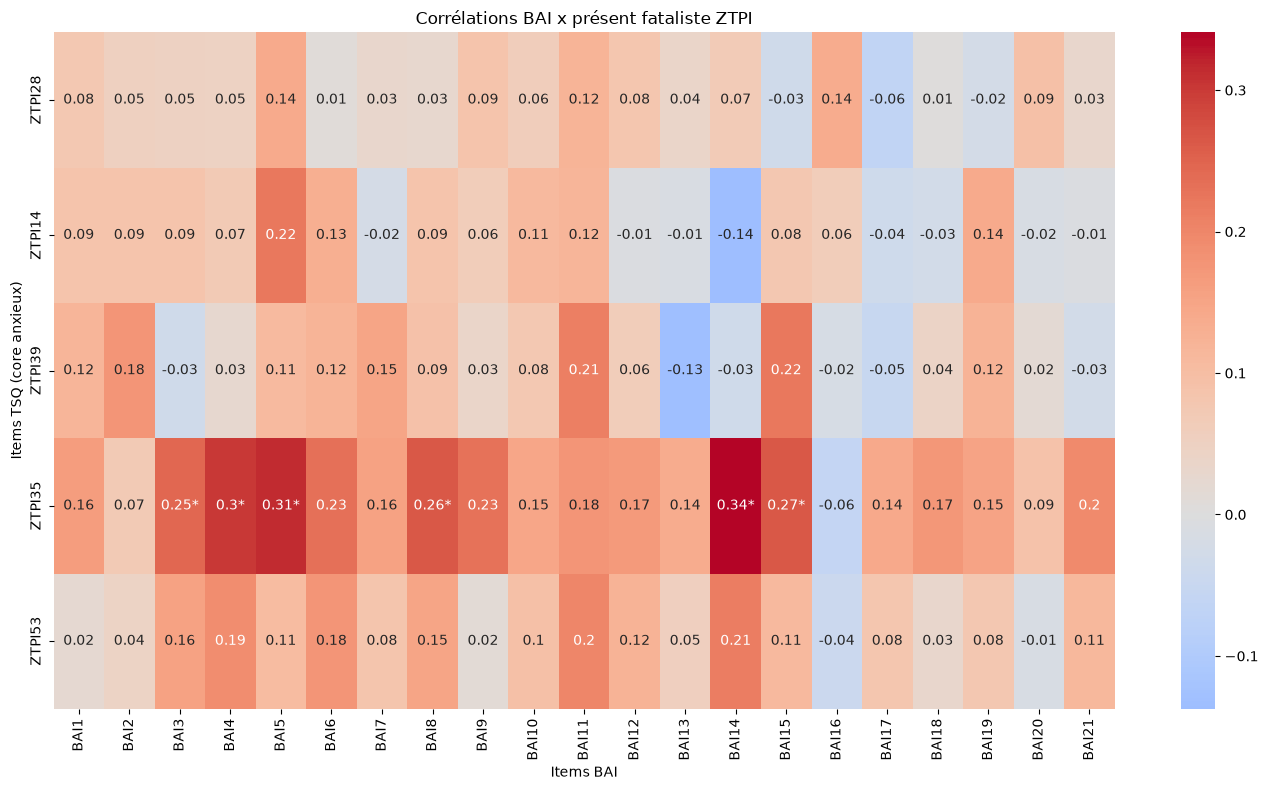

In [262]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ZTPI ---
cols_ZTPI_brutes = df_ZTPI.columns[0:53]
df_ZTPI = df_ZTPI.rename(columns=dict(zip(cols_ZTPI_brutes, [f"ZTPI{i}" for i in range(1, 54)])))
items_ZTPI = [f"ZTPI{i}" for i in range(1, 54)]
df_ZTPI[items_ZTPI] = df_ZTPI[items_ZTPI].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_PF_ZTPI = ['ZTPI28', 'ZTPI14', 'ZTPI39', 'ZTPI35', 'ZTPI53']  # ✅ sans underscore, cohérent avec le renommage

# --- BAI ---
cols_bai_brutes = df_BAI.columns[0:21]  # ✅ définie AVANT utilisation
df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# --- Assemblage (ZTPI et non df !) ---
concat_items = pd.concat([df_ZTPI[items_PF_ZTPI], df_BAI[items_bai]], axis=1)

# --- Corrélation ---
corr_matrix_full = concat_items.corr(method='spearman')
corr_matrix = corr_matrix_full.loc[items_PF_ZTPI, items_bai]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_PF_ZTPI, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_PF_ZTPI, columns=items_bai, dtype=float)

for i in items_PF_ZTPI:
    for u in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05

plt.figure(figsize=(14, 8))

annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations BAI x présent fataliste ZTPI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

BAI 4 = Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]
BAI5= Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]
BAi8 =Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]
BAI 14= Au cours des 7 derniers jours, j’ai été affecté(e) par… [14- Crainte de perdre le contrôle de soi]
BAI 15= Au cours des 7 derniers jours, j’ai été affecté(e) par… [15- Respiration difficile ]

ZTPI35 = [35- Je n’ai plus aucun plaisir à faire des choses si je dois penser aux objectifs, aux conséquences et aux résultats.]

# correlation TSQ core anxieux vs present fataliste ZTPI? 

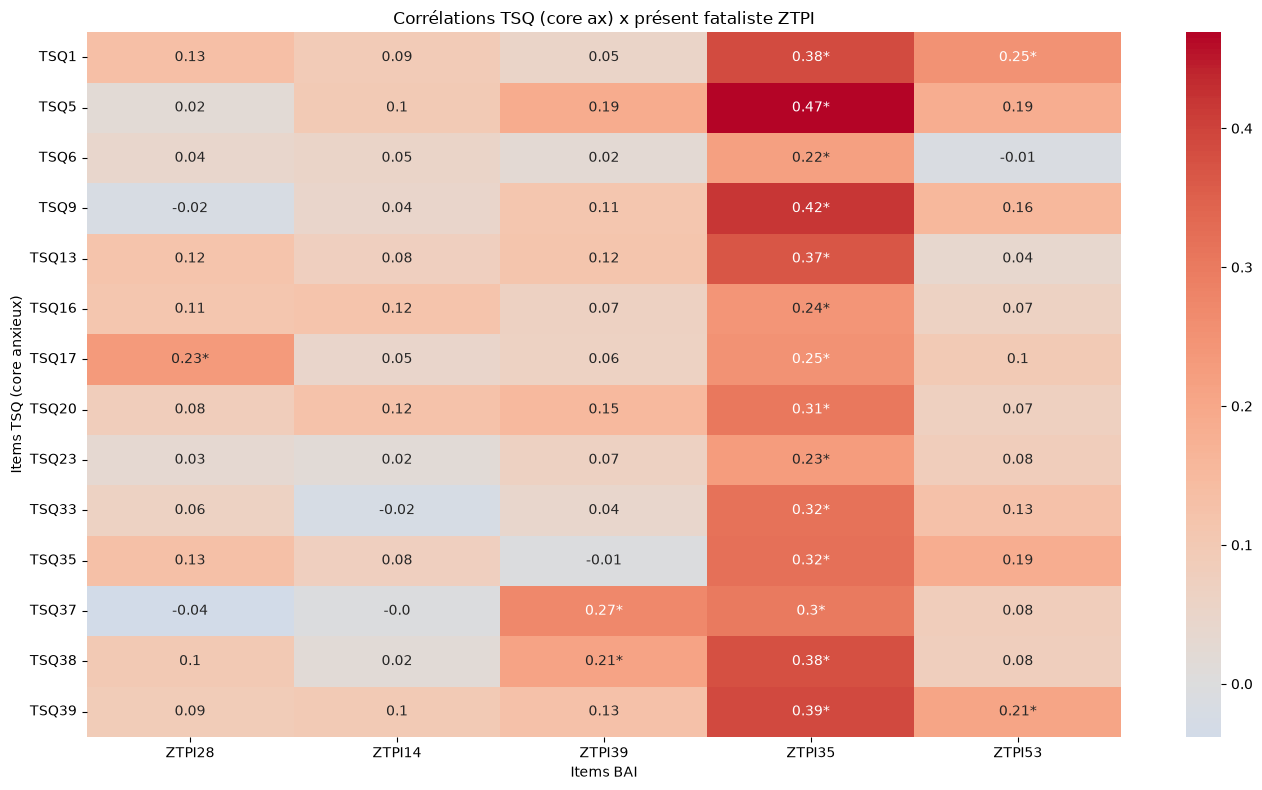

In [263]:

cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20',
                  'TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']


cols_ZTPI_brutes = df_ZTPI.columns[0:53]
df_ZTPI = df_ZTPI.rename(columns=dict(zip(cols_ZTPI_brutes, [f"ZTPI{i}" for i in range(1, 54)])))
items_ZTPI = [f"ZTPI{i}" for i in range(1, 54)]
df_ZTPI[items_ZTPI] = df_ZTPI[items_ZTPI].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_PF_ZTPI = ['ZTPI28', 'ZTPI14', 'ZTPI39', 'ZTPI35', 'ZTPI53']  # ✅ sans underscore, cohérent avec le renommage


# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df[items_core_an], df_ZTPI[items_PF_ZTPI]], axis=1)

# matrice de corrélation complète (TSQ + ZTPI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes ZTPI
corr_matrix = corr_matrix_full.loc[items_core_an, items_PF_ZTPI]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_core_an, columns=items_PF_ZTPI, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_an, columns=items_PF_ZTPI, dtype=float)

for i in items_core_an:
    for u in items_PF_ZTPI:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05

plt.figure(figsize=(14, 8))

annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations TSQ (core ax) x présent fataliste ZTPI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

ZTPI35 correle avec TSQ1, 5, 9, 13, 38, 39
1. Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas 
avoir de vision claire dessus.
5.  Parfois, j'ai l'impression qu'il y a un espace énorme entre ce qu'il s'est passé avant par 
rapport à ce qu'il se passe maintenant ou pourrait se passer après. C'est que j'ai tellement de 
mauvais souvenirs qu'il m'est difficile de me concentrer sur autre chose que le passé. 
9.Je suis inquiet(e) des changements dans ma vie, et me sens submergé(e). 
13.- En ce moment, j’ai l’impression qu’il y a un fossé entre qui je suis aujourd’hui et celui 
(celle) que j’étais. 
38.Je me sens submergé(e) par ma situation actuelle et incapable de contrôler quoi que ce 
soit dans ma vie. On dirait que c'est comme si je n'avais pas assez d'espace pour bouger, 
respirer ou pour atteindre les gens/les choses. 
39.  Mes pensées peuvent parfois être très irrégulières, changeant d'une manière que je ne 
peux pas prévoir ou prédire. 


# Correletion des 40 items de la TSQ

In [182]:
cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

cols_tsq_PD = df_TSQ_PD.columns[0:40]
df_PD = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_PD, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df_PD[items] = df_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

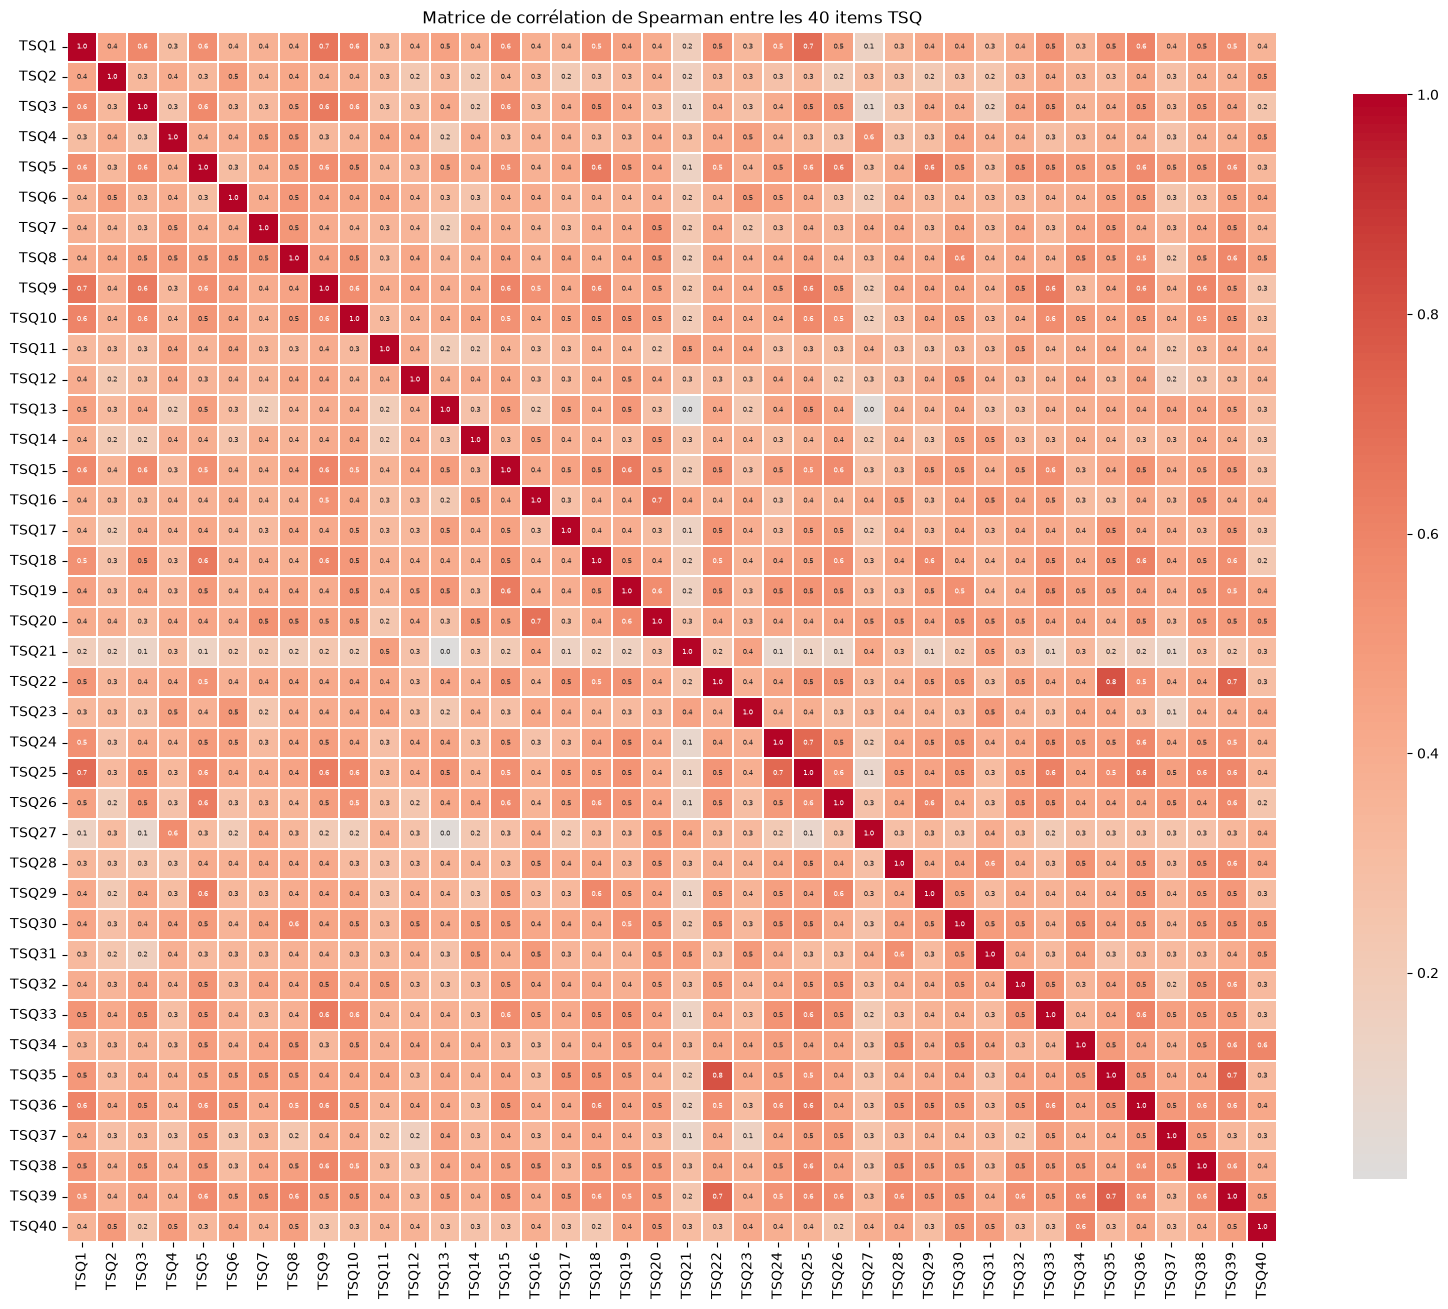

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


items = [f"TSQ{i}" for i in range(1, 41)]

# Matrice de corrélation 40x40
corr_matrix = df[items].corr(method='spearman')  # spearman

# Affichage sous forme de heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", annot_kws={"size": 5}, cmap="coolwarm", center=0, 
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation de Spearman entre les 40 items TSQ")
plt.tight_layout()
plt.show()

In [184]:
import numpy as np

# Ne garder que la partie triangulaire supérieure (évite les doublons et la diagonale)
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Transformer en liste de paires, filtrer > 0.7
strong_corr = corr_pairs.stack().reset_index()
strong_corr.columns = ['item_1', 'item_2', 'correlation']
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

     item_1 item_2  correlation
874   TSQ22  TSQ35     0.798447
1398  TSQ35  TSQ39     0.746195
878   TSQ22  TSQ39     0.730027
944   TSQ24  TSQ25     0.715314
24     TSQ1  TSQ25     0.698277
619   TSQ16  TSQ20     0.674099
8      TSQ1   TSQ9     0.661231
995   TSQ25  TSQ36     0.648865
177    TSQ5  TSQ18     0.648350
88     TSQ3   TSQ9     0.648025
352    TSQ9  TSQ33     0.638853
188    TSQ5  TSQ29     0.638845
578   TSQ15  TSQ19     0.635695
185    TSQ5  TSQ26     0.632589
344    TSQ9  TSQ25     0.631965
715   TSQ18  TSQ36     0.612384
992   TSQ25  TSQ33     0.612214
334    TSQ9  TSQ15     0.601834
997   TSQ25  TSQ38     0.600076


si seuil >0.7 => garder uniquement TSQ22 et supprimer TSQ35 et 39 car correlent chacun avec 22 et entre eux
si seuil >0.6 => garder uniquement TSQ9 et supp 33 et 25 + pareil qu'au dessus
A la main, je trouve aussi qu'il faut supp 36 et 26 et 18 qui correlent fortement avec 5 et entre eux

In [185]:
print(corr_matrix.round(2))
# ou pour exporter en CSV :
corr_matrix.to_csv("correlation_items_TSQ.csv")

       TSQ1  TSQ2  TSQ3  TSQ4  TSQ5  TSQ6  TSQ7  TSQ8  TSQ9  TSQ10  ...  \
TSQ1   1.00  0.43  0.58  0.30  0.56  0.36  0.37  0.40  0.66   0.60  ...   
TSQ2   0.43  1.00  0.33  0.41  0.33  0.47  0.36  0.42  0.38   0.38  ...   
TSQ3   0.58  0.33  1.00  0.26  0.58  0.34  0.32  0.47  0.65   0.58  ...   
TSQ4   0.30  0.41  0.26  1.00  0.39  0.39  0.46  0.49  0.33   0.36  ...   
TSQ5   0.56  0.33  0.58  0.39  1.00  0.30  0.39  0.46  0.56   0.52  ...   
TSQ6   0.36  0.47  0.34  0.39  0.30  1.00  0.40  0.50  0.45   0.44  ...   
TSQ7   0.37  0.36  0.32  0.46  0.39  0.40  1.00  0.52  0.40   0.37  ...   
TSQ8   0.40  0.42  0.47  0.49  0.46  0.50  0.52  1.00  0.45   0.51  ...   
TSQ9   0.66  0.38  0.65  0.33  0.56  0.45  0.40  0.45  1.00   0.56  ...   
TSQ10  0.60  0.38  0.58  0.36  0.52  0.44  0.37  0.51  0.56   1.00  ...   
TSQ11  0.33  0.32  0.28  0.44  0.36  0.44  0.35  0.32  0.40   0.32  ...   
TSQ12  0.39  0.23  0.30  0.42  0.35  0.37  0.35  0.43  0.43   0.37  ...   
TSQ13  0.45  0.32  0.42  

In [186]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[items].dropna()
vif_data = pd.DataFrame()
vif_data['item'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

     item        VIF
21  TSQ22  12.501897
34  TSQ35  11.460132
0    TSQ1  11.226656
38  TSQ39  10.524747
24  TSQ25  10.495069
8    TSQ9  10.243510
35  TSQ36   9.641197
2    TSQ3   7.906682
25  TSQ26   7.285751
17  TSQ18   6.765521
36  TSQ37   6.645303
32  TSQ33   6.539881
14  TSQ15   6.123857
4    TSQ5   5.988221
29  TSQ30   5.797504
18  TSQ19   5.759908
23  TSQ24   5.748845
9   TSQ10   5.736844
16  TSQ17   5.706928
37  TSQ38   5.291159
7    TSQ8   5.197766
31  TSQ32   4.938312
28  TSQ29   4.768864
33  TSQ34   4.403748
12  TSQ13   4.364905
22  TSQ23   4.360876
39  TSQ40   4.223035
27  TSQ28   4.171627
5    TSQ6   4.097504
1    TSQ2   4.016164
19  TSQ20   3.760588
3    TSQ4   3.676898
11  TSQ12   3.667604
30  TSQ31   3.544181
26  TSQ27   2.942983
15  TSQ16   2.823443
13  TSQ14   2.807363
20  TSQ21   2.408321
6    TSQ7   2.293593
10  TSQ11   2.181273


Algo Gloutton Greedy (selectionner les var les + redondantes) : retirer la variable qui a la corrélation moyenne la plus élevée avec toutes les autres variables (celle qui est la plus "redondante" globalement).

In [187]:


import numpy as np
import pandas as pd

def reduce_correlated_features(df, cols, threshold=0.7):
    cols = list(cols)
    while True:
        corr_df = df[cols].corr().abs()
        corr_np = corr_df.to_numpy(copy=True)  # tableau numpy indépendant, modifiable
        np.fill_diagonal(corr_np, 0)
        
        max_corr = corr_np.max()
        if max_corr <= threshold:
            break
        
        mean_corr = corr_np.mean(axis=0)
        i, j = np.unravel_index(np.argmax(corr_np), corr_np.shape)
        var1, var2 = cols[i], cols[j]
        to_drop = var1 if mean_corr[i] > mean_corr[j] else var2
        cols.remove(to_drop)
    return cols

selected_items = reduce_correlated_features(df, items, threshold=0.65)
print(f"Items conservés ({len(selected_items)}/{len(items)}) :")
print(selected_items)

dropped_items = [i for i in items if i not in selected_items]
print(f"\nItems retirés ({len(dropped_items)}) :")
print(dropped_items)

Items conservés (35/40) :
['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']

Items retirés (5) :
['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


# faire nv df sans TSQ 1, 5,9,22,25,36, 39

In [188]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39']  # remplace par tes colonnes
df_red = df.drop(columns=colonnes_a_exclure)

In [189]:
len(df_red.columns)  # Vérifie le nombre de colonnes restantes
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40', 'score_total'],
      dtype='str')


In [190]:
df_red.drop(columns=["score_total"], inplace=True)

In [191]:
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40'],
      dtype='str')


# matrice correle PD


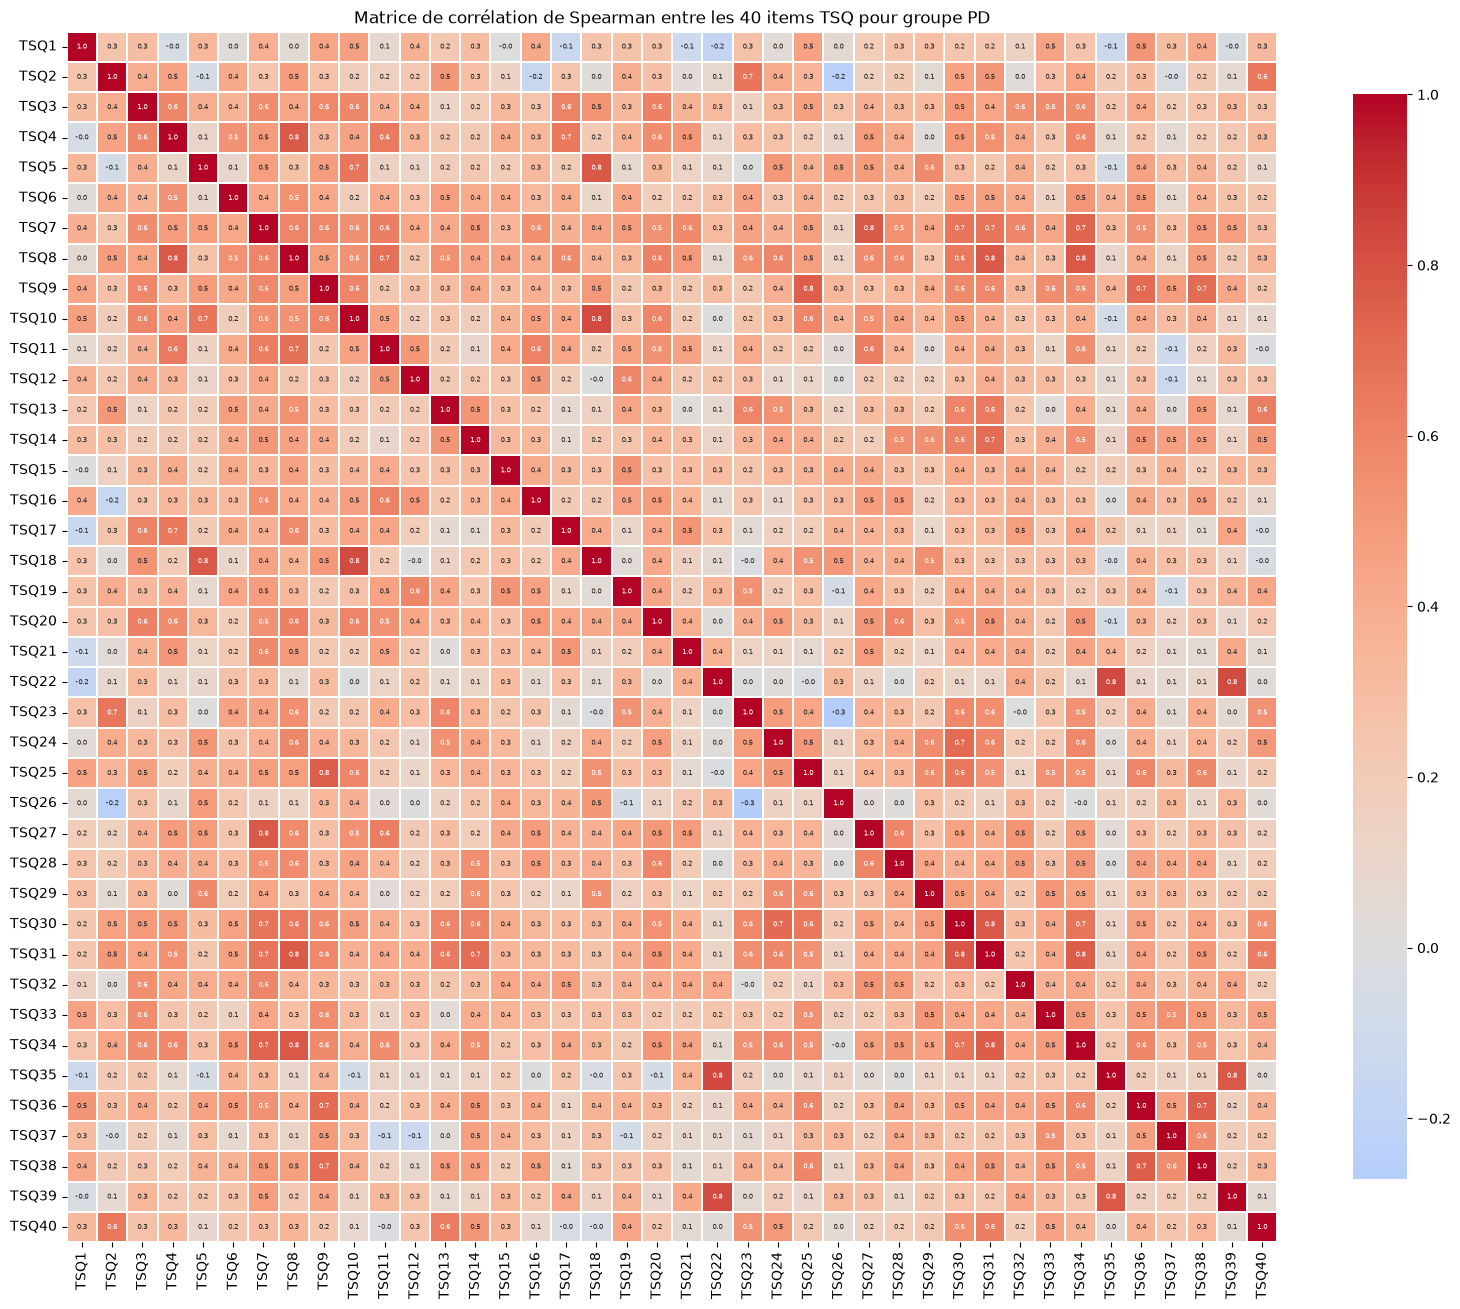

     item_1 item_2  correlation
874   TSQ22  TSQ35     0.829215
377   TSQ10  TSQ18     0.822457
878   TSQ22  TSQ39     0.817545
313    TSQ8  TSQ34     0.780326
177    TSQ5  TSQ18     0.779417
1398  TSQ35  TSQ39     0.778840
1190  TSQ30  TSQ31     0.776060
127    TSQ4   TSQ8     0.767654
266    TSQ7  TSQ27     0.766838
310    TSQ8  TSQ31     0.765991
1233  TSQ31  TSQ34     0.760837
344    TSQ9  TSQ25     0.751052
1437  TSQ36  TSQ38     0.747153
273    TSQ7  TSQ34     0.729269
355    TSQ9  TSQ36     0.707075
949   TSQ24  TSQ30     0.702678
550   TSQ14  TSQ31     0.694635
357    TSQ9  TSQ38     0.693304
290    TSQ8  TSQ11     0.686802
270    TSQ7  TSQ31     0.670640
1193  TSQ30  TSQ34     0.666334
269    TSQ7  TSQ30     0.664581
62     TSQ2  TSQ23     0.659797
169    TSQ5  TSQ10     0.658529
136    TSQ4  TSQ17     0.650393
79     TSQ2  TSQ40     0.648186
989   TSQ25  TSQ30     0.647866
130    TSQ4  TSQ11     0.644501
510   TSQ13  TSQ31     0.639083
309    TSQ8  TSQ30     0.638861
426   TS

In [192]:
# Matrice de corrélation 40x40
corr_matrix_PD = df_PD[items].corr(method='spearman')  # spearman

# Affichage sous forme de heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix_PD, annot=True, fmt=".1f", annot_kws={"size": 5}, cmap="coolwarm", center=0, 
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation de Spearman entre les 40 items TSQ pour groupe PD")
plt.tight_layout()
plt.show()

import numpy as np

# Ne garder que la partie triangulaire supérieure (évite les doublons et la diagonale)
corr_pairs = corr_matrix_PD.where(np.triu(np.ones(corr_matrix_PD.shape), k=1).astype(bool))

# Transformer en liste de paires, filtrer > 0.7
strong_corr = corr_pairs.stack().reset_index()
strong_corr.columns = ['item_1', 'item_2', 'correlation']
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

In [193]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_PD[items].dropna()
vif_data = pd.DataFrame()
vif_data['item'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))



     item  VIF
0    TSQ1  inf
1    TSQ2  inf
2    TSQ3  inf
3    TSQ4  inf
4    TSQ5  inf
5    TSQ6  inf
6    TSQ7  inf
7    TSQ8  inf
8    TSQ9  inf
9   TSQ10  inf
10  TSQ11  inf
11  TSQ12  inf
12  TSQ13  inf
13  TSQ14  inf
14  TSQ15  inf
15  TSQ16  inf
16  TSQ17  inf
17  TSQ18  inf
18  TSQ19  inf
19  TSQ20  inf
20  TSQ21  inf
21  TSQ22  inf
22  TSQ23  inf
23  TSQ24  inf
24  TSQ25  inf
25  TSQ26  inf
26  TSQ27  inf
27  TSQ28  inf
28  TSQ29  inf
29  TSQ30  inf
30  TSQ31  inf
31  TSQ32  inf
32  TSQ33  inf
33  TSQ34  inf
34  TSQ35  inf
35  TSQ36  inf
36  TSQ37  inf
37  TSQ38  inf
38  TSQ39  inf
39  TSQ40  inf


c:\TSQ\data\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [194]:
import numpy as np
import pandas as pd
def reduce_correlated_features(df_PD, cols, threshold=0.7):
    cols = list(cols)
    while True:
        corr_df = df_PD[cols].corr().abs()
        corr_np = corr_df.to_numpy(copy=True)  # tableau numpy indépendant, modifiable
        np.fill_diagonal(corr_np, 0)
        
        max_corr = corr_np.max()
        if max_corr <= threshold:
            break
        
        mean_corr = corr_np.mean(axis=0)
        i, j = np.unravel_index(np.argmax(corr_np), corr_np.shape)
        var1, var2 = cols[i], cols[j]
        to_drop = var1 if mean_corr[i] > mean_corr[j] else var2
        cols.remove(to_drop)
    return cols

selected_items = reduce_correlated_features(df, items, threshold=0.65)
print(f"Items conservés ({len(selected_items)}/{len(items)}) :")
print(selected_items)

dropped_items = [i for i in items if i not in selected_items]
print(f"\nItems retirés ({len(dropped_items)}) :")
print(dropped_items)

Items conservés (35/40) :
['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']

Items retirés (5) :
['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


In [195]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red_PD = df_PD.drop(columns=colonnes_a_exclure)

# PCA
composantes principales qui capturent (ou détiennent) la majeure partie de la variance (information) des données.La direction représente les axes principaux sur lesquels les données sont principalement réparties ou présentent le plus de variance, et l'ampleur signifie la quantité de variance que la composante principale capture des données lorsqu'elle est projetée sur cet axe.

Variance expliquée par composante :
  PC1: 0.383  (cumulée: 0.383)
  PC2: 0.069  (cumulée: 0.451)
  PC3: 0.050  (cumulée: 0.501)
  PC4: 0.045  (cumulée: 0.546)
  PC5: 0.037  (cumulée: 0.583)
  PC6: 0.033  (cumulée: 0.616)
  PC7: 0.030  (cumulée: 0.647)
  PC8: 0.030  (cumulée: 0.676)
  PC9: 0.027  (cumulée: 0.703)
  PC10: 0.024  (cumulée: 0.728)
  PC11: 0.022  (cumulée: 0.750)
  PC12: 0.022  (cumulée: 0.772)
  PC13: 0.020  (cumulée: 0.792)
  PC14: 0.020  (cumulée: 0.811)
  PC15: 0.018  (cumulée: 0.829)
  PC16: 0.017  (cumulée: 0.846)
  PC17: 0.016  (cumulée: 0.862)
  PC18: 0.014  (cumulée: 0.876)
  PC19: 0.014  (cumulée: 0.889)
  PC20: 0.013  (cumulée: 0.902)
  PC21: 0.012  (cumulée: 0.914)
  PC22: 0.011  (cumulée: 0.925)
  PC23: 0.010  (cumulée: 0.935)
  PC24: 0.009  (cumulée: 0.944)
  PC25: 0.009  (cumulée: 0.953)
  PC26: 0.008  (cumulée: 0.960)
  PC27: 0.007  (cumulée: 0.968)
  PC28: 0.007  (cumulée: 0.975)
  PC29: 0.007  (cumulée: 0.981)
  PC30: 0.006  (cumulée: 0.987)
  PC31: 0.005

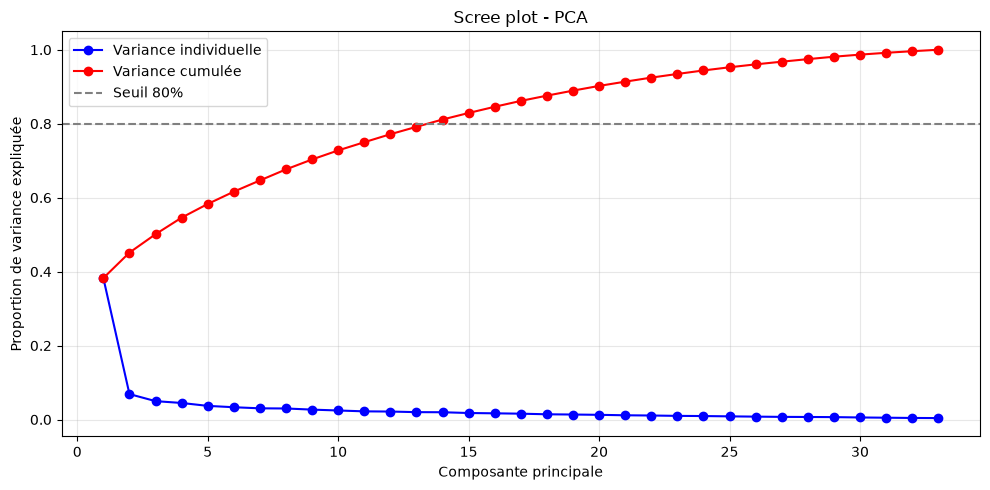

In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardiser les données car la var des items n'est pas forcement la meme. J'ai essayé sans ca me donne rien de bon
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_red)

pca = PCA()
pca.fit(X_scaled)

# 4. Variance expliquée par chaque composante
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Variance expliquée par composante :")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"  PC{i}: {var:.3f}  (cumulée: {cum:.3f})")

# 5. Scree plot (graphique du coude)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, 'bo-', label='Variance individuelle')
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Proportion de variance expliquée')
plt.title('Scree plot - PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [197]:
eigenvalues = pca.explained_variance_
n_components_kaiser = sum(eigenvalues > 1)
print(f"Nombre de composantes selon Kaiser (eigenvalue > 1) : {n_components_kaiser}")

Nombre de composantes selon Kaiser (eigenvalue > 1) : 7


In [198]:
n_components_80 = np.argmax(cumulative_var >= 0.8) + 1
print(f"Nombre de composantes pour 80% de variance expliquée : {n_components_80}")

Nombre de composantes pour 80% de variance expliquée : 14


In [199]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

X = df_red

# PCA avec toutes les composantes (pour voir la variance expliquée)
pca = PCA()
pca.fit(X)

print("Variance expliquée par composante :")
print(pca.explained_variance_ratio_)

print("\nVariance cumulée :")
print(np.cumsum(pca.explained_variance_ratio_))

print("\nValeurs singulières :")
print(pca.singular_values_)

Variance expliquée par composante :
[0.41477342 0.06386527 0.04330826 0.0421379  0.0395379  0.03692391
 0.03210351 0.02920896 0.0267425  0.02457902 0.02245089 0.02103861
 0.02047247 0.01690553 0.01658676 0.01588221 0.01474861 0.01378411
 0.01192111 0.01156097 0.01069059 0.00980266 0.00879999 0.00813637
 0.00744704 0.0069319  0.006575   0.00499319 0.00451787 0.00402566
 0.00340543 0.00332298 0.00281942]

Variance cumulée :
[0.41477342 0.47863869 0.52194695 0.56408484 0.60362275 0.64054666
 0.67265017 0.70185913 0.72860162 0.75318064 0.77563153 0.79667014
 0.81714261 0.83404814 0.8506349  0.86651712 0.88126573 0.89504983
 0.90697094 0.91853191 0.9292225  0.93902516 0.94782515 0.95596152
 0.96340856 0.97034046 0.97691545 0.98190864 0.98642651 0.99045217
 0.9938576  0.99718058 1.        ]

Valeurs singulières :
[119.45602007  46.87431952  38.6000561   38.07492107  36.88157082
  35.64153786  33.23371135  31.7000989   30.33217479  29.07935956
  27.79197319  26.90364242  26.53918971  24.11665

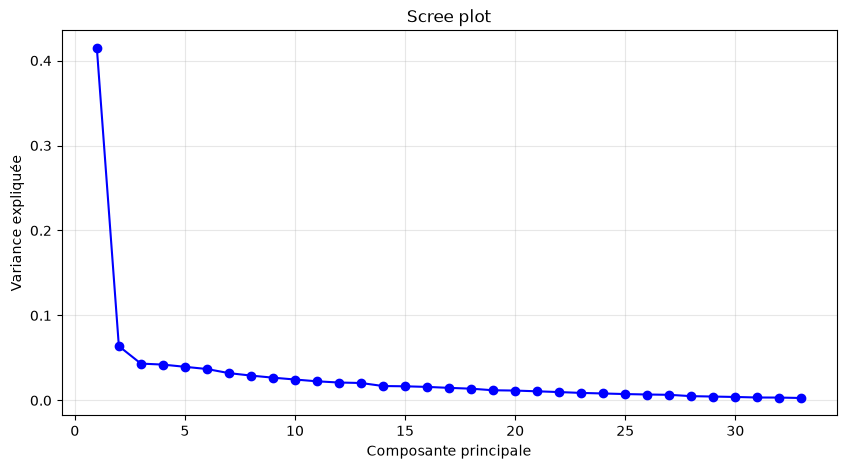

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Scree plot')
plt.grid(True, alpha=0.3)
plt.show()

au coude s'arreter la

In [201]:
n_components_kaiser = sum(pca.explained_variance_ > 1)
print(f"Nombre de composantes (Kaiser) : {n_components_kaiser}")

Nombre de composantes (Kaiser) : 29


Une composante n'est "utile" que si elle explique plus de variance qu'une seule variable originale ne le ferait.

Tu prends le nombre minimal de composantes qui capture au moins X% de la variance totale.

In [202]:
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"Nombre de composantes pour 80% de variance : {n_components_80}")

Nombre de composantes pour 80% de variance : 13


In [203]:
from sklearn.decomposition import PCA
pca_TSQ = PCA(n_components=2)
principalComponents_TSQ = pca_TSQ.fit_transform(X_scaled)


In [204]:
principal_TSQ_Df = pd.DataFrame(data = principalComponents_TSQ
             , columns = ['principal component 1', 'principal component 2'])



In [205]:
principal_TSQ_Df.tail()


,principal component 1,principal component 2
149,-3.117935,-0.273333
150,1.129451,-2.318484
151,1.387770,-0.317472
152,-0.660920,0.278057
153,-3.555115,0.394801


In [206]:
print('Explained variability per principal component: {}'.format(pca_TSQ.explained_variance_ratio_))


Explained variability per principal component: [0.38259685 0.06883532]


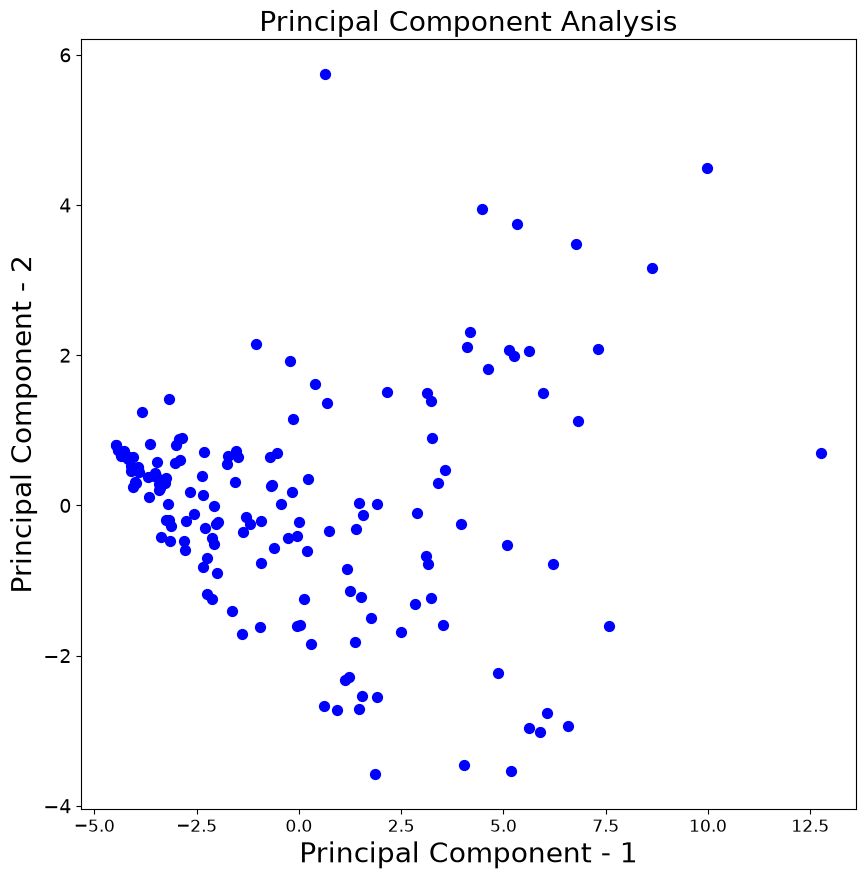

In [207]:
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1', fontsize=20)
plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("Principal Component Analysis", fontsize=20)

plt.scatter(principal_TSQ_Df['principal component 1'],
            principal_TSQ_Df['principal component 2'],
            c='b', s=50)

plt.show()

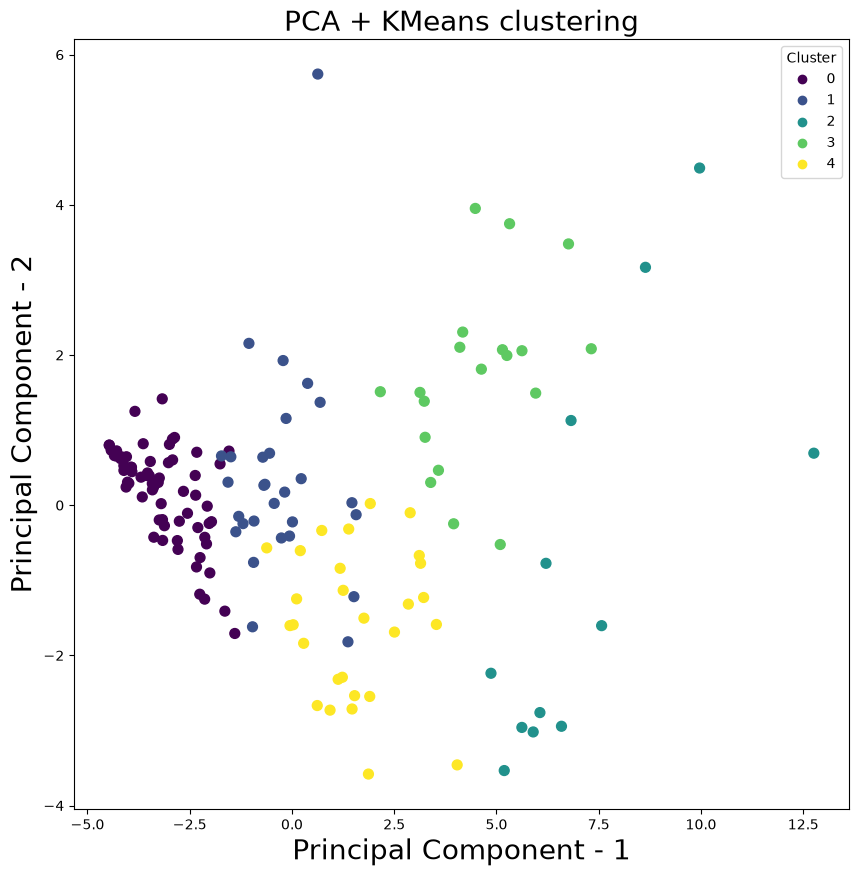

In [208]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,10))
plt.xlabel('Principal Component - 1', fontsize=20)
plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("PCA + KMeans clustering", fontsize=20)
scatter = plt.scatter(principal_TSQ_Df['principal component 1'],
                       principal_TSQ_Df['principal component 2'],
                       c=clusters, cmap='viridis', s=50)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# t-SNE embedding 

divergence KL" (qui mesure à quel point l'espace réduit respecte la structure des données originales

In [209]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px

from sklearn.preprocessing import StandardScaler

# Standardiser les données car la var des items n'est pas forcement la meme. J'ai essayé sans ca me donne rien de bon
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df)
# X = X_scaled 

# change tout de normaliser et j'ai l'impression que c'est pas mieux donc à voir
X = df.values # la j'ai pris le df avec les 40 items , j'ai essayé avec le df_red (sans 7 items qui etaient corrélés mais ca donne moins bien)

perplexity = np.arange(5, 55, 5)
divergence = []


for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i, random_state=42)
    reduced = model.fit_transform(X)
    divergence.append(model.kl_divergence_)

fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show(renderer="browser")

* Perplexité =variance de la gaussienne utilisée pour calculer les similarités entre les paires de points dans l’espace de départ. Plus la perplexité est élevée, plus les voisins éloignés d’un point seront considérés. À l’inverse, une perplexité faible n’accordera d’importance qu’aux voisins les plus proches du point.

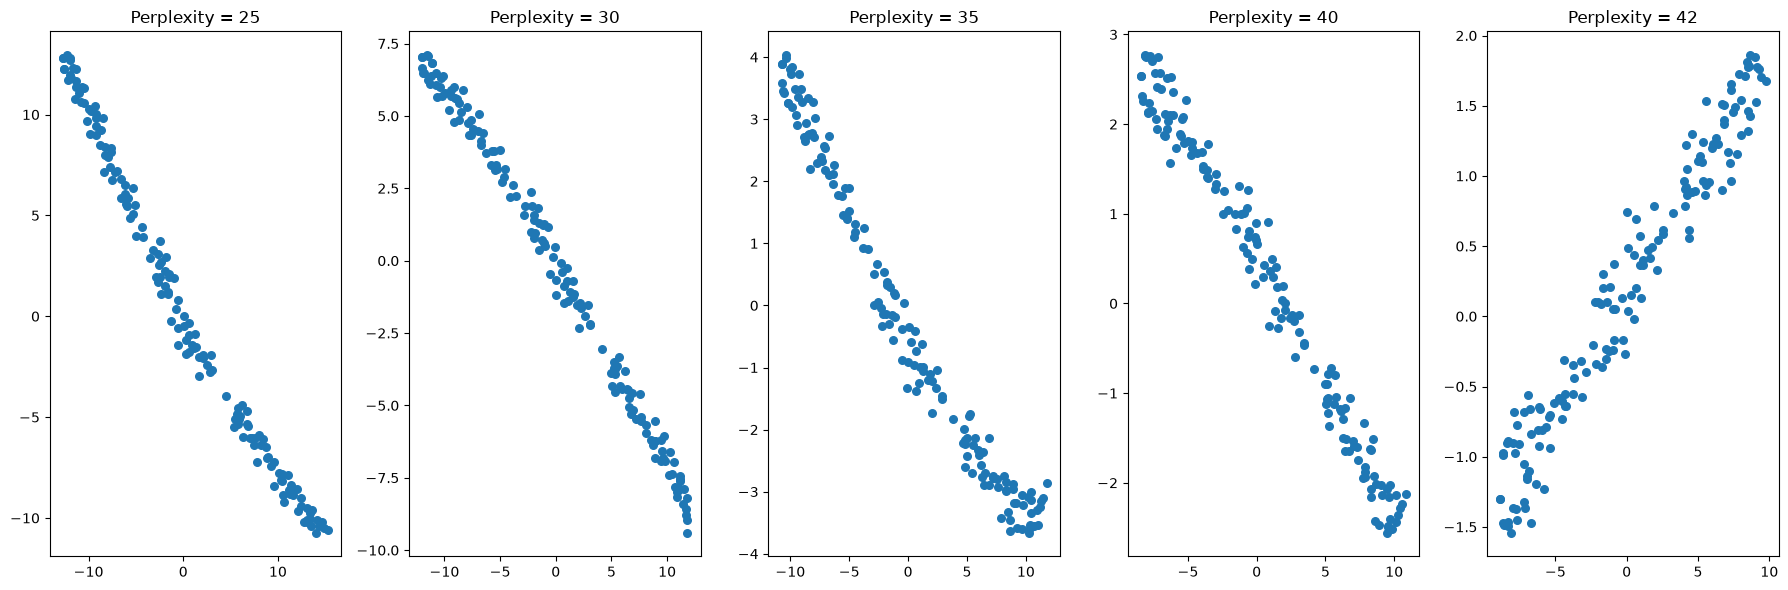

In [210]:
import matplotlib.pyplot as plt

perplexities_to_test = [25, 30, 35, 40, 42]
fig, axes = plt.subplots(1, len(perplexities_to_test), figsize=(18, 6))

for ax, p in zip(axes, perplexities_to_test):
    model = TSNE(n_components=2, init="pca", perplexity=p, random_state=42) #hyperpara : init, generalement "random" mais ici c'est plus  en faisant pca
    reduced = model.fit_transform(X)
    ax.scatter(reduced[:, 0], reduced[:, 1], s=30)
    ax.set_title(f"Perplexity = {p}")

plt.tight_layout()
plt.show()

+ on aug la perplexity + ca va conserver la strucure originelle, mais + petit + ca separe

In [211]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="pca", perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X)

tsne.kl_divergence_

0.08690353482961655

In [212]:
participant_ids = df.index  # [0, 1, 2, ..., 153]
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1])

fig.update_layout(
    title="t-SNE visualization - Participants sains",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")


In [213]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # essaie différents n_clusters
clusters = kmeans.fit_predict(X)
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig = px.scatter(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1],
    hover_name=participant_ids,
    color=clusters.astype(str),  # colore par cluster trouvé
    color_discrete_sequence=custom_colors
)
fig.update_layout(
    title="t-SNE coloré par clusters KMeans",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")
# donne un graph interactif en cliquant sur les points : on sait qui est le aprticipant

* Outre les paramètres généraux de l’algorithme, l’optimisation de TSNE peut être modifiée à l’aide des paramètres optionnels suivants:

early_exaggeration: facteur d’exagération des similarités pour la phase initiale de l’optimisation.

learning_rate: détermine le pas de l’algorithme de descente de gradient. L’utilisation de la valeur "auto" est recommandée (elle exploite l’heuristique de [BCA19]).

n_iter: nombre d’itérations de la descente de gradient. Il peut être utile d’augmenter ce paramètre si t-SNE ne converge pas dans le temps imparti.

method ("barnes_hut" par défaut, accepte aussi la valeur "exact"): définit la méthode utilisée pour le calcul du gradient. Par défaut, TSNE utilise la méthode de Barnes-Hut qui est une approximation en O(NlogN)
 plutôt que la méthode exacte en O(N2)
. La méthode exacte ne passe pas à l’échelle au-delà de quelques milliers d’exemples

# Visu en 3D

In [214]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import plotly.express as px
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 

# TSNE en 3 dimensions
tsne = TSNE(n_components=3, perplexity=45, random_state=42)
projections = tsne.fit_transform(X)

# Clustering pour avoir une couleur (puisque tu n'as pas de labels)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

fig = px.scatter_3d(
    projections, x=0, y=1, z=2,
    color=clusters.astype(str),
    labels={'color': 'Cluster'},
    hover_name=[f"Participant {i}" for i in df_red.index],
    color_discrete_sequence=custom_colors
)
fig.update_traces(marker_size=5)
fig.update_layout(title="t-SNE 3D - Participants sains (TSQ)")
fig.show(renderer="browser")

In [215]:
for trace in fig.data:
    print(trace.name, "->", len(trace.x), "points")

2 -> 28 points
1 -> 20 points
4 -> 50 points
0 -> 42 points
3 -> 14 points


Extraire les groupes de  participants par cluster

cluster 0 = jaune, 1 =violet , 2 = rouge, 3= vert , 4 = bleu

In [216]:
# on ajoute directement le label de cluster à df_clust
df_clust = df.copy()
df_clust['cluster'] = clusters

# vérifier la répartition
print(df_clust['cluster'].value_counts().sort_index())

cluster
0    42
1    20
2    28
3    14
4    50
Name: count, dtype: int64


In [217]:
groupes = {c: df_clust[df_clust['cluster'] == c] for c in sorted(df_clust['cluster'].unique())}

# exemple d'accès
groupes[0]   # DataFrame des participants du cluster 0
groupes[1]   # DataFrame des participants du cluster 1
groupes[2]   # DataFrame des participants du cluster 2
groupes[3]   # DataFrame des participants du cluster 3
groupes[4]   # DataFrame des participants du cluster 4
# juste les index (identifiants participants) par cluster
participants_par_cluster = {c: grp.index.tolist() for c, grp in groupes.items()}
print(participants_par_cluster)

{np.int32(0): [12, 17, 32, 40, 43, 54, 55, 59, 61, 66, 83, 91, 104, 110, 115, 116, 117, 118, 122, 141, 146, 147, 157, 161, 163, 164, 165, 174, 185, 194, 196, 197, 231, 241, 255, 267, 268, 271, 275, 299, 301, 308], np.int32(1): [3, 27, 31, 44, 46, 52, 67, 86, 129, 132, 142, 159, 200, 201, 217, 223, 253, 260, 279, 281], np.int32(2): [1, 5, 21, 22, 51, 74, 75, 138, 144, 172, 173, 184, 202, 207, 210, 214, 215, 218, 222, 224, 250, 264, 289, 291, 294, 297, 306, 307], np.int32(3): [16, 72, 88, 121, 124, 145, 160, 170, 175, 206, 212, 226, 229, 246], np.int32(4): [9, 10, 18, 19, 24, 37, 38, 39, 42, 48, 49, 50, 53, 56, 60, 64, 65, 68, 73, 85, 87, 90, 95, 99, 106, 108, 114, 119, 125, 130, 136, 155, 166, 168, 179, 181, 186, 204, 205, 236, 238, 248, 261, 262, 263, 270, 292, 298, 304, 311]}


In [218]:
for c, grp in groupes.items():
    grp.to_csv(f"cluster_{c}_participants.csv")

ou des df par groupe

In [219]:
df_cluster0 = df_clust[df_clust['cluster'] == 0]
df_cluster1 = df_clust[df_clust['cluster'] == 1]
df_cluster2 = df_clust[df_clust['cluster'] == 2]
df_cluster3 = df_clust[df_clust['cluster'] == 3]
df_cluster4 = df_clust[df_clust['cluster'] == 4]

for i, d in enumerate([df_cluster0, df_cluster1, df_cluster2, df_cluster3, df_cluster4]):
    print(f"Cluster {i}: {len(d)} participants")

Cluster 0: 42 participants
Cluster 1: 20 participants
Cluster 2: 28 participants
Cluster 3: 14 participants
Cluster 4: 50 participants


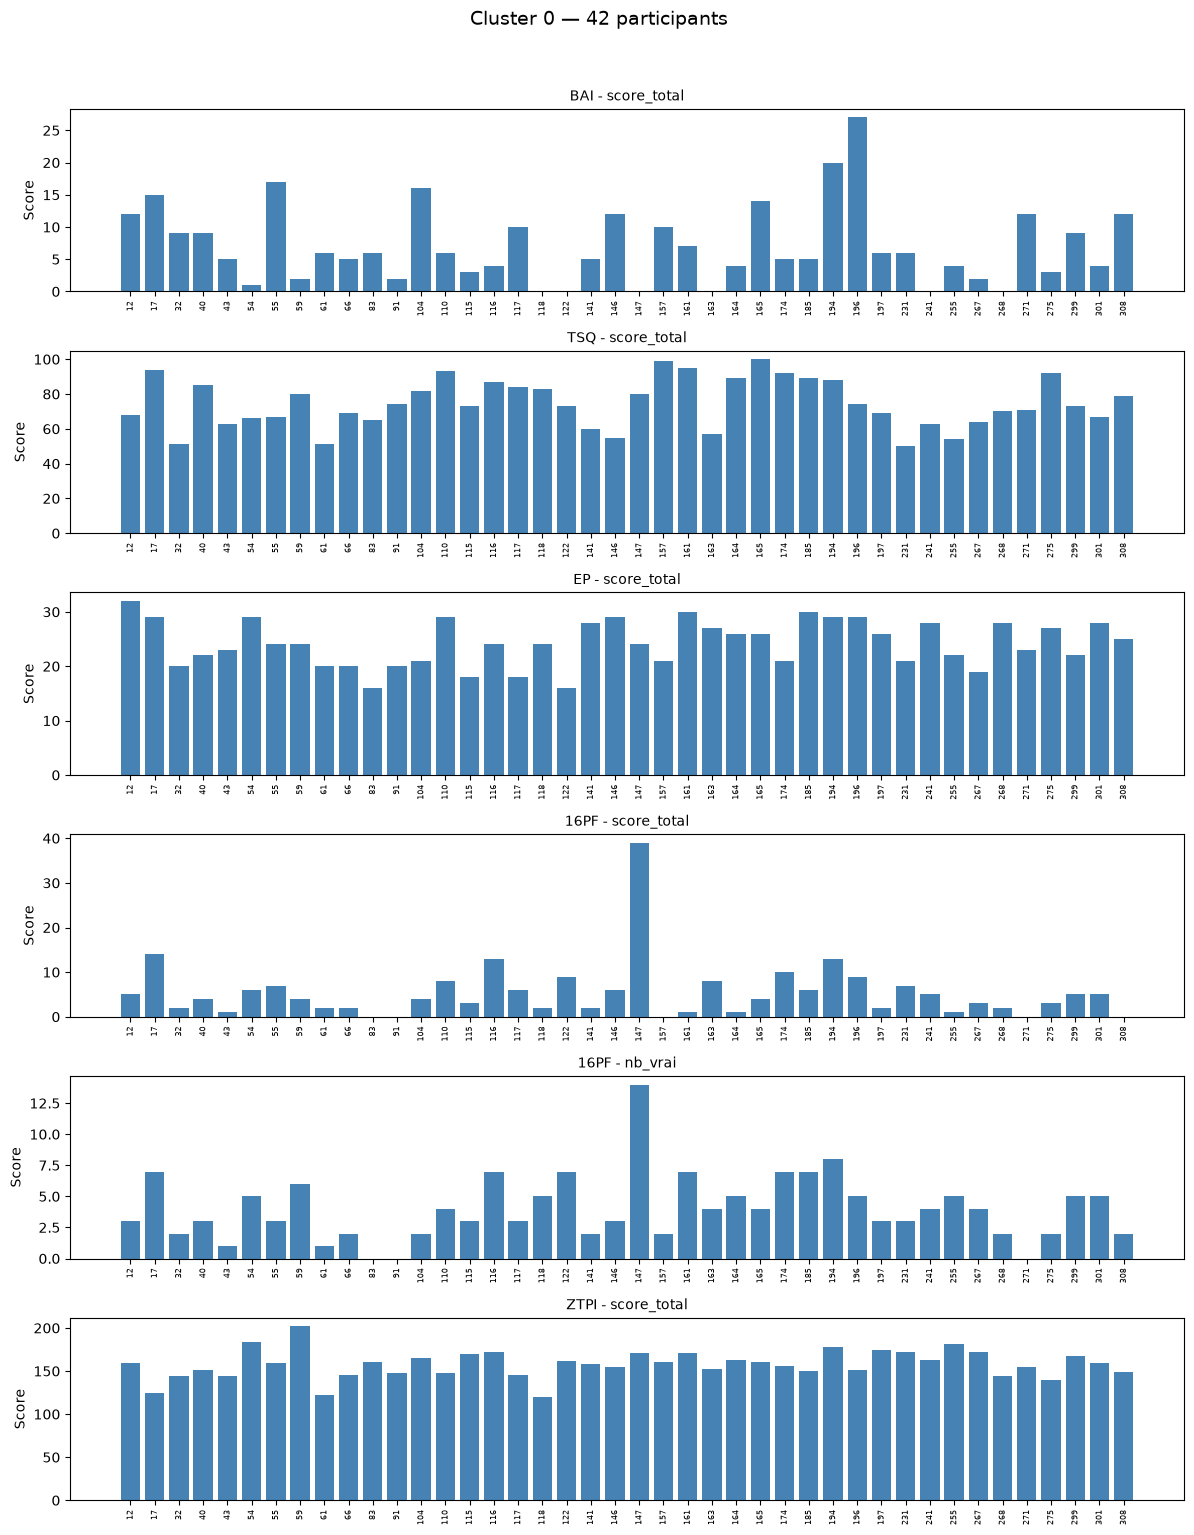

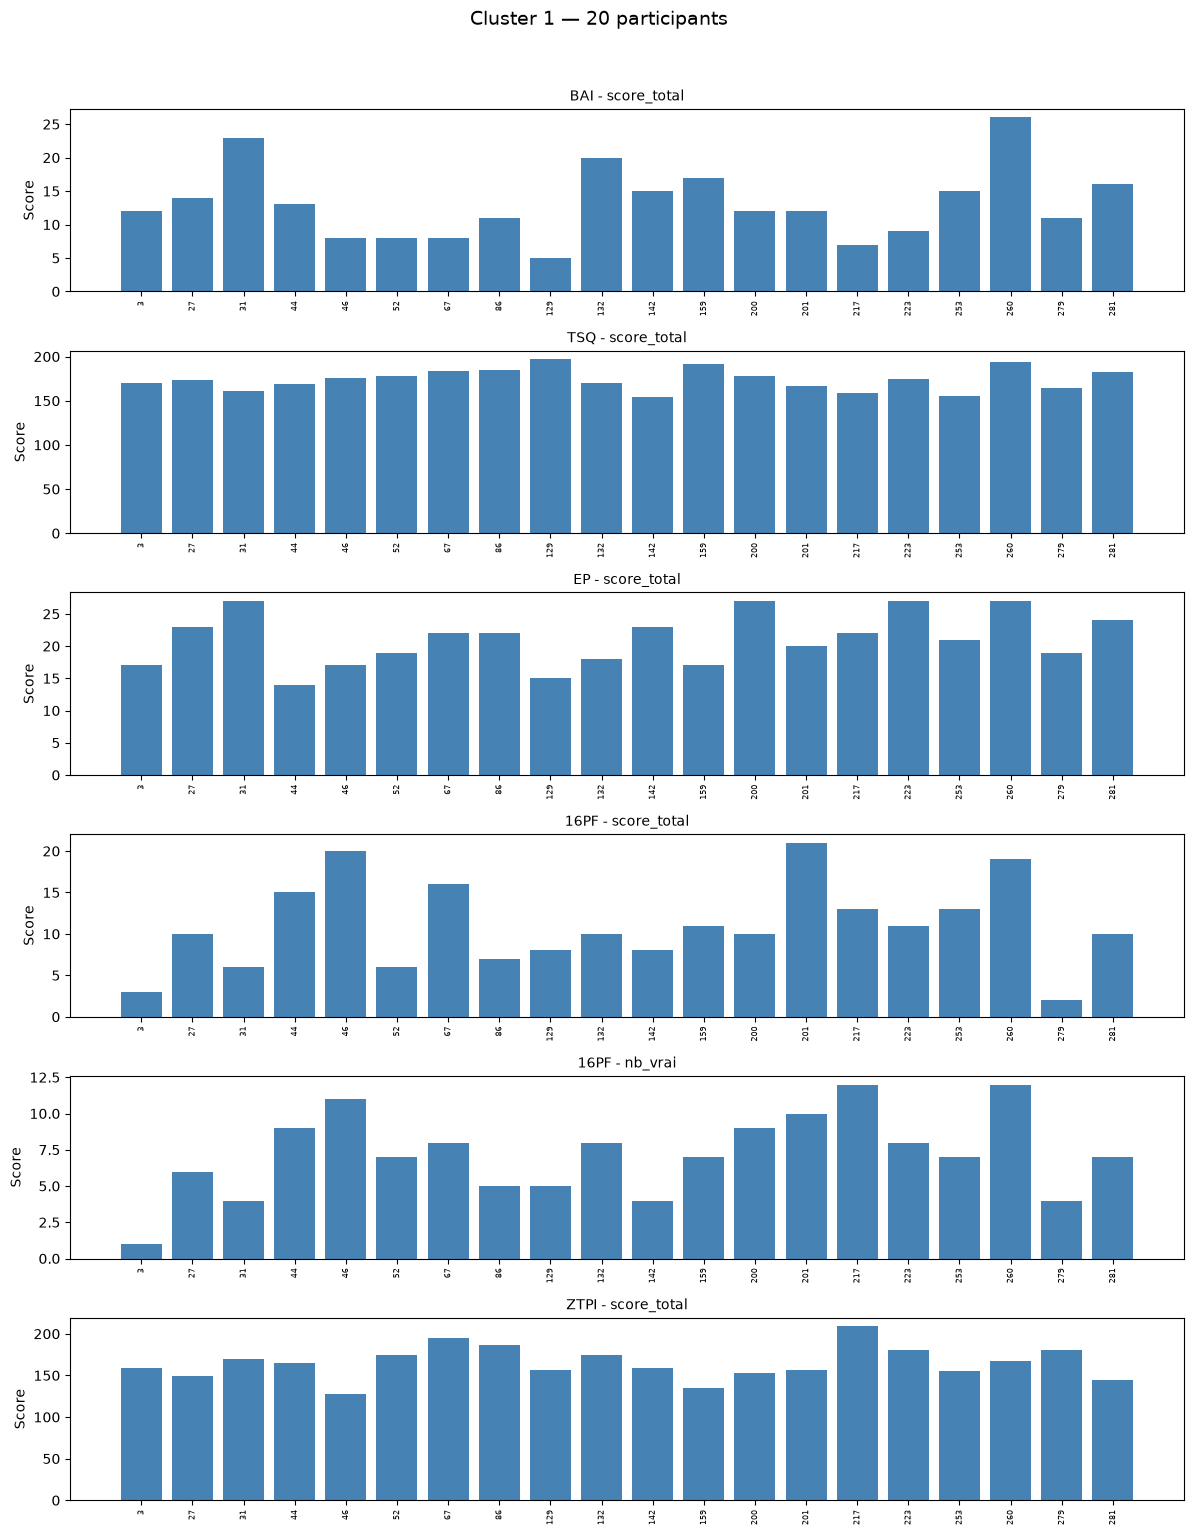

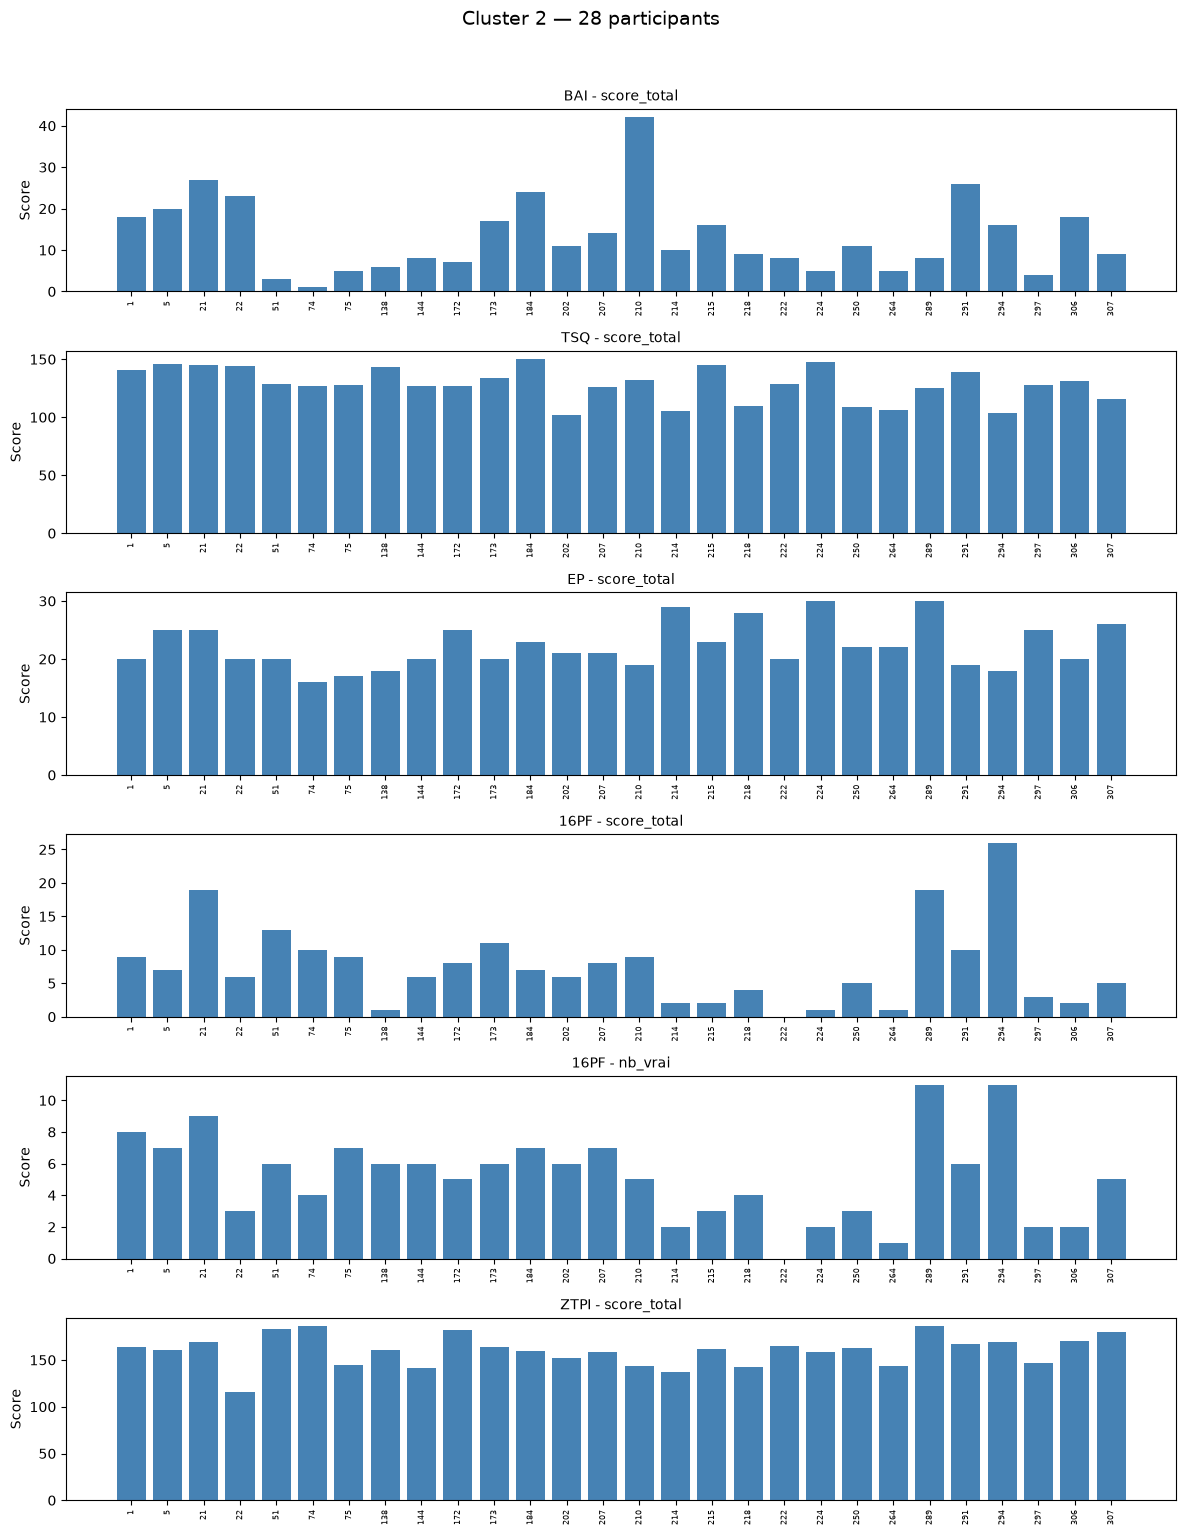

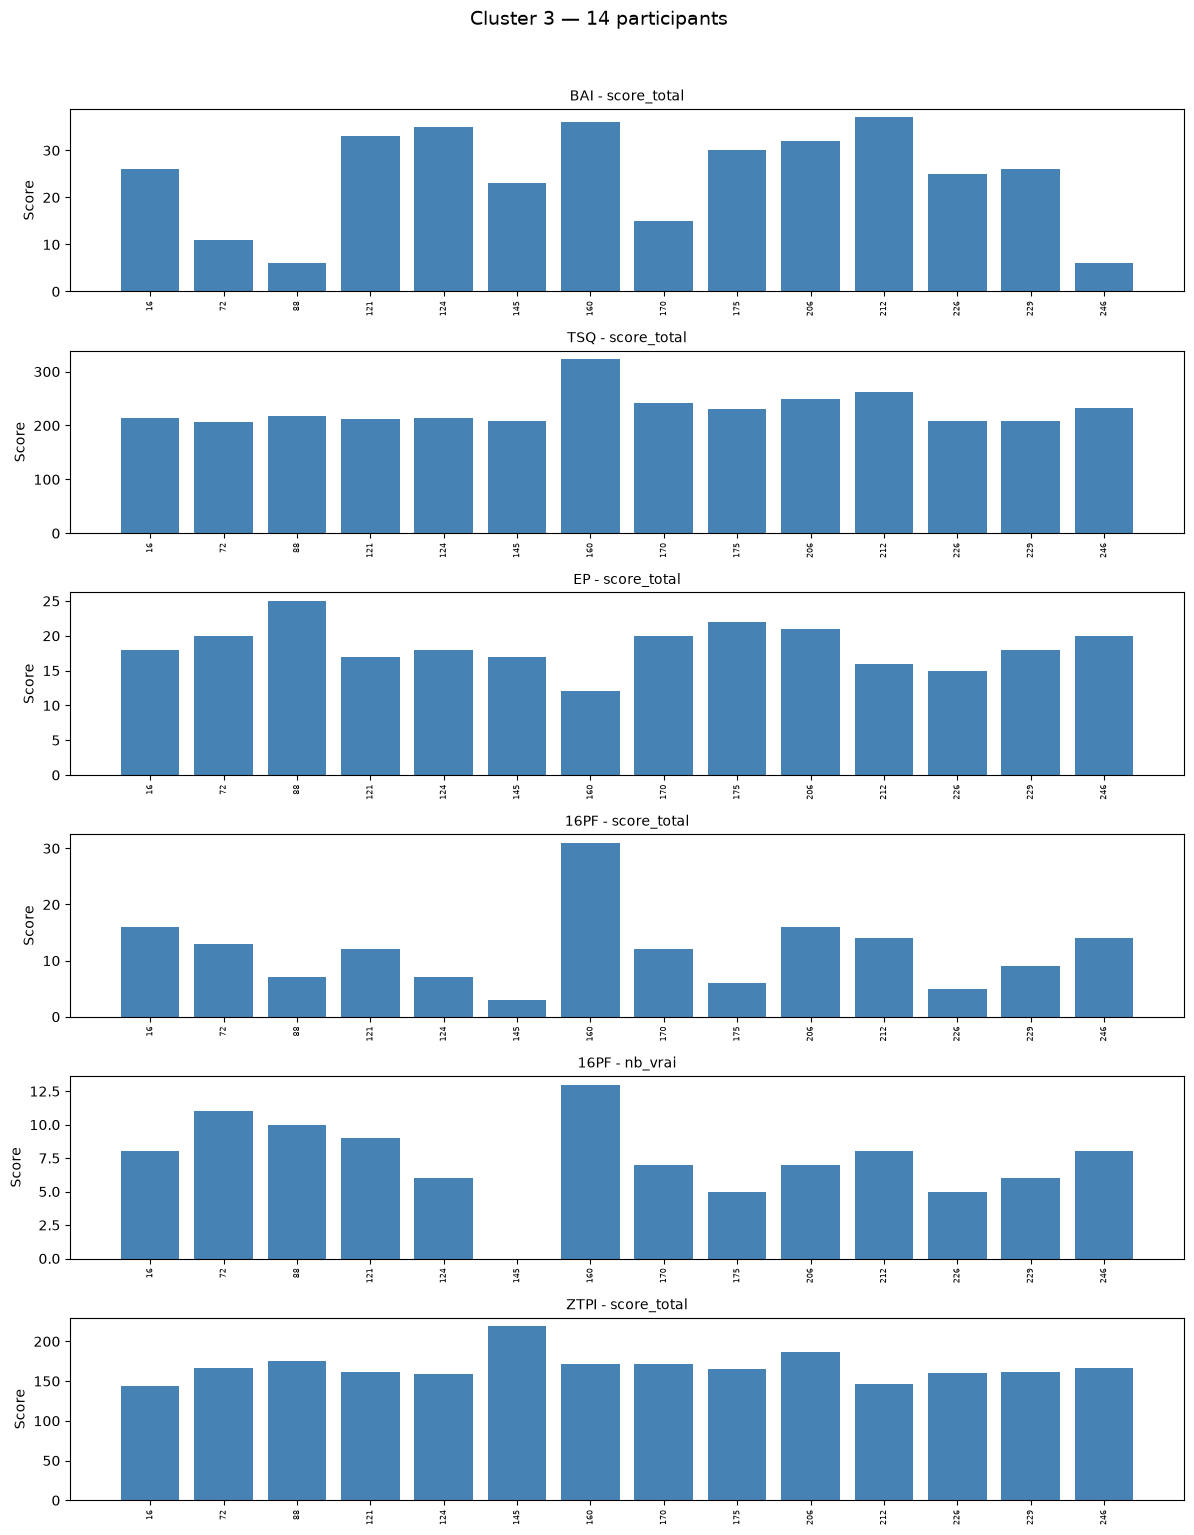

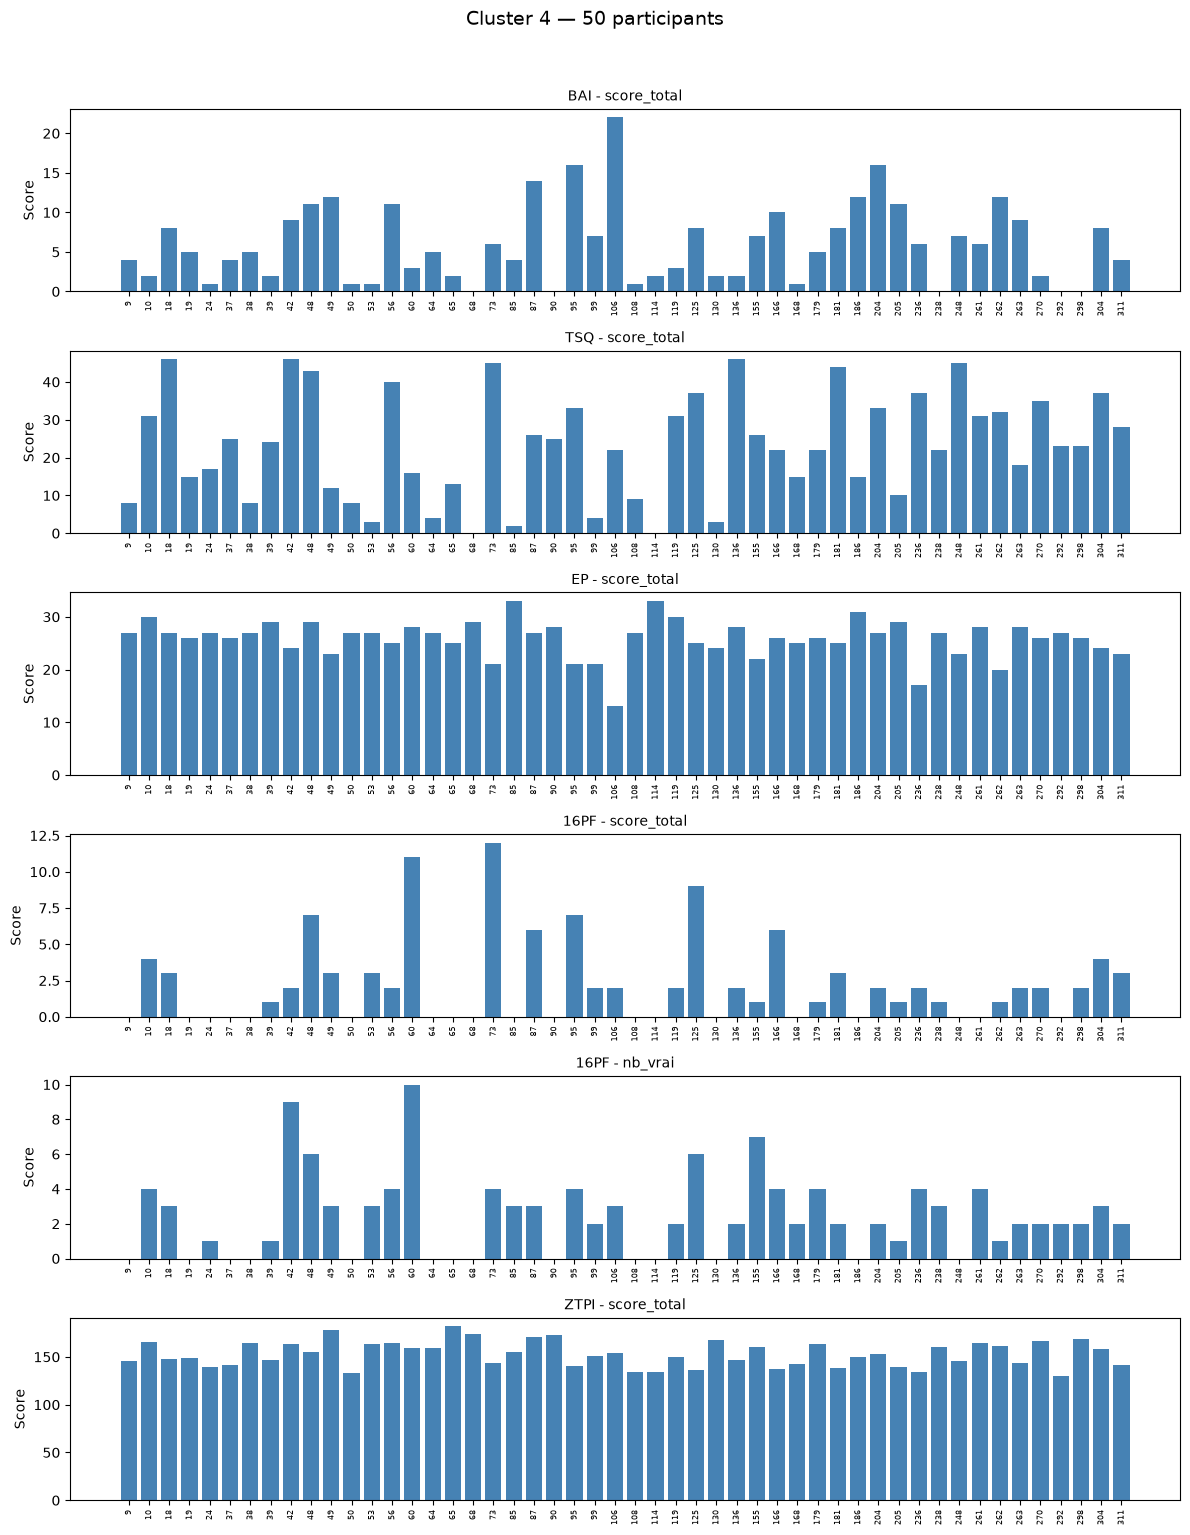

In [220]:
import matplotlib.pyplot as plt

# dictionnaire des variables à visualiser
variables = {
    "BAI - score_total": df_BAI["score_total"],
    "TSQ - score_total": df_TSQ["score_total"],
    "EP - score_total": df_EP["score_total"],
    "16PF - score_total": df_16["score_total"],
    "16PF - nb_vrai": df_16["nb_vrai"],
    "ZTPI - score_total": df_ZTPI["score_total"],
}

clusters_list = [df_cluster0, df_cluster1, df_cluster2, df_cluster3, df_cluster4]

for c, d in enumerate(clusters_list):
    participants = d.index
    n_vars = len(variables)

    fig, axes = plt.subplots(n_vars, 1, figsize=(12, 2.5 * n_vars), sharex=False)
    fig.suptitle(f"Cluster {c} — {len(participants)} participants", fontsize=14, y=1.02)

    for ax, (name, series) in zip(axes, variables.items()):
        # reindex plutôt que .loc pour éviter un crash si un participant manque
        values = series.reindex(participants)
        ax.bar(values.index.astype(str), values.values, color='steelblue')
        ax.set_title(name, fontsize=10)
        ax.set_ylabel("Score")
        ax.tick_params(axis='x', rotation=90, labelsize=6)

    plt.tight_layout()
    plt.show()

In [221]:
variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}

clusters_list = [df_cluster0, df_cluster1, df_cluster2, df_cluster3, df_cluster4]

resultats_par_cluster = {}

for c, d in enumerate(clusters_list):
    participants = d.index
    tableau = pd.DataFrame({name: series.reindex(participants) for name, series in variables.items()})
    tableau.index.name = "participant"
    resultats_par_cluster[c] = tableau
    print(f"\n--- Cluster {c} ({len(participants)} participants) ---")
    print(tableau)


--- Cluster 0 (42 participants) ---
             BAI_score_total  TSQ_score_total  EP_score_total  \
participant                                                     
12                      12.0             68.0            32.0   
17                      15.0             94.0            29.0   
32                       9.0             51.0            20.0   
40                       9.0             85.0            22.0   
43                       5.0             63.0            23.0   
54                       1.0             66.0            29.0   
55                      17.0             67.0            24.0   
59                       2.0             80.0            24.0   
61                       6.0             51.0            20.0   
66                       5.0             69.0            20.0   
83                       6.0             65.0            16.0   
91                       2.0             74.0            20.0   
104                     16.0             82.0        

In [222]:
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0  Cluster 1   Cluster 2   Cluster 3  Cluster 4
BAI_score_total     7.023810      13.10   13.250000   24.357143       5.94
TSQ_score_total    74.714286     174.25  128.428571  230.714286      23.20
EP_score_total     24.238095      21.05   22.214286   18.500000      25.88
16PF_score_total    5.333333      10.95    7.464286   11.785714       2.18
16PF_nb_vrai        3.976190       7.20    5.142857    7.357143       2.40
ZTPI_score_total  157.785714     164.80  159.892857  168.071429     152.92


Comme UMAP on a un clustering en fonction des scores de tt les échelles : cad --> le cluster 3 (vert) a des participants qui ont des scores de tt les échelles + élevés (sauf pour EP : la plus petite ce qui est coherent). Ensuite les clusters gardent cette categorisation et dans l'ordre on a le cluster 1 (violet), 2 (rouge),  0(jaune), 4 (bleu) qui sont du + "patho" au + "sain". 

ce serait comme des clusters de participants "à risque"

In [223]:
import pandas as pd
from TSQ_scoring import calculer_scores_tsq

for i, d in enumerate(clusters_list, start=1):
    print(f"Cluster {i}: {len(d)} participants")


df_TSQ_scores = calculer_scores_tsq(df_TSQ)

items_tsq = [f"TSQ{i}" for i in range(1, 41)]
score_cols = [c for c in df_TSQ_scores.columns if c not in items_tsq]
print("Colonnes de scores disponibles :", score_cols)

# vérification d'alignement d'index
assert df_TSQ.index.equals(df_clust.index), "Index df_TSQ / df_clust non alignés !"

# ============================================================
# 3. Scores TSQ par participant + describe() par cluster
# ============================================================
resultats_scores_par_cluster = {}

for i, d in enumerate(clusters_list, start=1):
    sous_scores = df_TSQ_scores.reindex(d.index)[score_cols]
    resultats_scores_par_cluster[i] = sous_scores

    print(f"\n{'='*60}")
    print(f"Cluster {i} — {len(d)} participants")
    print(f"{'='*60}")
    print("\n--- Scores TSQ par participant ---")
    print(sous_scores)
    print("\n--- Describe (moyenne, écart-type, min, max...) ---")
    print(sous_scores.describe())

# ============================================================
# 4. Tableau récapitulatif : moyenne par cluster, toutes dimensions
# ============================================================
resume_moyennes = pd.DataFrame({
    f"Cluster {i}": sous.mean()
    for i, sous in resultats_scores_par_cluster.items()
})
print("\n--- Résumé des moyennes par cluster ---")
print(resume_moyennes)

Cluster 1: 42 participants
Cluster 2: 20 participants
Cluster 3: 28 participants
Cluster 4: 14 participants
Cluster 5: 50 participants
Colonnes de scores disponibles : ['score_total', 'grand_score', 'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt', 'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt', 'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt']

Cluster 1 — 42 participants

--- Scores TSQ par participant ---
             score_total  grand_score  core_sz   core_md  core_ma   core_an  \
participant                                                                   
12                  68.0       0.1700  0.05000  0.228571    0.350  0.207143   
17                  94.0       0.2350  0.14375  0.385714    0.325  0.321429   
32                  51.0       0.1275  0.08750  0.157143    0.050  0.114286   
40                  85.0       0.2125  0.20000  0.100000    0.350  0.278571   
43                  63.0       0.1575  0.13125  0.142857    0.000  0.278571   
54                  66.0    

les clusters suivent aussi les TSQ_scoring de Nortoff

# UMAP

In [224]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df.index]
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants sains (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants sains (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [225]:
df_clust = df_clust.copy()
df_clust['cluster'] = clusters

# vérifier la répartition
print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
df_cluster3 = df_clust[df_clust['cluster'] == 2]
df_cluster4 = df_clust[df_clust['cluster'] == 3]
df_cluster5 = df_clust[df_clust['cluster'] == 4]

for i, d in enumerate([df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0    53
1    24
2    43
3    28
4     6
Name: count, dtype: int64
Cluster 0: 53 participants
Cluster 1: 24 participants
Cluster 2: 43 participants
Cluster 3: 28 participants
Cluster 4: 6 participants


In [226]:
# 1. clustering + UMAP (ton bloc 1)
# 2. extraction des df_cluster0..4 (ton bloc 2)

clusters_list = [df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]

variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}

# 3. ton bloc resume
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4
BAI_score_total     6.000000   16.125000    7.348837   13.892857   26.000000
TSQ_score_total    24.754717  189.416667   79.139535  136.000000  256.666667
EP_score_total     25.566038   19.833333   24.348837   22.321429   18.500000
16PF_score_total    2.264151   10.458333    5.767442    7.642857   15.500000
16PF_nb_vrai        2.377358    7.166667    4.209302    5.392857    8.000000
ZTPI_score_total  152.528302  164.625000  157.930233  163.142857  167.500000


On a un clustering en fonction des scores de tt les échelles : cad --> le cluster 4 (bleu) a des participants qui ont des scores de tt les échelles + élevés (sauf pour EP : la plus petite ce qui est coherent). Ensuite les clusters gardent cette categorisation et dans l'ordre on a le cluster 1 (violet), 3 (vert), 2 (rouge), 0 (jaune) qui sont du + "patho" au + "sain". 

ce serait comme des clusters de participants "à risque"

Clusters en fonction du TSQ_scoring de Nortoff

In [227]:
import pandas as pd
from TSQ_scoring import calculer_scores_tsq

for i, d in enumerate(clusters_list, start=1):
    print(f"Cluster {i}: {len(d)} participants")


df_TSQ_scores = calculer_scores_tsq(df_TSQ)

items_tsq = [f"TSQ{i}" for i in range(1, 41)]
score_cols = [c for c in df_TSQ_scores.columns if c not in items_tsq]
print("Colonnes de scores disponibles :", score_cols)

# vérification d'alignement d'index
assert df_TSQ.index.equals(df_clust.index), "Index df_TSQ / df_clust non alignés !"

# ============================================================
# 3. Scores TSQ par participant + describe() par cluster
# ============================================================
resultats_scores_par_cluster = {}

for i, d in enumerate(clusters_list, start=1):
    sous_scores = df_TSQ_scores.reindex(d.index)[score_cols]
    resultats_scores_par_cluster[i] = sous_scores

    print(f"\n{'='*60}")
    print(f"Cluster {i} — {len(d)} participants")
    print(f"{'='*60}")
    print("\n--- Scores TSQ par participant ---")
    print(sous_scores)
    print("\n--- Describe (moyenne, écart-type, min, max...) ---")
    print(sous_scores.describe())

# ============================================================
# 4. Tableau récapitulatif : moyenne par cluster, toutes dimensions
# ============================================================
resume_moyennes = pd.DataFrame({
    f"Cluster {i}": sous.mean()
    for i, sous in resultats_scores_par_cluster.items()
})
print("\n--- Résumé des moyennes par cluster ---")
print(resume_moyennes)

Cluster 1: 53 participants
Cluster 2: 24 participants
Cluster 3: 43 participants
Cluster 4: 28 participants
Cluster 5: 6 participants
Colonnes de scores disponibles : ['score_total', 'grand_score', 'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt', 'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt', 'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt']

Cluster 1 — 53 participants

--- Scores TSQ par participant ---
     score_total  grand_score  core_sz   core_md  core_ma   core_an   core_pt  \
9            8.0       0.0200  0.00000  0.057143    0.000  0.014286  0.066667   
10          31.0       0.0775  0.05000  0.057143    0.225  0.100000  0.077778   
18          46.0       0.1150  0.06250  0.057143    0.350  0.171429  0.211111   
19          15.0       0.0375  0.00625  0.042857    0.000  0.050000  0.066667   
24          17.0       0.0425  0.01250  0.085714    0.000  0.085714  0.011111   
32          51.0       0.1275  0.08750  0.157143    0.050  0.114286  0.222222   
37          25.

les clusters suivent aussi les TSQ _scoring de nortoff

# t-SNE sur PD

In [228]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px

from sklearn.preprocessing import StandardScaler

# Standardiser les données car la var des items n'est pas forcement la meme. J'ai essayé sans ca me donne rien de bon
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df)
# X = X_scaled 

# change tout de normaliser et j'ai l'impression que c'est pas mieux donc à voir
X = df_PD.values # la j'ai pris le df avec les 40 items , j'ai essayé avec le df_red (sans 7 items qui etaient corrélés mais ca donne moins bien)

perplexity = np.arange(5, 35, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i, random_state=42)
    reduced = model.fit_transform(X)
    divergence.append(model.kl_divergence_)

fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show(renderer="browser")

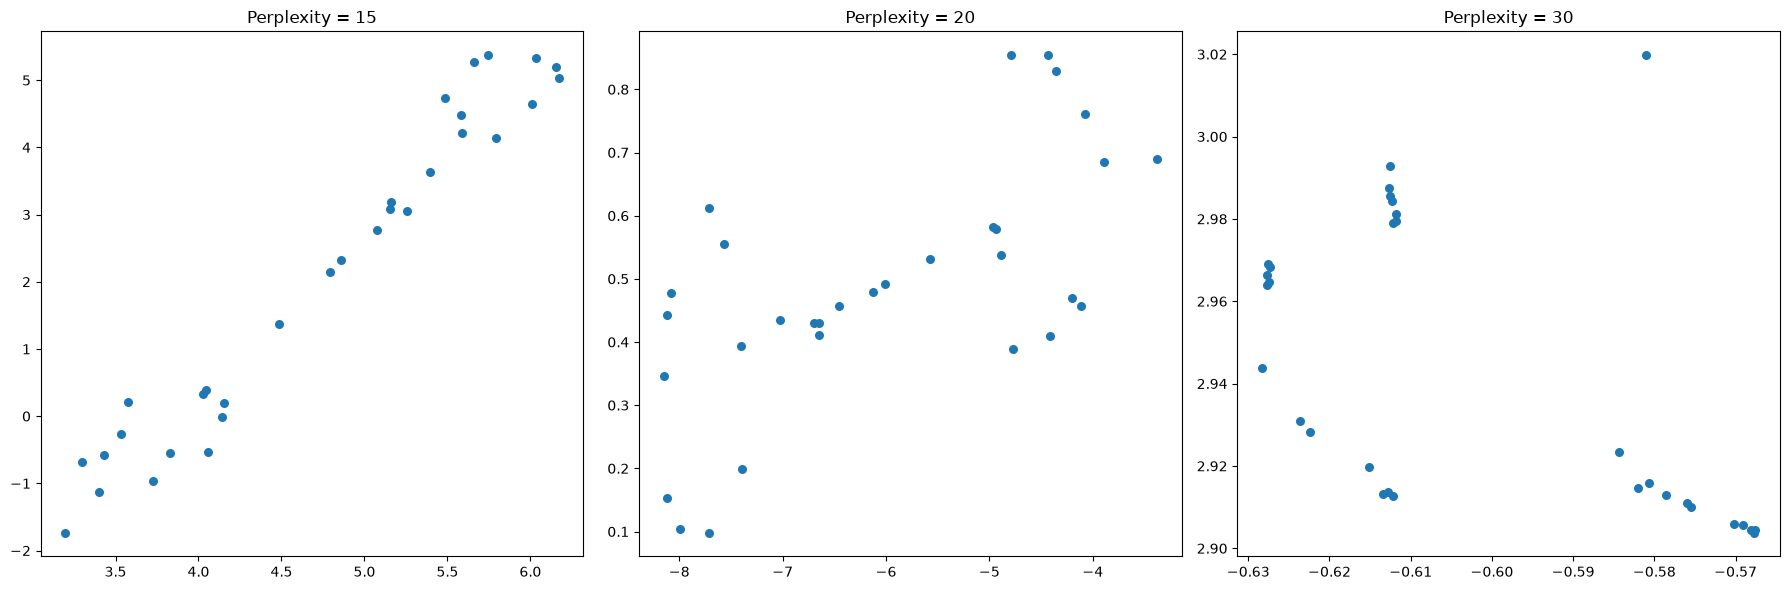

In [229]:

import matplotlib.pyplot as plt

perplexities_to_test = [15,20, 30]
fig, axes = plt.subplots(1, len(perplexities_to_test), figsize=(18, 6))
for ax, p in zip(axes, perplexities_to_test):
    model = TSNE(n_components=2, init="pca", perplexity=p, random_state=42) #hyperpara : init, generalement "random" mais ici c'est plus  en faisant pca
    reduced = model.fit_transform(X)
    ax.scatter(reduced[:, 0], reduced[:, 1], s=30)
    ax.set_title(f"Perplexity = {p}")

plt.tight_layout()
plt.show()




In [264]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="pca", perplexity=20, random_state=42)
X_tsne = tsne.fit_transform(X)

tsne.kl_divergence_

0.07039479166269302

In [265]:
participant_ids = df_PD.index  # [0, 1, 2, ..., 153]
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1])

fig.update_layout(
    title="t-SNE visualization - Participants avec diag",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")

In [232]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # essaie différents n_clusters
clusters = kmeans.fit_predict(X)
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig = px.scatter(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1],
    hover_name=participant_ids,
    color=clusters.astype(str),  # colore par cluster trouvé
    color_discrete_sequence=custom_colors
)
fig.update_layout(
    title="t-SNE coloré par clusters KMeans",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")
# donne un graph interactif en cliquant sur les points : on sait qui est le aprticipant

In [233]:
# on ajoute directement le label de cluster à df_clust
df_clust_PD = df_PD.copy()
df_clust_PD['cluster'] = clusters

# vérifier la répartition
print(df_clust_PD['cluster'].value_counts().sort_index())
df_PD0 = df_clust_PD[df_clust_PD['cluster'] == 0]
df_PD1 = df_clust_PD[df_clust_PD['cluster'] == 1]
df_PD2 = df_clust_PD[df_clust_PD['cluster'] == 2]
df_PD3 = df_clust_PD[df_clust_PD['cluster'] == 3]
df_PD4 = df_clust_PD[df_clust_PD['cluster'] == 4]

for i, d in enumerate([df_PD0, df_PD1, df_PD2, df_PD3, df_PD4]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0     6
1    10
2     7
3     1
4     7
Name: count, dtype: int64
Cluster 0: 6 participants
Cluster 1: 10 participants
Cluster 2: 7 participants
Cluster 3: 1 participants
Cluster 4: 7 participants


In [234]:

variables = {
    "BAI_score_total": df_BAI_PD["score_total"],
    "TSQ_score_total": df_TSQ_PD["score_total"],
    "EP_score_total": df_EP_PD['score_total'],
    "16PF_score_total": df_16_PD["score_total"],
    "16PF_nb_vrai": df_16_PD["nb_vrai"],
    "ZTPI_score_total": df_ZTPI_PD["score_total"],
}

clusters_list = [df_PD0, df_PD1, df_PD2, df_PD3, df_PD4]

resultats_par_cluster = {}

for c, d in enumerate(clusters_list):
    participants = d.index
    tableau = pd.DataFrame({name: series.reindex(participants) for name, series in variables.items()})
    tableau.index.name = "participant"
    resultats_par_cluster[c] = tableau
    print(f"\n--- Cluster {c} ({len(participants)} participants) ---")
    print(tableau)
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)


--- Cluster 0 (6 participants) ---
             BAI_score_total  TSQ_score_total  EP_score_total  \
participant                                                     
13                      46.0            192.0            25.0   
140                     14.0            188.0            17.0   
149                     13.0            189.0            17.0   
182                     12.0            196.0            19.0   
209                     22.0            195.0            22.0   
272                     21.0            162.0            20.0   

             16PF_score_total  16PF_nb_vrai  ZTPI_score_total  
participant                                                    
13                       14.0             7             189.0  
140                       4.0             3             155.0  
149                      13.0            10             156.0  
182                      17.0             9             188.0  
209                      13.0             6             168

In [235]:
import pandas as pd
from TSQ_scoring import calculer_scores_tsq

for i, d in enumerate(clusters_list, start=1):
    print(f"Cluster {i}: {len(d)} participants")


df_TSQ_scores_PD = calculer_scores_tsq(df_TSQ_PD)

items_tsq = [f"TSQ{i}" for i in range(1, 41)]
score_cols = [c for c in df_TSQ_scores_PD.columns if c not in items_tsq]
print("Colonnes de scores disponibles :", score_cols)

# vérification d'alignement d'index
assert df_TSQ_scores_PD.index.equals(df_clust_PD.index), "Index df_TSQ_scores_PD / df_clust non alignés !"

# ============================================================
# 3. Scores TSQ par participant + describe() par cluster
# ============================================================
resultats_scores_par_cluster = {}

for i, d in enumerate(clusters_list, start=1):
    sous_scores = df_TSQ_scores_PD.reindex(d.index)[score_cols]
    resultats_scores_par_cluster[i] = sous_scores

    print(f"\n{'='*60}")
    print(f"Cluster {i} — {len(d)} participants")
    print(f"{'='*60}")
    print("\n--- Scores TSQ par participant diag ---")
    print(sous_scores)
    print("\n--- Describe (moyenne, écart-type, min, max...) ---")
    print(sous_scores.describe())

# ============================================================
# 4. Tableau récapitulatif : moyenne par cluster, toutes dimensions
# ============================================================
resume_moyennes = pd.DataFrame({
    f"Cluster {i}": sous.mean()
    for i, sous in resultats_scores_par_cluster.items()
})
print("\n--- Résumé des moyennes par cluster ---")
print(resume_moyennes)

Cluster 1: 6 participants
Cluster 2: 10 participants
Cluster 3: 7 participants
Cluster 4: 1 participants
Cluster 5: 7 participants
Colonnes de scores disponibles : ['score_total', 'grand_score', 'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt', 'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt', 'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt']

Cluster 1 — 6 participants

--- Scores TSQ par participant diag ---
             score_total  grand_score  core_sz   core_md  core_ma   core_an  \
participant                                                                   
13                 192.0       0.4800  0.16875  0.657143    0.950  0.657143   
140                188.0       0.4700  0.45000  0.500000    0.575  0.500000   
149                189.0       0.4725  0.44375  0.514286    0.625  0.457143   
182                196.0       0.4900  0.41250  0.642857    0.575  0.571429   
209                195.0       0.4875  0.31875  0.671429    0.350  0.557143   
272                162.0    

cluster 1-5 ou 0-4 selon ou on regarde en gros cluster jaune et bleu se confondent sur la cotation core PTSD et core Manie sinon dans l'ordre c'est du plus symptomatique au moins : 4>5>1>3>2 soit vert>bleu>jaune>rouge>violet 


# UMAP sur PD

In [236]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_PD.values
# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df_PD.index]
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants avec diagnostic (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants avec diagnostic (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [237]:

df_clust_PD = df_clust_PD.copy()
df_clust_PD['cluster'] = clusters

# vérifier la répartition
print(df_clust_PD['cluster'].value_counts().sort_index())

df_cluster1 = df_clust_PD[df_clust_PD['cluster'] == 0]
df_cluster2 = df_clust_PD[df_clust_PD['cluster'] == 1]
df_cluster3 = df_clust_PD[df_clust_PD['cluster'] == 2]
df_cluster4 = df_clust_PD[df_clust_PD['cluster'] == 3]
df_cluster5 = df_clust_PD[df_clust_PD['cluster'] == 4]

for i, d in enumerate([df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]):
    print(f"Cluster {i}: {len(d)} participants")
clusters_list = [df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]

variables = {
    "BAI_score_total": df_BAI_PD["score_total"],
    "TSQ_score_total": df_TSQ_PD["score_total"],
    "EP_score_total": df_EP_PD["score_total"],
    "16PF_score_total": df_16_PD["score_total"],
    "16PF_nb_vrai": df_16_PD["nb_vrai"],
    "ZTPI_score_total": df_ZTPI_PD["score_total"],
}

# 3. ton bloc resume
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

cluster
0     6
1    10
2     7
3     1
4     7
Name: count, dtype: int64
Cluster 0: 6 participants
Cluster 1: 10 participants
Cluster 2: 7 participants
Cluster 3: 1 participants
Cluster 4: 7 participants
                   Cluster 0  Cluster 1   Cluster 2  Cluster 3   Cluster 4
BAI_score_total    21.333333        6.5   13.000000       28.0   25.142857
TSQ_score_total   187.000000       61.7  124.714286      322.0  226.428571
EP_score_total     20.000000       24.5   22.857143       28.0   21.714286
16PF_score_total   12.000000        3.8   12.428571       20.0   14.857143
16PF_nb_vrai        6.833333        3.4    5.571429        8.0    7.571429
ZTPI_score_total  167.166667      159.8  173.714286      164.0  165.285714


suit pas toujours le meme ordre meme si le cluster 3 = vert semble + symptomatique, suivit par le 4 = bleu, rouge =2, jaube =0 semble erte assez spécifique de l'échelle de positivité avec des scores les plus bas. le cluster 1 = violet semble etre le - symptomatique. 

En tout cas, les 2 techniques nous ressortent un cluster bleu avec un seul profil c'est le meme participant qui se déclare : TSA, TDAH, TDI, bipolarité type 1. DOnc le cluster bleu represente plutot la manie?

# on reteste sur la TSQ reduite

In [238]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red = df.drop(columns=colonnes_a_exclure)
len(df_red.columns)  # Vérifie le nombre de colonnes restantes
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40'],
      dtype='str')


In [239]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_red.values

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df_red.index]
custom_colors = ['#F6F926', '#A777F1'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants sains (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants sains (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
df_clust = df_red.copy()
df_clust['cluster'] = clusters

# vérifier la répartition
print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
for i, d in enumerate([df_cluster1, df_cluster2]):
    print(f"Cluster {i}: {len(d)} participants")



cluster
0    98
1    56
Name: count, dtype: int64
Cluster 0: 98 participants
Cluster 1: 56 participants


In [241]:

clusters_list = [df_cluster1, df_cluster2]

variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}

# 3. ton bloc resume
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0   Cluster 1
BAI_score_total     6.591837   16.428571
TSQ_score_total    50.561224  172.392857
EP_score_total     25.142857   20.535714
16PF_score_total    3.775510    9.928571
16PF_nb_vrai        3.204082    6.500000
ZTPI_score_total  155.071429  164.321429


In [242]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_red_PD.values

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df_red_PD.index]
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants avec diagnostic (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants avec diagnostic (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [243]:
df_clust = df_red_PD.copy()
df_clust['cluster'] = clusters

# vérifier la répartition
print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
df_cluster3 = df_clust[df_clust['cluster'] == 2]
df_cluster4 = df_clust[df_clust['cluster'] == 3]    
df_cluster5 = df_clust[df_clust['cluster'] == 4]
for i, d in enumerate([df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0    5
1    7
2    9
3    6
4    4
Name: count, dtype: int64
Cluster 0: 5 participants
Cluster 1: 7 participants
Cluster 2: 9 participants
Cluster 3: 6 participants
Cluster 4: 4 participants


In [244]:

clusters_list = [df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]

variables = {
    "BAI_score_total": df_BAI_PD["score_total"],
    "TSQ_score_total": df_TSQ_PD["score_total"],
    "EP_score_total": df_EP_PD["score_total"],
    "16PF_score_total": df_16_PD["score_total"],
    "16PF_nb_vrai": df_16_PD["nb_vrai"],
    "ZTPI_score_total": df_ZTPI_PD["score_total"],
}

# 3. ton bloc resume
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                  Cluster 0   Cluster 1   Cluster 2   Cluster 3  Cluster 4
BAI_score_total        20.2   18.714286    6.111111   25.333333      12.25
TSQ_score_total       217.4  125.285714   65.444444  232.000000     143.50
EP_score_total         22.4   24.000000   23.111111   20.666667      23.25
16PF_score_total       14.2   11.000000    6.111111   13.833333       8.75
16PF_nb_vrai            7.6    6.000000    3.222222    7.000000       6.00
ZTPI_score_total      170.6  167.857143  162.888889  157.833333     174.25


bai : 3>0>1>4>2
TSQ : 3>0>4>1>2
EP : 3>0>2>4>1
16tot: 0>3>1>4>2
nb vrai: 0>3>1>4>2
ztpi: 4>0>1>2>3

cluster 0 serait plus spécifique de la fpq16 (violet)
cluster 3 de l'anxiete, depression (bai, tsq, ep) bleu
cluster 4 serait + spe de deficit spatio temporel  (rouge)